In [ ]:
from google.colab import files

uploaded = files.upload()

Saving VIM2_Part12D_Hydrogen_Bonding.csv to VIM2_Part12D_Hydrogen_Bonding.csv


In [ ]:
import pandas as pd

features_df = pd.read_csv(
    "vim2_ml_features_part10b_validated.csv"
)

print(features_df.shape)

features_df.head()

(5016, 50)


,index,WT_AA,position,Mutant_AA,identity,group,128ug/mL_AMP_25C,128ug/mL_AMP_25C_SD,16ug/mL_AMP_25C,16ug/mL_AMP_25C_SD,...,Fitness_AMP,Fitness_CTX,Fitness_MEM,Fitness_Std,Global_Beneficial,Globally_Positive,Positive_Condition_Count,Environment_Dependent,Broadly_Beneficial,Broadly_Positive
0,(p.Met.1.Ala),M,1,A,var,1,-6.789449,0.416583,-3.437078,0.140442,...,-3.390200,-2.902461,-3.636189,2.480558,0,0,2,1,0,0
1,(p.Met.1.Cys),M,1,C,var,1,-5.468160,1.466798,-2.707023,0.224966,...,-3.152001,-2.608460,-3.462681,2.448868,0,0,1,1,0,0
2,(p.Met.1.Asp),M,1,D,var,1,-6.887204,2.923978,-3.092696,0.836858,...,-3.596820,-2.786395,-3.653086,2.802911,0,0,2,1,0,0
3,(p.Met.1.Glu),M,1,E,var,1,-5.695020,0.973549,-0.305250,0.036860,...,-1.878725,-1.882679,-3.093605,2.240573,0,0,1,1,0,0
4,(p.Met.1.Phe),M,1,F,var,1,-4.105826,2.339236,-3.574404,0.777098,...,-3.050841,-1.841894,-2.918111,2.010752,0,0,0,0,0,0


FIGURE 1 — ORIGINAL DATASET LOADED
Dataset shape: (5549, 24)

Columns:
['index', 'wt residue', 'position', 'variant residue', 'identity', 'group', '128ug/mL_AMP_25C', '128ug/mL_AMP_25C_SD', '16ug/mL_AMP_25C', '16ug/mL_AMP_25C_SD', '2ug/mL_AMP_25C', '2ug/mL_AMP_25C_SD', '128ug/mL_AMP_37C', '128ug/mL_AMP_37C_SD', '16ug/mL_AMP_37C', '16ug/mL_AMP_37C_SD', '2ug/mL_AMP_37C', '2ug/mL_AMP_37C_SD', '4ug/mL_CTX_37C', '4ug/mL_CTX_37C_SD', '0.5ug/mL_CTX_37C', '0.5ug/mL_CTX_37C_SD', '0.031ug/mL_MEM_37C', '0.031ug/mL_MEM_37C_SD']

DATASET COMPOSITION
Missense      5035
Stop codon     267
Synonymous     247
dtype: int64

MISSENSE COVERAGE
Unique positions: 266
Minimum substitutions: 13
Maximum substitutions: 19
Mean substitutions: 18.86

POSITIVE CONDITION COUNT DISTRIBUTION
0    830
1    657
2    635
3    529
4    568
5    584
6    340
7    289
8    321
9    282
Name: count, dtype: int64

FITNESS CORRELATION MATRIX CALCULATED


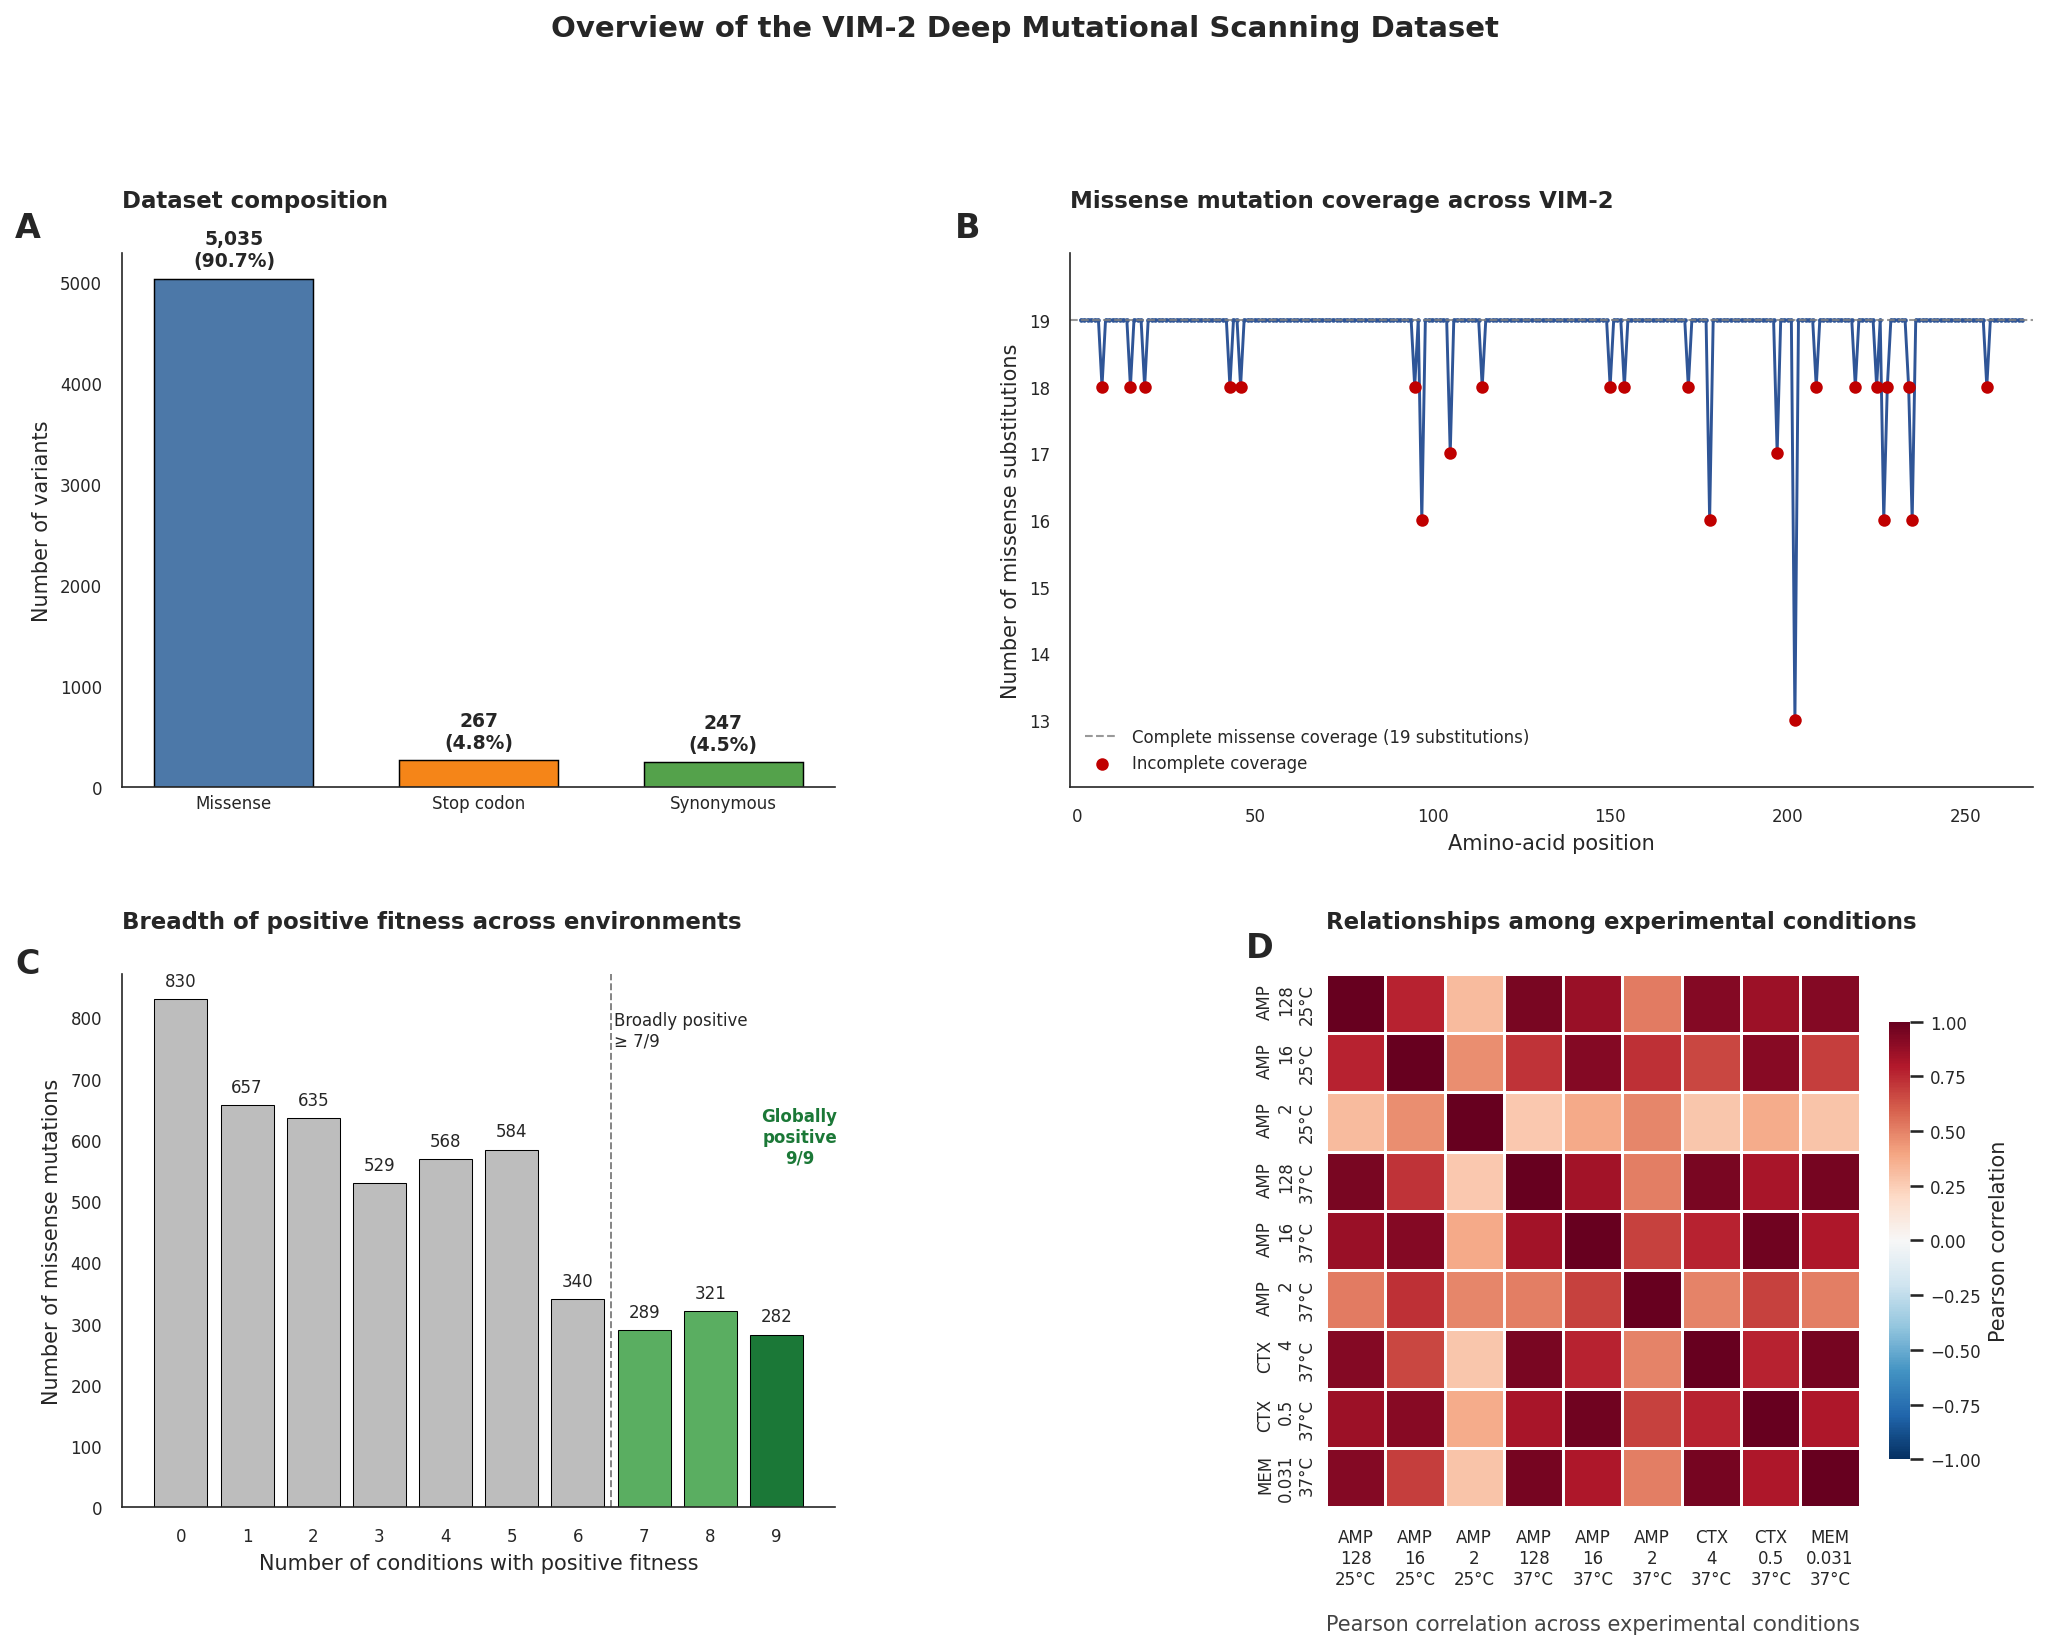


FIGURE 1 COMPLETED SUCCESSFULLY
SVG: Figure1_VIM2_Dataset_Overview.svg
PDF: Figure1_VIM2_Dataset_Overview.pdf
PNG: Figure1_VIM2_Dataset_Overview.png

Figure panels:
A — Dataset composition
B — Missense mutation coverage
C — Breadth of positive fitness
D — Fitness condition correlation


In [ ]:
# @title
# ============================================================
# FIGURE 1 — OVERVIEW OF THE VIM-2 DEEP MUTATIONAL SCANNING DATASET
# Publication-quality 4-panel figure
#
# Panel A: Dataset composition
# Panel B: Missense mutation coverage across positions
# Panel C: Distribution of positive fitness conditions
# Panel D: Correlation among the 9 fitness conditions
#
# Outputs:
#   Figure1_VIM2_Dataset_Overview.svg
#   Figure1_VIM2_Dataset_Overview.pdf
#   Figure1_VIM2_Dataset_Overview.png
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. LOAD THE ORIGINAL DATASET
# ============================================================

# IMPORTANT:
# Replace this filename with the exact filename of your
# ORIGINAL VIM-2 dataset.

input_file = "elife-56707-supp2-v2.csv"

df = pd.read_csv(input_file)

print("=" * 60)
print("FIGURE 1 — ORIGINAL DATASET LOADED")
print("=" * 60)

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. DEFINE THE 9 FITNESS CONDITIONS
# ============================================================

fitness_columns = [
    "128ug/mL_AMP_25C",
    "16ug/mL_AMP_25C",
    "2ug/mL_AMP_25C",
    "128ug/mL_AMP_37C",
    "16ug/mL_AMP_37C",
    "2ug/mL_AMP_37C",
    "4ug/mL_CTX_37C",
    "0.5ug/mL_CTX_37C",
    "0.031ug/mL_MEM_37C"
]


# ============================================================
# 3. CLEAN / PREPARE POSITION
# ============================================================

df["Position_Numeric"] = pd.to_numeric(
    df["position"],
    errors="coerce"
)


# ============================================================
# 4. DEFINE DATASET COMPOSITION
# ============================================================

# IMPORTANT:
# These names assume the original dataset contains:
# identity = var or syn
# variant residue = amino-acid letter or "*"
#
# If your column names are slightly different,
# change them here.

variant_mask = (
    df["identity"].astype(str).str.lower() == "var"
)

synonymous_mask = (
    df["identity"].astype(str).str.lower() == "syn"
)

stop_mask = (
    variant_mask
    &
    (df["variant residue"].astype(str) == "*")
)

missense_mask = (
    variant_mask
    &
    (~stop_mask)
)


n_missense = missense_mask.sum()
n_stop = stop_mask.sum()
n_synonymous = synonymous_mask.sum()

composition_counts = pd.Series(
    {
        "Missense": n_missense,
        "Stop codon": n_stop,
        "Synonymous": n_synonymous
    }
)

print("\n" + "=" * 60)
print("DATASET COMPOSITION")
print("=" * 60)

print(composition_counts)


# ============================================================
# 5. MISSENSE COVERAGE BY POSITION
# ============================================================

missense_positions = (
    df.loc[
        missense_mask
        &
        df["Position_Numeric"].notna(),
        "Position_Numeric"
    ]
    .astype(int)
)

coverage = (
    missense_positions
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 60)
print("MISSENSE COVERAGE")
print("=" * 60)

print(f"Unique positions: {coverage.index.nunique()}")
print(f"Minimum substitutions: {coverage.min()}")
print(f"Maximum substitutions: {coverage.max()}")
print(f"Mean substitutions: {coverage.mean():.2f}")


# ============================================================
# 6. PREPARE FITNESS DATA
# ============================================================

fitness_df = df.loc[
    missense_mask,
    fitness_columns
].copy()

# Convert all fitness columns to numeric.
fitness_df = fitness_df.apply(
    pd.to_numeric,
    errors="coerce"
)


# ============================================================
# 7. CALCULATE POSITIVE CONDITION COUNT
# ============================================================

# Positive means fitness > 0.

positive_condition_count = (
    fitness_df > 0
).sum(axis=1)

positive_distribution = (
    positive_condition_count
    .value_counts()
    .reindex(range(10), fill_value=0)
    .sort_index()
)

print("\n" + "=" * 60)
print("POSITIVE CONDITION COUNT DISTRIBUTION")
print("=" * 60)

print(positive_distribution)


# ============================================================
# 8. FITNESS CORRELATION MATRIX
# ============================================================

correlation_matrix = (
    fitness_df
    .corr(method="pearson")
)

print("\n" + "=" * 60)
print("FITNESS CORRELATION MATRIX CALCULATED")
print("=" * 60)


# ============================================================
# 9. PUBLICATION-QUALITY STYLE
# ============================================================

sns.set_theme(
    style="white"
)

plt.rcParams.update({

    "font.family": "DejaVu Sans",

    "font.size": 10,

    "axes.labelsize": 10,

    "axes.titlesize": 11,

    "xtick.labelsize": 8,

    "ytick.labelsize": 8,

    "legend.fontsize": 8,

    "figure.titlesize": 14,

    "axes.linewidth": 0.8,

    "pdf.fonttype": 42,

    "ps.fonttype": 42,

    "svg.fonttype": "none"

})


# ============================================================
# 10. CREATE 4-PANEL FIGURE
# ============================================================

fig = plt.figure(
    figsize=(14, 11),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[1, 1.35],
    height_ratios=[1, 1],
    wspace=0.28,
    hspace=0.35
)


# ------------------------------------------------------------
# PANEL A — DATASET COMPOSITION
# ------------------------------------------------------------

axA = fig.add_subplot(
    gs[0, 0]
)

composition_colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B"
]

bars = axA.bar(
    composition_counts.index,
    composition_counts.values,
    color=composition_colors,
    edgecolor="black",
    linewidth=0.7,
    width=0.65
)

total_composition = composition_counts.sum()

for bar, count in zip(
    bars,
    composition_counts.values
):

    percentage = (
        count
        / total_composition
        * 100
    )

    axA.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height()
        + total_composition * 0.015,

        f"{count:,}\n({percentage:.1f}%)",

        ha="center",
        va="bottom",

        fontsize=9,
        fontweight="bold"
    )


axA.set_ylabel(
    "Number of variants"
)

axA.set_xlabel(
    ""
)

axA.set_title(
    "Dataset composition",
    loc="left",
    fontweight="bold",
    pad=22
)

axA.spines[
    ["top", "right"]
].set_visible(False)

axA.tick_params(
    axis="x",
    length=0
)


# Panel label.
axA.text(
    -0.15,
    1.08,
    "A",
    transform=axA.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)


# ------------------------------------------------------------
# PANEL B — MISSENSE COVERAGE ACROSS POSITIONS
# ------------------------------------------------------------

axB = fig.add_subplot(
    gs[0, 1]
)

axB.plot(
    coverage.index,
    coverage.values,

    color="#2F5597",

    linewidth=1.4,

    marker="o",

    markersize=2.2,

    markeredgewidth=0
)

# Expected maximum coverage line.
axB.axhline(
    19,

    linestyle="--",

    linewidth=1.0,

    color="gray",

    alpha=0.8,

    label="Complete missense coverage (19 substitutions)"
)


# Highlight incomplete positions.
incomplete_coverage = coverage[
    coverage < 19
]

axB.scatter(
    incomplete_coverage.index,
    incomplete_coverage.values,

    color="#C00000",

    s=25,

    zorder=5,

    label="Incomplete coverage"
)


axB.set_xlabel(
    "Amino-acid position"
)

axB.set_ylabel(
    "Number of missense substitutions"
)

axB.set_title(
    "Missense mutation coverage across VIM-2",
    loc="left",
    fontweight="bold",
    pad=22
)

axB.set_xlim(
    coverage.index.min() - 3,
    coverage.index.max() + 3
)

axB.set_ylim(
    12,
    20
)

axB.set_yticks(
    np.arange(
        13,
        20,
        1
    )
)

axB.legend(
    frameon=False,
    loc="lower left"
)

axB.spines[
    ["top", "right"]
].set_visible(False)


# Panel label.
axB.text(
    -0.12,
    1.08,
    "B",
    transform=axB.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)


# ------------------------------------------------------------
# PANEL C — POSITIVE FITNESS ACROSS CONDITIONS
# ------------------------------------------------------------

axC = fig.add_subplot(
    gs[1, 0]
)

bar_colors = []

for n_positive in positive_distribution.index:

    if n_positive == 9:

        # Globally positive.
        bar_colors.append(
            "#1B7837"
        )

    elif n_positive >= 7:

        # Broadly positive.
        bar_colors.append(
            "#5AAE61"
        )

    else:

        # Remaining mutations.
        bar_colors.append(
            "#BDBDBD"
        )


bars = axC.bar(
    positive_distribution.index,
    positive_distribution.values,

    color=bar_colors,

    edgecolor="black",

    linewidth=0.5,

    width=0.8
)


for bar, count in zip(
    bars,
    positive_distribution.values
):

    axC.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 15,

        f"{count}",

        ha="center",

        va="bottom",

        fontsize=8
    )


axC.set_xlabel(
    "Number of conditions with positive fitness"
)

axC.set_ylabel(
    "Number of missense mutations"
)

axC.set_title(
    "Breadth of positive fitness across environments",
    loc="left",
    fontweight="bold",
    pad=22
)

axC.set_xticks(
    range(10)
)

axC.spines[
    ["top", "right"]
].set_visible(False)


# Add threshold annotations.
axC.axvline(
    6.5,

    linestyle="--",

    linewidth=0.9,

    color="gray"
)

axC.text(
    6.55,
    axC.get_ylim()[1] * 0.93,

    "Broadly positive\n≥ 7/9",

    fontsize=8,

    va="top"
)

axC.text(
    9.35,
    axC.get_ylim()[1] * 0.75,

    "Globally\npositive\n9/9",

    fontsize=8,

    ha="center",

    va="top",

    color="#1B7837",

    fontweight="bold"
)


# Panel label.
axC.text(
    -0.15,
    1.05,
    "C",
    transform=axC.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)


# ============================================================
# PANEL D — CONDITION RELATIONSHIPS
# ============================================================

axD = fig.add_subplot(gs[1, 1])

heatmap_labels = [
    "AMP\n128\n25°C",
    "AMP\n16\n25°C",
    "AMP\n2\n25°C",

    "AMP\n128\n37°C",
    "AMP\n16\n37°C",
    "AMP\n2\n37°C",

    "CTX\n4\n37°C",
    "CTX\n0.5\n37°C",

    "MEM\n0.031\n37°C"
]

sns.heatmap(
    correlation_matrix,
    ax=axD,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=heatmap_labels,
    yticklabels=heatmap_labels,
    cbar_kws={
        "label": "Pearson correlation",
        "shrink": 0.82,
        "pad": 0.03
    }
)

axD.set_title(
    "Relationships among experimental conditions",
    loc="left",
    fontweight="bold",
    pad=22
)

# Center multi-line condition labels beneath each heatmap column.
axD.set_xticks(
    np.arange(len(heatmap_labels)) + 0.5
)

axD.set_xticklabels(
    heatmap_labels,
    rotation=0,
    ha="center",
    va="top",
    fontsize=8
)

axD.tick_params(
    axis="x",
    pad=10,
    length=0
)

axD.tick_params(
    axis="y",
    pad=5,
    length=0
)

axD.set_xlabel("")
axD.set_ylabel("")

# Panel label.
axD.text(
    -0.15,
    1.08,
    "D",
    transform=axD.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)

# Keep the heatmap's annotation area clear and publication-ready.
axD.text(
    0.5,
    -0.20,
    "Pearson correlation across experimental conditions",
    transform=axD.transAxes,
    ha="center",
    va="top",
    fontsize=10,
    color="#444444"
)

# ============================================================
# 11. ADD FIGURE-LEVEL TITLE
# ============================================================
# Adjust spacing between panels and leave enough room
# for the main figure title.
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.09,
    top=0.86,
    wspace=0.28,
    hspace=0.42
)

fig.suptitle(
    "Overview of the VIM-2 Deep Mutational Scanning Dataset",
    fontweight="bold",
    y=0.995
)

# Increase vertical space between the main title
# and the four panels.
fig.subplots_adjust(top=0.85)


# ============================================================
# 12. SAVE HIGH-QUALITY OUTPUTS
# ============================================================

svg_file = (
    "Figure1_VIM2_Dataset_Overview.svg"
)

pdf_file = (
    "Figure1_VIM2_Dataset_Overview.pdf"
)

png_file = (
    "Figure1_VIM2_Dataset_Overview.png"
)


fig.savefig(
    svg_file,
    format="svg",
    bbox_inches="tight"
)

fig.savefig(
    pdf_file,
    format="pdf",
    bbox_inches="tight"
)

fig.savefig(
    png_file,
    format="png",
    dpi=600,
    bbox_inches="tight"
)


# ============================================================
# 13. DISPLAY
# ============================================================

plt.show()


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FIGURE 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"SVG: {svg_file}")
print(f"PDF: {pdf_file}")
print(f"PNG: {png_file}")

print("\nFigure panels:")
print("A — Dataset composition")
print("B — Missense mutation coverage")
print("C — Breadth of positive fitness")
print("D — Fitness condition correlation")

FIGURE 2 — DATASET VALIDATION
Number of mutations used: 5016
Hydrophobicity_Change: 5016 valid values
Charge_Change: 5016 valid values
Weight_Change: 5016 valid values
BLOSUM62: 5016 valid values


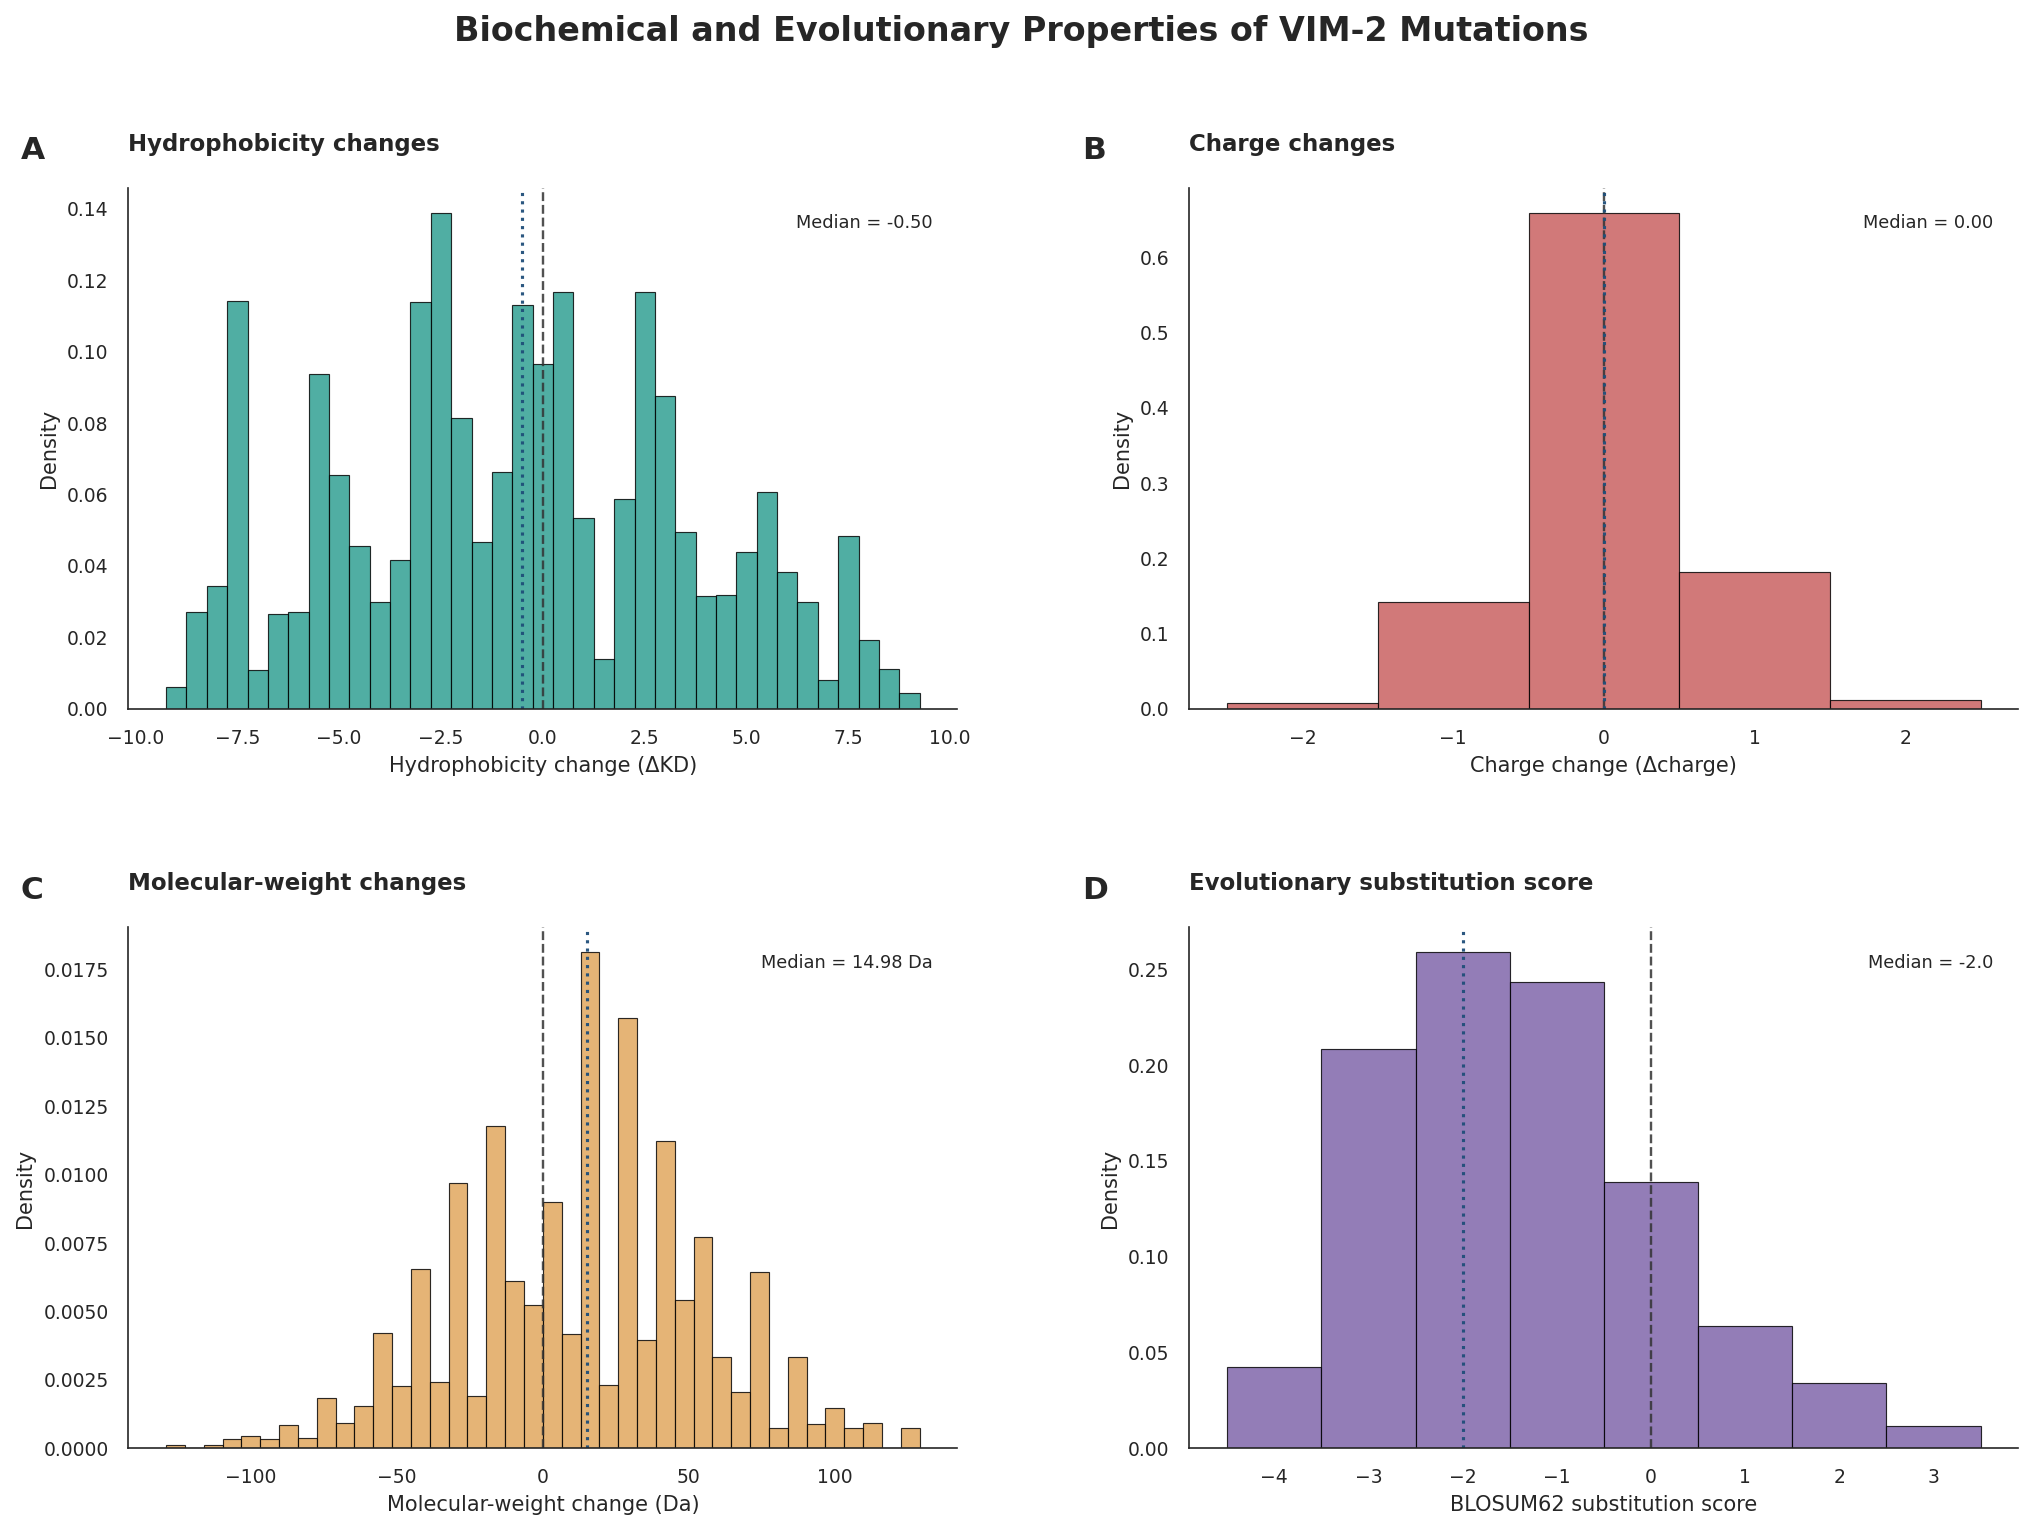


FIGURE 2 — COMPLETE
Mutations included: 5016
Hydrophobicity range: -9.00 to 9.00
Charge range: -2.00 to 2.00
Weight-change range: -129.16 to 129.16 Da
BLOSUM62 range: -4.0 to 3.0

Publication files saved:
  Figure_2_VIM2_Biochemical_Evolutionary_Properties.pdf
  Figure_2_VIM2_Biochemical_Evolutionary_Properties.svg
  Figure_2_VIM2_Biochemical_Evolutionary_Properties.png


In [ ]:
# @title
# ============================================================
# FIGURE 2 — BIOCHEMICAL AND EVOLUTIONARY PROPERTIES
# VIM-2 DEEP MUTATIONAL SCANNING DATASET
#
# Publication-oriented 4-panel figure for a Q1 manuscript.
#
# Panels:
#   A. Hydrophobicity changes
#   B. Charge changes
#   C. Molecular-weight changes
#   D. BLOSUM62 distribution
#
# Input:
#   vim2_ml_features_part10b_validated.csv
#
# Outputs:
#   PDF  — publication vector format
#   SVG  — editable vector format
#   PNG  — 600 dpi raster format
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# ============================================================
# LOAD FINAL VALIDATED DATASET
# ============================================================

features_df = pd.read_csv(
    "vim2_ml_features_part10b_validated.csv"
)


# ============================================================
# REQUIRED COLUMN CHECK
# ============================================================

required_columns = [
    "Mutation",
    "WT_AA",
    "Position",
    "Mutant_AA",
    "Hydrophobicity_Change",
    "Charge_Change",
    "Weight_Change",
    "BLOSUM62"
]

missing_columns = [
    col
    for col in required_columns
    if col not in features_df.columns
]

if missing_columns:

    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ============================================================
# CONVERT FEATURE COLUMNS TO NUMERIC
# ============================================================

numeric_columns = [
    "Hydrophobicity_Change",
    "Charge_Change",
    "Weight_Change",
    "BLOSUM62"
]

for col in numeric_columns:

    features_df[col] = pd.to_numeric(
        features_df[col],
        errors="coerce"
    )


# ============================================================
# REMOVE ROWS WITH MISSING FEATURE VALUES
# ============================================================

features_df = features_df.dropna(
    subset=numeric_columns
).copy()


# ============================================================
# VALIDATION SUMMARY
# ============================================================

print("=" * 60)
print("FIGURE 2 — DATASET VALIDATION")
print("=" * 60)

print(
    f"Number of mutations used: {len(features_df)}"
)

for col in numeric_columns:

    print(
        f"{col}: "
        f"{features_df[col].notna().sum()} valid values"
    )


# ============================================================
# PUBLICATION-STYLE MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({

    # Font
    "font.family": "DejaVu Sans",

    # General text
    "font.size": 10,

    # Axes
    "axes.labelsize": 10,
    "axes.titlesize": 11,

    # Tick labels
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Vector compatibility
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Figure rendering
    "figure.dpi": 150
})


# ============================================================
# PUBLICATION COLOR PALETTE
# ============================================================
#
# The palette intentionally uses four visually distinct,
# moderately muted colors suitable for scientific figures.
#
# A — teal/green
# B — brick red
# C — ochre/gold
# D — purple
#
# These colors remain distinguishable in grayscale because
# the distributions also have black outlines.
# ============================================================

COLOR_A = "#2A9D8F"   # Teal
COLOR_B = "#C75C5C"   # Muted brick red
COLOR_C = "#E0A458"   # Ochre/gold
COLOR_D = "#7B61A8"   # Muted purple

REFERENCE_COLOR = "#333333"
MEDIAN_COLOR = "#1F4E79"


# ============================================================
# CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=(14, 10.5),
    constrained_layout=False
)


# ============================================================
# CREATE 2 × 2 GRID
# ============================================================

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])


# ============================================================
# PANEL A — HYDROPHOBICITY
# ============================================================

hydro = (
    features_df["Hydrophobicity_Change"]
    .values
)


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

axA.hist(
    hydro,
    bins=np.arange(
        hydro.min() - 0.25,
        hydro.max() + 0.5,
        0.5
    ),
    density=True,
    color=COLOR_A,
    alpha=0.82,
    edgecolor="black",
    linewidth=0.55
)


# ------------------------------------------------------------
# Zero-change reference
# ------------------------------------------------------------

axA.axvline(
    0,
    color=REFERENCE_COLOR,
    linestyle="--",
    linewidth=1.15,
    alpha=0.85
)


# ------------------------------------------------------------
# Median
# ------------------------------------------------------------

hydro_median = np.median(hydro)

axA.axvline(
    hydro_median,
    color=MEDIAN_COLOR,
    linestyle=":",
    linewidth=1.5,
    alpha=0.95
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

axA.set_xlabel(
    "Hydrophobicity change (ΔKD)"
)

axA.set_ylabel(
    "Density"
)


# ------------------------------------------------------------
# Panel title
# ------------------------------------------------------------

axA.set_title(
    "Hydrophobicity changes",
    loc="left",
    fontweight="bold",
    pad=18
)


# ------------------------------------------------------------
# Annotation
# ------------------------------------------------------------

axA.text(
    0.97,
    0.95,
    f"Median = {hydro_median:.2f}",
    transform=axA.transAxes,
    ha="right",
    va="top",
    fontsize=8.5
)


# ------------------------------------------------------------
# Clean scientific style
# ------------------------------------------------------------

axA.spines[
    ["top", "right"]
].set_visible(False)


# ============================================================
# PANEL B — CHARGE
# ============================================================

charge = (
    features_df["Charge_Change"]
    .values
)


# ------------------------------------------------------------
# Integer-centered bins
# ------------------------------------------------------------

charge_min = int(
    np.floor(charge.min())
)

charge_max = int(
    np.ceil(charge.max())
)

charge_bins = np.arange(
    charge_min - 0.5,
    charge_max + 1.5,
    1
)


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

axB.hist(
    charge,
    bins=charge_bins,
    density=True,
    color=COLOR_B,
    alpha=0.82,
    edgecolor="black",
    linewidth=0.55
)


# ------------------------------------------------------------
# Zero-change reference
# ------------------------------------------------------------

axB.axvline(
    0,
    color=REFERENCE_COLOR,
    linestyle="--",
    linewidth=1.15,
    alpha=0.85
)


# ------------------------------------------------------------
# Median
# ------------------------------------------------------------

charge_median = np.median(charge)

axB.axvline(
    charge_median,
    color=MEDIAN_COLOR,
    linestyle=":",
    linewidth=1.5,
    alpha=0.95
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

axB.set_xlabel(
    "Charge change (Δcharge)"
)

axB.set_ylabel(
    "Density"
)


# ------------------------------------------------------------
# Panel title
# ------------------------------------------------------------

axB.set_title(
    "Charge changes",
    loc="left",
    fontweight="bold",
    pad=18
)


# ------------------------------------------------------------
# Annotation
# ------------------------------------------------------------

axB.text(
    0.97,
    0.95,
    f"Median = {charge_median:.2f}",
    transform=axB.transAxes,
    ha="right",
    va="top",
    fontsize=8.5
)


# ------------------------------------------------------------
# Clean scientific style
# ------------------------------------------------------------

axB.spines[
    ["top", "right"]
].set_visible(False)


# ============================================================
# PANEL C — MOLECULAR WEIGHT
# ============================================================

weight = (
    features_df["Weight_Change"]
    .values
)


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

axC.hist(
    weight,
    bins=40,
    density=True,
    color=COLOR_C,
    alpha=0.82,
    edgecolor="black",
    linewidth=0.55
)


# ------------------------------------------------------------
# Zero-change reference
# ------------------------------------------------------------

axC.axvline(
    0,
    color=REFERENCE_COLOR,
    linestyle="--",
    linewidth=1.15,
    alpha=0.85
)


# ------------------------------------------------------------
# Median
# ------------------------------------------------------------

weight_median = np.median(weight)

axC.axvline(
    weight_median,
    color=MEDIAN_COLOR,
    linestyle=":",
    linewidth=1.5,
    alpha=0.95
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

axC.set_xlabel(
    "Molecular-weight change (Da)"
)

axC.set_ylabel(
    "Density"
)


# ------------------------------------------------------------
# Panel title
# ------------------------------------------------------------

axC.set_title(
    "Molecular-weight changes",
    loc="left",
    fontweight="bold",
    pad=18
)


# ------------------------------------------------------------
# Annotation
# ------------------------------------------------------------

axC.text(
    0.97,
    0.95,
    f"Median = {weight_median:.2f} Da",
    transform=axC.transAxes,
    ha="right",
    va="top",
    fontsize=8.5
)


# ------------------------------------------------------------
# Clean scientific style
# ------------------------------------------------------------

axC.spines[
    ["top", "right"]
].set_visible(False)


# ============================================================
# PANEL D — BLOSUM62
# ============================================================

blosum = (
    features_df["BLOSUM62"]
    .values
)


# ------------------------------------------------------------
# BLOSUM62 scores are integer-valued.
# Use one bin per score.
# ------------------------------------------------------------

blosum_min = int(
    np.floor(blosum.min())
)

blosum_max = int(
    np.ceil(blosum.max())
)

blosum_bins = np.arange(
    blosum_min - 0.5,
    blosum_max + 1.5,
    1
)


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

axD.hist(
    blosum,
    bins=blosum_bins,
    density=True,
    color=COLOR_D,
    alpha=0.82,
    edgecolor="black",
    linewidth=0.55
)


# ------------------------------------------------------------
# Zero-score reference
# ------------------------------------------------------------

axD.axvline(
    0,
    color=REFERENCE_COLOR,
    linestyle="--",
    linewidth=1.15,
    alpha=0.85
)


# ------------------------------------------------------------
# Median
# ------------------------------------------------------------

blosum_median = np.median(blosum)

axD.axvline(
    blosum_median,
    color=MEDIAN_COLOR,
    linestyle=":",
    linewidth=1.5,
    alpha=0.95
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

axD.set_xlabel(
    "BLOSUM62 substitution score"
)

axD.set_ylabel(
    "Density"
)


# ------------------------------------------------------------
# Panel title
# ------------------------------------------------------------

axD.set_title(
    "Evolutionary substitution score",
    loc="left",
    fontweight="bold",
    pad=18
)


# ------------------------------------------------------------
# Annotation
# ------------------------------------------------------------

axD.text(
    0.97,
    0.95,
    f"Median = {blosum_median:.1f}",
    transform=axD.transAxes,
    ha="right",
    va="top",
    fontsize=8.5
)


# ------------------------------------------------------------
# Clean scientific style
# ------------------------------------------------------------

axD.spines[
    ["top", "right"]
].set_visible(False)


# ============================================================
# PANEL LETTERS
# ============================================================

panel_letters = [
    (axA, "A"),
    (axB, "B"),
    (axC, "C"),
    (axD, "D")
]


for ax, letter in panel_letters:

    ax.text(
        -0.13,
        1.10,
        letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
        ha="left"
    )


# ============================================================
# MAIN FIGURE TITLE
# ============================================================

fig.suptitle(
    "Biochemical and Evolutionary Properties of VIM-2 Mutations",
    fontsize=16,
    fontweight="bold",
    y=0.985
)


# ============================================================
# FIGURE SPACING
# ============================================================

fig.subplots_adjust(
    left=0.075,
    right=0.975,
    bottom=0.075,
    top=0.875,
    wspace=0.28,
    hspace=0.42
)


# ============================================================
# SAVE PUBLICATION-QUALITY OUTPUTS
# ============================================================

output_pdf = (
    "Figure_2_VIM2_Biochemical_Evolutionary_Properties.pdf"
)

output_svg = (
    "Figure_2_VIM2_Biochemical_Evolutionary_Properties.svg"
)

output_png = (
    "Figure_2_VIM2_Biochemical_Evolutionary_Properties.png"
)


# ------------------------------------------------------------
# PDF — primary publication vector file
# ------------------------------------------------------------

fig.savefig(
    output_pdf,
    format="pdf",
    bbox_inches="tight"
)


# ------------------------------------------------------------
# SVG — editable vector file
# ------------------------------------------------------------

fig.savefig(
    output_svg,
    format="svg",
    bbox_inches="tight"
)


# ------------------------------------------------------------
# PNG — 600 dpi raster file
# ------------------------------------------------------------

fig.savefig(
    output_png,
    format="png",
    dpi=600,
    bbox_inches="tight"
)


# ============================================================
# DISPLAY FIGURE
# ============================================================

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FIGURE 2 — COMPLETE")
print("=" * 60)

print(
    f"Mutations included: {len(features_df)}"
)

print(
    f"Hydrophobicity range: "
    f"{hydro.min():.2f} to {hydro.max():.2f}"
)

print(
    f"Charge range: "
    f"{charge.min():.2f} to {charge.max():.2f}"
)

print(
    f"Weight-change range: "
    f"{weight.min():.2f} to {weight.max():.2f} Da"
)

print(
    f"BLOSUM62 range: "
    f"{blosum.min():.1f} to {blosum.max():.1f}"
)

print("\nPublication files saved:")

print(f"  {output_pdf}")
print(f"  {output_svg}")
print(f"  {output_png}")

FIGURE 3 — FITNESS LANDSCAPE DATA VALIDATION
Total rows in dataset: 5016
Total columns in dataset: 50

RAW FITNESS CONDITION COLUMNS
01. 128ug/mL_AMP_25C
02. 16ug/mL_AMP_25C
03. 2ug/mL_AMP_25C
04. 128ug/mL_AMP_37C
05. 16ug/mL_AMP_37C
06. 2ug/mL_AMP_37C
07. 4ug/mL_CTX_37C
08. 0.5ug/mL_CTX_37C
09. 0.031ug/mL_MEM_37C

Number of true fitness conditions: 9
Number of SD columns: 9

WARNING — Missing values detected:
128ug/mL_AMP_25C          7
16ug/mL_AMP_25C           7
2ug/mL_AMP_25C            7
128ug/mL_AMP_37C         12
16ug/mL_AMP_37C          12
2ug/mL_AMP_37C           12
4ug/mL_CTX_37C           12
0.5ug/mL_CTX_37C         12
0.031ug/mL_MEM_37C       12
128ug/mL_AMP_25C_SD      33
16ug/mL_AMP_25C_SD       33
2ug/mL_AMP_25C_SD        33
128ug/mL_AMP_37C_SD      50
16ug/mL_AMP_37C_SD       50
2ug/mL_AMP_37C_SD        50
4ug/mL_CTX_37C_SD        50
0.5ug/mL_CTX_37C_SD      50
0.031ug/mL_MEM_37C_SD    50
dtype: int64

FITNESS SUMMARY


,Label,Mean,Median,SD,Min,Max
0,AMP\n128 µg/mL\n25°C,-2.384,-0.955,3.000,-12.371,1.914
1,AMP\n16 µg/mL\n25°C,-0.933,0.024,1.898,-9.680,1.895
2,AMP\n2 µg/mL\n25°C,-0.017,0.022,0.252,-2.044,2.025
3,AMP\n128 µg/mL\n37°C,-2.967,-2.251,3.164,-11.683,1.815
4,AMP\n16 µg/mL\n37°C,-1.186,-0.027,1.981,-7.574,1.392
5,AMP\n2 µg/mL\n37°C,-0.142,-0.013,0.392,-2.765,0.895
6,CTX\n4 µg/mL\n37°C,-1.783,-1.456,1.927,-6.743,1.999
7,CTX\n0.5 µg/mL\n37°C,-0.898,-0.032,1.483,-5.606,1.131
8,MEM\n0.031 µg/mL\n37°C,-1.929,-1.403,2.096,-6.792,3.050



FIGURE 3 — COMPLETE
Mutations included: 5016
Experimental conditions: 9
Fitness conditions:
  - 128ug/mL_AMP_25C
  - 16ug/mL_AMP_25C
  - 2ug/mL_AMP_25C
  - 128ug/mL_AMP_37C
  - 16ug/mL_AMP_37C
  - 2ug/mL_AMP_37C
  - 4ug/mL_CTX_37C
  - 0.5ug/mL_CTX_37C
  - 0.031ug/mL_MEM_37C

Figure files saved:
Figure_3_Fitness_Landscape_AB_Q1.png
Figure_3_Fitness_Landscape_AB_Q1.pdf
Figure_3_Fitness_Landscape_AB_Q1.svg


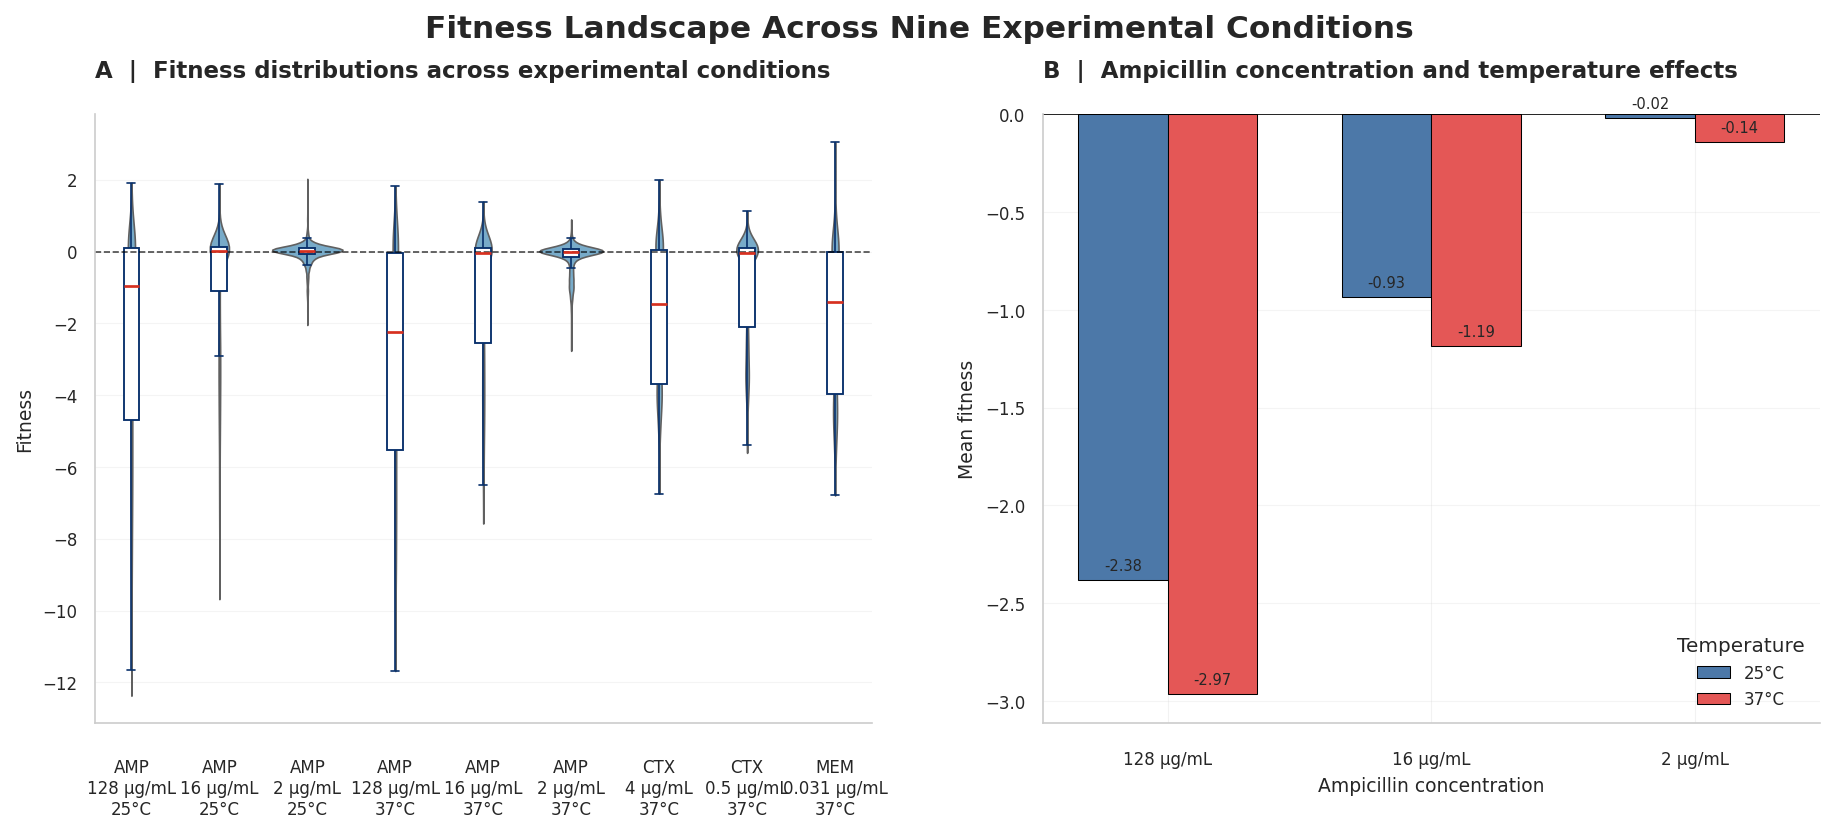

In [ ]:
# VIM-2 Figure 3 — Fitness Landscape | Q1 manuscript-ready final version
# Panel A: Fitness distributions across the nine experimental conditions
# Panel B: Ampicillin concentration and temperature effects
# Final layout: clean two-panel presentation with consistent title spacing
# improved separation of Panel A x-axis labels, and professional panel labels.

# VIM-2 Figure 3 — Fitness Landscape | Q1 manuscript-ready two-panel version
# Panel A: Fitness distributions across the nine experimental conditions
# Panel B: Ampicillin concentration and temperature effects
# Panel titles are separated from the plotting area for improved readability;
# A/B panel identifiers are integrated into each panel title.

# @title
# ============================================================
# FIGURE 3 — FITNESS LANDSCAPE
# Publication-quality two-panel figure for a Q1 manuscript
#
# Panel A — Fitness distributions across 9 experimental conditions
# Panel B — Ampicillin concentration and temperature effects
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


# ============================================================
# 1. LOAD VALIDATED DATASET
# ============================================================

DATA_FILE = "vim2_ml_features_part10b_validated.csv"

df = pd.read_csv(DATA_FILE)

print("=" * 70)
print("FIGURE 3 — FITNESS LANDSCAPE DATA VALIDATION")
print("=" * 70)

print(f"Total rows in dataset: {len(df)}")
print(f"Total columns in dataset: {len(df.columns)}")


# ============================================================
# 2. DEFINE THE NINE TRUE EXPERIMENTAL CONDITIONS
#
# IMPORTANT:
# Only these nine columns represent measured fitness.
#
# The corresponding *_SD columns contain uncertainty estimates.
# Fitness_AMP / Fitness_CTX / Fitness_MEM are summary variables
# and must NOT be treated as independent experimental conditions.
# ============================================================

condition_columns = [
    "128ug/mL_AMP_25C",
    "16ug/mL_AMP_25C",
    "2ug/mL_AMP_25C",
    "128ug/mL_AMP_37C",
    "16ug/mL_AMP_37C",
    "2ug/mL_AMP_37C",
    "4ug/mL_CTX_37C",
    "0.5ug/mL_CTX_37C",
    "0.031ug/mL_MEM_37C"
]


# Corresponding standard-deviation columns
sd_columns = [
    "128ug/mL_AMP_25C_SD",
    "16ug/mL_AMP_25C_SD",
    "2ug/mL_AMP_25C_SD",
    "128ug/mL_AMP_37C_SD",
    "16ug/mL_AMP_37C_SD",
    "2ug/mL_AMP_37C_SD",
    "4ug/mL_CTX_37C_SD",
    "0.5ug/mL_CTX_37C_SD",
    "0.031ug/mL_MEM_37C_SD"
]


# ============================================================
# 3. VALIDATE COLUMN STRUCTURE
# ============================================================

missing_conditions = [
    c for c in condition_columns
    if c not in df.columns
]

missing_sd = [
    c for c in sd_columns
    if c not in df.columns
]

if missing_conditions:
    raise ValueError(
        "Missing fitness condition columns:\n"
        + "\n".join(missing_conditions)
    )

if missing_sd:
    raise ValueError(
        "Missing standard-deviation columns:\n"
        + "\n".join(missing_sd)
    )


print("\n" + "=" * 70)
print("RAW FITNESS CONDITION COLUMNS")
print("=" * 70)

for i, c in enumerate(condition_columns, 1):
    print(f"{i:02d}. {c}")

print(f"\nNumber of true fitness conditions: {len(condition_columns)}")
print(f"Number of SD columns: {len(sd_columns)}")


# ============================================================
# 4. CONVERT FITNESS DATA TO NUMERIC
# ============================================================

for col in condition_columns + sd_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

missing_summary = df[
    condition_columns + sd_columns
].isna().sum()

if missing_summary.sum() > 0:

    print("\nWARNING — Missing values detected:")

    print(
        missing_summary[
            missing_summary > 0
        ]
    )

else:

    print("\nNo missing values detected in fitness/SD columns.")


# ============================================================
# 6. SHORT LABELS FOR FIGURE
# ============================================================

short_labels = [
    "AMP\n128 µg/mL\n25°C",
    "AMP\n16 µg/mL\n25°C",
    "AMP\n2 µg/mL\n25°C",

    "AMP\n128 µg/mL\n37°C",
    "AMP\n16 µg/mL\n37°C",
    "AMP\n2 µg/mL\n37°C",

    "CTX\n4 µg/mL\n37°C",
    "CTX\n0.5 µg/mL\n37°C",

    "MEM\n0.031 µg/mL\n37°C"
]


# ============================================================
# 7. LONG-FORM FITNESS TABLE
# ============================================================

fitness_long = df[
    condition_columns
].melt(
    var_name="Condition",
    value_name="Fitness"
)

condition_to_short = dict(
    zip(
        condition_columns,
        short_labels
    )
)

fitness_long["Condition_Label"] = (
    fitness_long["Condition"]
    .map(condition_to_short)
)


# ============================================================
# 8. SUMMARY STATISTICS
# ============================================================

summary = pd.DataFrame({
    "Condition": condition_columns,
    "Mean": [
        df[c].mean()
        for c in condition_columns
    ],
    "Median": [
        df[c].median()
        for c in condition_columns
    ],
    "SD": [
        df[c].std()
        for c in condition_columns
    ],
    "Min": [
        df[c].min()
        for c in condition_columns
    ],
    "Max": [
        df[c].max()
        for c in condition_columns
    ]
})

summary["Label"] = summary["Condition"].map(
    condition_to_short
)

print("\n" + "=" * 70)
print("FITNESS SUMMARY")
print("=" * 70)

display(
    summary[
        [
            "Label",
            "Mean",
            "Median",
            "SD",
            "Min",
            "Max"
        ]
    ].round(3)
)


# ============================================================
# 9. CALCULATE CONDITION CORRELATION
# ============================================================

corr_matrix = df[
    condition_columns
].corr(
    method="pearson"
)


# ============================================================
# 10. GLOBAL FITNESS
#
# Global fitness = mean fitness across all nine conditions.
# ============================================================

df["Global_Fitness_Figure3"] = (
    df[condition_columns]
    .mean(axis=1)
)


# ============================================================
# 11. CONDITION EFFECT SUMMARY
#
# AMP:
#   Compare 25°C vs 37°C at each concentration.
#
# This panel focuses on how concentration and temperature
# reshape the fitness landscape.
# ============================================================

amp_25 = [
    "128ug/mL_AMP_25C",
    "16ug/mL_AMP_25C",
    "2ug/mL_AMP_25C"
]

amp_37 = [
    "128ug/mL_AMP_37C",
    "16ug/mL_AMP_37C",
    "2ug/mL_AMP_37C"
]

amp_concentrations = [
    "128 µg/mL",
    "16 µg/mL",
    "2 µg/mL"
]

amp_means_25 = [
    df[c].mean()
    for c in amp_25
]

amp_means_37 = [
    df[c].mean()
    for c in amp_37
]


# ============================================================
# 12. PUBLICATION STYLE
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({

    "font.family": "DejaVu Sans",

    "font.size": 9,

    "axes.titlesize": 11,

    "axes.labelsize": 9,

    "xtick.labelsize": 8,

    "ytick.labelsize": 8,

    "legend.fontsize": 8,

    "axes.linewidth": 0.8,

    "grid.linewidth": 0.5,

    "grid.alpha": 0.25,

    "figure.dpi": 150,

    "savefig.dpi": 600
})


# ============================================================
# 13. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.8)
)

axA, axB = axes.flatten()


# ============================================================
# PANEL A
# FITNESS DISTRIBUTIONS ACROSS NINE CONDITIONS
# ============================================================

# Violin plot
sns.violinplot(
    data=fitness_long,
    x="Condition_Label",
    y="Fitness",
    ax=axA,
    inner=None,
    cut=0,
    linewidth=0.8,
    color="#6BAED6"
)

# Overlay boxplots
sns.boxplot(
    data=fitness_long,
    x="Condition_Label",
    y="Fitness",
    ax=axA,
    width=0.18,
    showcaps=True,
    showfliers=False,
    boxprops={
        "facecolor": "white",
        "edgecolor": "#08306B",
        "linewidth": 0.9
    },
    whiskerprops={
        "color": "#08306B",
        "linewidth": 0.8
    },
    capprops={
        "color": "#08306B",
        "linewidth": 0.8
    },
    medianprops={
        "color": "#D7301F",
        "linewidth": 1.3
    }
)

axA.axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--",
    alpha=0.7
)

axA.set_title(
    "A  |  Fitness distributions across experimental conditions",
    loc="left",
    fontweight="bold",
    pad=18
)

axA.set_xlabel("")
axA.set_ylabel("Fitness")

axA.tick_params(
    axis="x",
    rotation=0,
    pad=12
)

# Slightly widen the categorical spacing without changing the data order.
axA.margins(x=0.04)


# ============================================================
# PANEL B
# AMPICILLIN CONCENTRATION AND TEMPERATURE EFFECTS
# ============================================================

x = np.arange(
    len(amp_concentrations)
)

width = 0.34

bars25 = axB.bar(
    x - width / 2,
    amp_means_25,
    width,
    label="25°C",
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.5
)

bars37 = axB.bar(
    x + width / 2,
    amp_means_37,
    width,
    label="37°C",
    color="#E45756",
    edgecolor="black",
    linewidth=0.5
)

axB.axhline(
    0,
    color="black",
    linewidth=0.8
)

axB.set_xticks(x)

axB.set_xticklabels(
    amp_concentrations
)

axB.tick_params(axis="x", pad=8)

axB.set_xlabel(
    "Ampicillin concentration"
)

axB.set_ylabel(
    "Mean fitness"
)

axB.set_title(
    "B  |  Ampicillin concentration and temperature effects",
    loc="left",
    fontweight="bold",
    pad=18
)

axB.legend(
    frameon=False,
    title="Temperature"
)

# Add numerical values above bars
for bars in [bars25, bars37]:

    for bar in bars:

        height = bar.get_height()

        axB.text(
            bar.get_x() + bar.get_width() / 2,
            height - (0.035 if height >= 0 else -0.035),
            f"{height:.2f}",
            ha="center",
            va="top" if height >= 0 else "bottom",
            fontsize=7
        )


# ============================================================
# 14. PANEL SPACING REFINEMENT
# ============================================================

for ax in [
    axA,
    axB
]:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.20
    )



# ============================================================
# 15. MAIN FIGURE TITLE
# ============================================================

fig.suptitle(
    "Fitness Landscape Across Nine Experimental Conditions",
    fontsize=15,
    fontweight="bold",
    y=0.995
)


# ============================================================
# 16. LAYOUT
# ============================================================

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.18,
    top=0.88,
    wspace=0.22
)


# ============================================================
# 17. SAVE HIGH-RESOLUTION FIGURES
# ============================================================

output_png = (
    "Figure_3_Fitness_Landscape_AB_Q1.png"
)

output_pdf = (
    "Figure_3_Fitness_Landscape_AB_Q1.pdf"
)

output_svg = (
    "Figure_3_Fitness_Landscape_AB_Q1.svg"
)


fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    output_svg,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# 18. FINAL VALIDATION OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("FIGURE 3 — COMPLETE")
print("=" * 70)

print(
    f"Mutations included: {len(df)}"
)

print(
    f"Experimental conditions: {len(condition_columns)}"
)

print(
    "Fitness conditions:"
)

for c in condition_columns:
    print(
        f"  - {c}"
    )



print("\nFigure files saved:")

print(
    output_png
)

print(
    output_pdf
)

print(
    output_svg
)

print("=" * 70)

plt.show()

FIGURE 4 — TARGET DATA VALIDATION
Total mutations: 5016

Global_Beneficial        : 1323 (26.38%)
Broadly_Positive         :  883 (17.60%)
Globally_Positive        :  279 ( 5.56%)
Environment_Dependent    : 1254 (25.00%)

FIGURE 4 — COMPLETE
Total mutations: 5016

Global_Beneficial: 1,323 (26.38%)
Broadly_Positive: 883 (17.60%)
Globally_Positive: 279 (5.56%)
Environment_Dependent: 1,254 (25.00%)

Files generated successfully:
Figure4_Target_Definitions_Relationships.png
Figure4_Target_Definitions_Relationships.pdf
Figure4_Target_Definitions_Relationships.svg


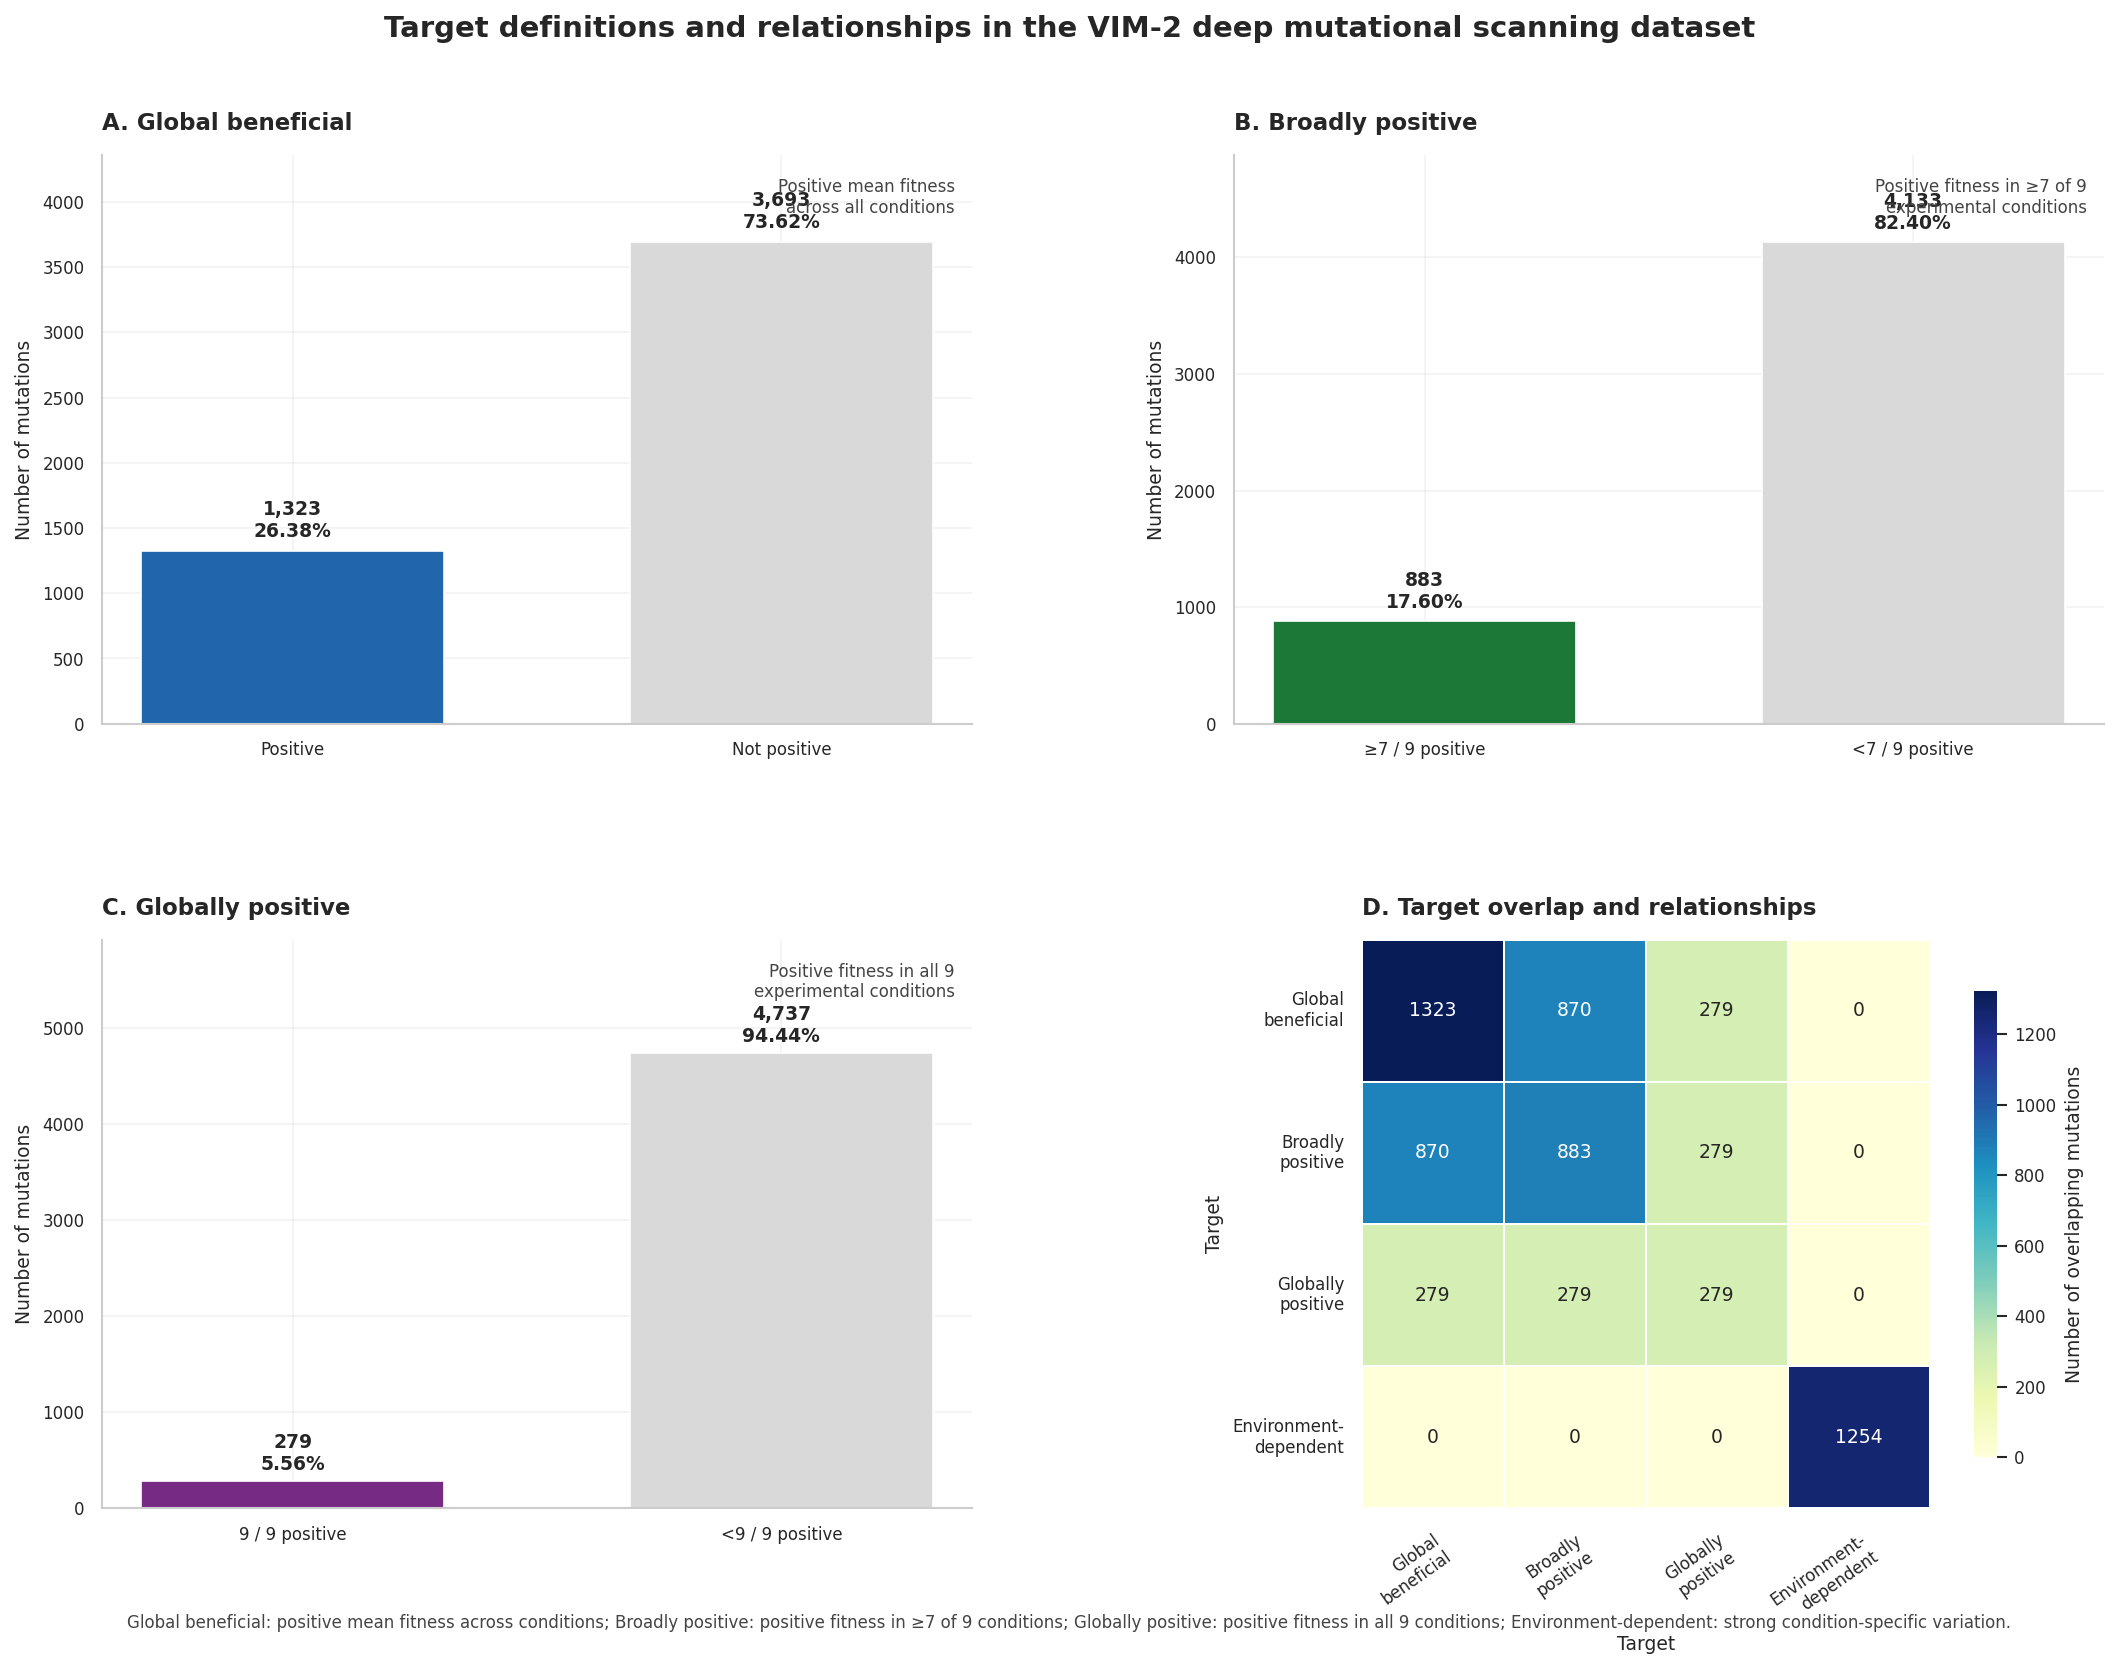

In [ ]:
# @title
# ============================================================
# FIGURE 4 — TARGET DEFINITIONS AND RELATIONSHIPS
#
# Publication-quality visualization of the four classification
# targets generated from the VIM-2 deep mutational scanning data.
#
# Panels:
#   A. Global Beneficial
#   B. Broadly Positive
#   C. Globally Positive
#   D. Target overlap / relationship heatmap
#
# Dataset:
#   vim2_ml_features_part10b_validated.csv
#
# Designed for manuscript-quality figures.
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Patch


# ============================================================
# PUBLICATION STYLE
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False
})


# ============================================================
# LOAD VALIDATED DATASET
# ============================================================

DATASET_PATH = (
    "vim2_ml_features_part10b_validated.csv"
)

df = pd.read_csv(
    DATASET_PATH
)


# ============================================================
# TARGET COLUMNS
# ============================================================

target_columns = [
    "Global_Beneficial",
    "Broadly_Positive",
    "Globally_Positive",
    "Environment_Dependent"
]


# ============================================================
# VALIDATE TARGET COLUMNS
# ============================================================

missing_targets = [
    col
    for col in target_columns
    if col not in df.columns
]

if missing_targets:

    raise ValueError(
        "Missing target columns:\n"
        + "\n".join(missing_targets)
    )


# ============================================================
# FORCE TARGETS TO INTEGER BINARY FORMAT
# ============================================================

for col in target_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    if df[col].isna().any():

        raise ValueError(
            f"Target column contains missing/non-numeric "
            f"values: {col}"
        )

    df[col] = (
        df[col]
        .astype(int)
    )


# ============================================================
# VALIDATE BINARY TARGETS
# ============================================================

for col in target_columns:

    unique_values = set(
        df[col].unique()
    )

    if not unique_values.issubset({0, 1}):

        raise ValueError(
            f"{col} is not binary. "
            f"Detected values: {unique_values}"
        )


# ============================================================
# BASIC SUMMARY
# ============================================================

print("=" * 70)
print("FIGURE 4 — TARGET DATA VALIDATION")
print("=" * 70)

print(
    f"Total mutations: {len(df)}"
)

print()

for col in target_columns:

    count = int(
        df[col].sum()
    )

    percentage = (
        count / len(df) * 100
    )

    print(
        f"{col:25s}: "
        f"{count:4d} "
        f"({percentage:5.2f}%)"
    )


# ============================================================
# TARGET COUNTS
# ============================================================

target_counts = (
    df[target_columns]
    .sum()
)


target_percentages = (
    target_counts
    / len(df)
    * 100
)


# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(15, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.30,
    hspace=0.38
)


axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])


# ============================================================
# COLOR PALETTE
# ============================================================

COLORS = {
    "Global_Beneficial": "#2166AC",
    "Broadly_Positive": "#1B7837",
    "Globally_Positive": "#762A83",
    "Environment_Dependent": "#E08214"
}


# ============================================================
# PANEL A — GLOBAL BENEFICIAL
# ============================================================

global_positive = int(
    df["Global_Beneficial"].sum()
)

global_negative = (
    len(df)
    - global_positive
)


values_A = [
    global_positive,
    global_negative
]

labels_A = [
    "Positive",
    "Not positive"
]


bars_A = axA.bar(
    labels_A,
    values_A,
    color=[
        COLORS["Global_Beneficial"],
        "#D9D9D9"
    ],
    width=0.62
)


# Add counts and percentages
for bar, value in zip(
    bars_A,
    values_A
):

    percentage = (
        value
        / len(df)
        * 100
    )

    axA.text(
        bar.get_x()
        + bar.get_width() / 2,
        value
        + len(df) * 0.015,
        f"{value:,}\n"
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )


axA.set_ylabel(
    "Number of mutations"
)

axA.set_title(
    "A. Global beneficial",
    loc="left",
    fontweight="bold",
    pad=12
)

axA.set_ylim(
    0,
    max(values_A) * 1.18
)


# Definition annotation
axA.text(
    0.98,
    0.96,
    "Positive mean fitness\nacross all conditions",
    transform=axA.transAxes,
    ha="right",
    va="top",
    fontsize=8,
    color="#444444"
)


# ============================================================
# PANEL B — BROADLY POSITIVE
# ============================================================

broad_positive = int(
    df["Broadly_Positive"].sum()
)

broad_negative = (
    len(df)
    - broad_positive
)


values_B = [
    broad_positive,
    broad_negative
]

labels_B = [
    "≥7 / 9 positive",
    "<7 / 9 positive"
]


bars_B = axB.bar(
    labels_B,
    values_B,
    color=[
        COLORS["Broadly_Positive"],
        "#D9D9D9"
    ],
    width=0.62
)


for bar, value in zip(
    bars_B,
    values_B
):

    percentage = (
        value
        / len(df)
        * 100
    )

    axB.text(
        bar.get_x()
        + bar.get_width() / 2,
        value
        + len(df) * 0.015,
        f"{value:,}\n"
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )


axB.set_ylabel(
    "Number of mutations"
)

axB.set_title(
    "B. Broadly positive",
    loc="left",
    fontweight="bold",
    pad=12
)

axB.set_ylim(
    0,
    max(values_B) * 1.18
)


axB.text(
    0.98,
    0.96,
    "Positive fitness in ≥7 of 9\n"
    "experimental conditions",
    transform=axB.transAxes,
    ha="right",
    va="top",
    fontsize=8,
    color="#444444"
)


# ============================================================
# PANEL C — GLOBALLY POSITIVE
# ============================================================

global_positive_strict = int(
    df["Globally_Positive"].sum()
)

global_not_positive = (
    len(df)
    - global_positive_strict
)


values_C = [
    global_positive_strict,
    global_not_positive
]

labels_C = [
    "9 / 9 positive",
    "<9 / 9 positive"
]


bars_C = axC.bar(
    labels_C,
    values_C,
    color=[
        COLORS["Globally_Positive"],
        "#D9D9D9"
    ],
    width=0.62
)


for bar, value in zip(
    bars_C,
    values_C
):

    percentage = (
        value
        / len(df)
        * 100
    )

    axC.text(
        bar.get_x()
        + bar.get_width() / 2,
        value
        + len(df) * 0.015,
        f"{value:,}\n"
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )


axC.set_ylabel(
    "Number of mutations"
)

axC.set_title(
    "C. Globally positive",
    loc="left",
    fontweight="bold",
    pad=12
)

axC.set_ylim(
    0,
    max(values_C) * 1.25
)


axC.text(
    0.98,
    0.96,
    "Positive fitness in all 9\n"
    "experimental conditions",
    transform=axC.transAxes,
    ha="right",
    va="top",
    fontsize=8,
    color="#444444"
)


# ============================================================
# PANEL D — TARGET RELATIONSHIP HEATMAP
# ============================================================

# ------------------------------------------------------------
# Calculate pairwise overlap counts.
#
# Each cell represents the number of mutations that are
# positive for BOTH targets in the corresponding row and
# column.
# ------------------------------------------------------------

overlap_matrix = np.zeros(
    (len(target_columns), len(target_columns)),
    dtype=int
)


for i, target_i in enumerate(
    target_columns
):

    for j, target_j in enumerate(
        target_columns
    ):

        overlap_matrix[i, j] = int(
            (
                (df[target_i] == 1)
                &
                (df[target_j] == 1)
            )
            .sum()
        )


# ------------------------------------------------------------
# Short labels for the heatmap.
# ------------------------------------------------------------

short_target_labels = [
    "Global\nbeneficial",
    "Broadly\npositive",
    "Globally\npositive",
    "Environment-\ndependent"
]


# ------------------------------------------------------------
# Plot overlap heatmap.
# ------------------------------------------------------------

sns.heatmap(
    overlap_matrix,
    ax=axD,
    cmap="YlGnBu",
    annot=True,
    fmt="d",
    square=True,
    linewidths=0.8,
    linecolor="white",
    xticklabels=short_target_labels,
    yticklabels=short_target_labels,
    cbar_kws={
        "label": "Number of overlapping mutations",
        "shrink": 0.82
    }
)


axD.set_title(
    "D. Target overlap and relationships",
    loc="left",
    fontweight="bold",
    pad=12
)


axD.set_xlabel(
    "Target"
)

axD.set_ylabel(
    "Target"
)


axD.tick_params(
    axis="x",
    rotation=35,
    pad=6
)

axD.tick_params(
    axis="y",
    rotation=0
)


# ------------------------------------------------------------
# Improve x-axis label alignment.
# ------------------------------------------------------------

for label in axD.get_xticklabels():

    label.set_horizontalalignment(
        "right"
    )

    label.set_rotation_mode(
        "anchor"
    )


# ============================================================
# ADD FIGURE TITLE
# ============================================================

fig.suptitle(
    "Target definitions and relationships in the VIM-2 "
    "deep mutational scanning dataset",
    fontsize=14,
    fontweight="bold",
    y=0.995
)


# ============================================================
# FIGURE FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.015,
    "Global beneficial: positive mean fitness across conditions; "
    "Broadly positive: positive fitness in ≥7 of 9 conditions; "
    "Globally positive: positive fitness in all 9 conditions; "
    "Environment-dependent: strong condition-specific variation.",
    ha="center",
    va="bottom",
    fontsize=8,
    color="#444444"
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.subplots_adjust(
    top=0.91,
    bottom=0.09,
    left=0.07,
    right=0.96
)


# ============================================================
# SAVE PUBLICATION-QUALITY FIGURES
# ============================================================

FIGURE_PNG = (
    "Figure4_Target_Definitions_Relationships.png"
)

FIGURE_PDF = (
    "Figure4_Target_Definitions_Relationships.pdf"
)

FIGURE_SVG = (
    "Figure4_Target_Definitions_Relationships.svg"
)


fig.savefig(
    FIGURE_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    FIGURE_PDF,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    FIGURE_SVG,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# FINAL VALIDATION OUTPUT
# ============================================================

print()
print("=" * 70)
print("FIGURE 4 — COMPLETE")
print("=" * 70)

print(
    f"Total mutations: {len(df)}"
)

print()

for col in target_columns:

    count = int(
        df[col].sum()
    )

    percentage = (
        count
        / len(df)
        * 100
    )

    print(
        f"{col}: "
        f"{count:,} "
        f"({percentage:.2f}%)"
    )

print()
print(
    "Files generated successfully:"
)

print(
    FIGURE_PNG
)

print(
    FIGURE_PDF
)

print(
    FIGURE_SVG
)


plt.show()

(5016, 50)
FIGURE 1 — ORIGINAL DATASET LOADED
Dataset shape: (5549, 24)

Columns:
['index', 'wt residue', 'position', 'variant residue', 'identity', 'group', '128ug/mL_AMP_25C', '128ug/mL_AMP_25C_SD', '16ug/mL_AMP_25C', '16ug/mL_AMP_25C_SD', '2ug/mL_AMP_25C', '2ug/mL_AMP_25C_SD', '128ug/mL_AMP_37C', '128ug/mL_AMP_37C_SD', '16ug/mL_AMP_37C', '16ug/mL_AMP_37C_SD', '2ug/mL_AMP_37C', '2ug/mL_AMP_37C_SD', '4ug/mL_CTX_37C', '4ug/mL_CTX_37C_SD', '0.5ug/mL_CTX_37C', '0.5ug/mL_CTX_37C_SD', '0.031ug/mL_MEM_37C', '0.031ug/mL_MEM_37C_SD']

DATASET COMPOSITION
Missense      5035
Stop codon     267
Synonymous     247
dtype: int64

MISSENSE COVERAGE
Unique positions: 266
Minimum substitutions: 13
Maximum substitutions: 19
Mean substitutions: 18.86

POSITIVE CONDITION COUNT DISTRIBUTION
0    830
1    657
2    635
3    529
4    568
5    584
6    340
7    289
8    321
9    282
Name: count, dtype: int64

FITNESS CORRELATION MATRIX CALCULATED


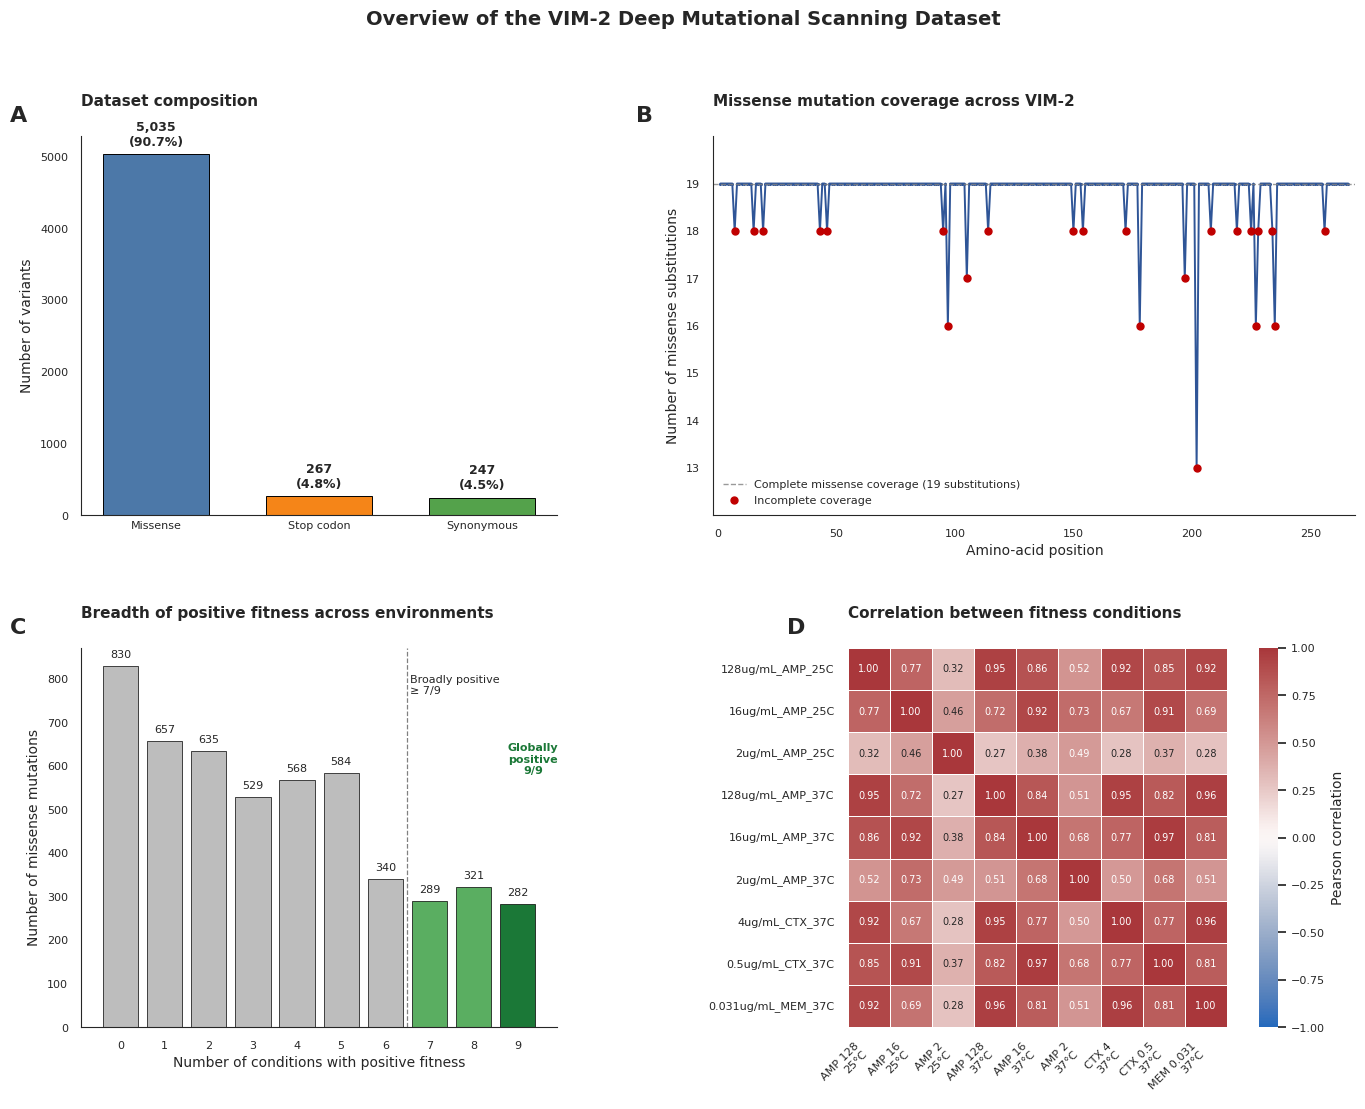


FIGURE 1 COMPLETED SUCCESSFULLY
SVG: Figure1_VIM2_Dataset_Overview.svg
PDF: Figure1_VIM2_Dataset_Overview.pdf
PNG: Figure1_VIM2_Dataset_Overview.png

Figure panels:
A — Dataset composition
B — Missense mutation coverage
C — Breadth of positive fitness
D — Fitness condition correlation
FIGURE 2 — DATASET VALIDATION
Number of mutations used: 5016
Hydrophobicity_Change: 5016 valid values
Charge_Change: 5016 valid values
Weight_Change: 5016 valid values
BLOSUM62: 5016 valid values


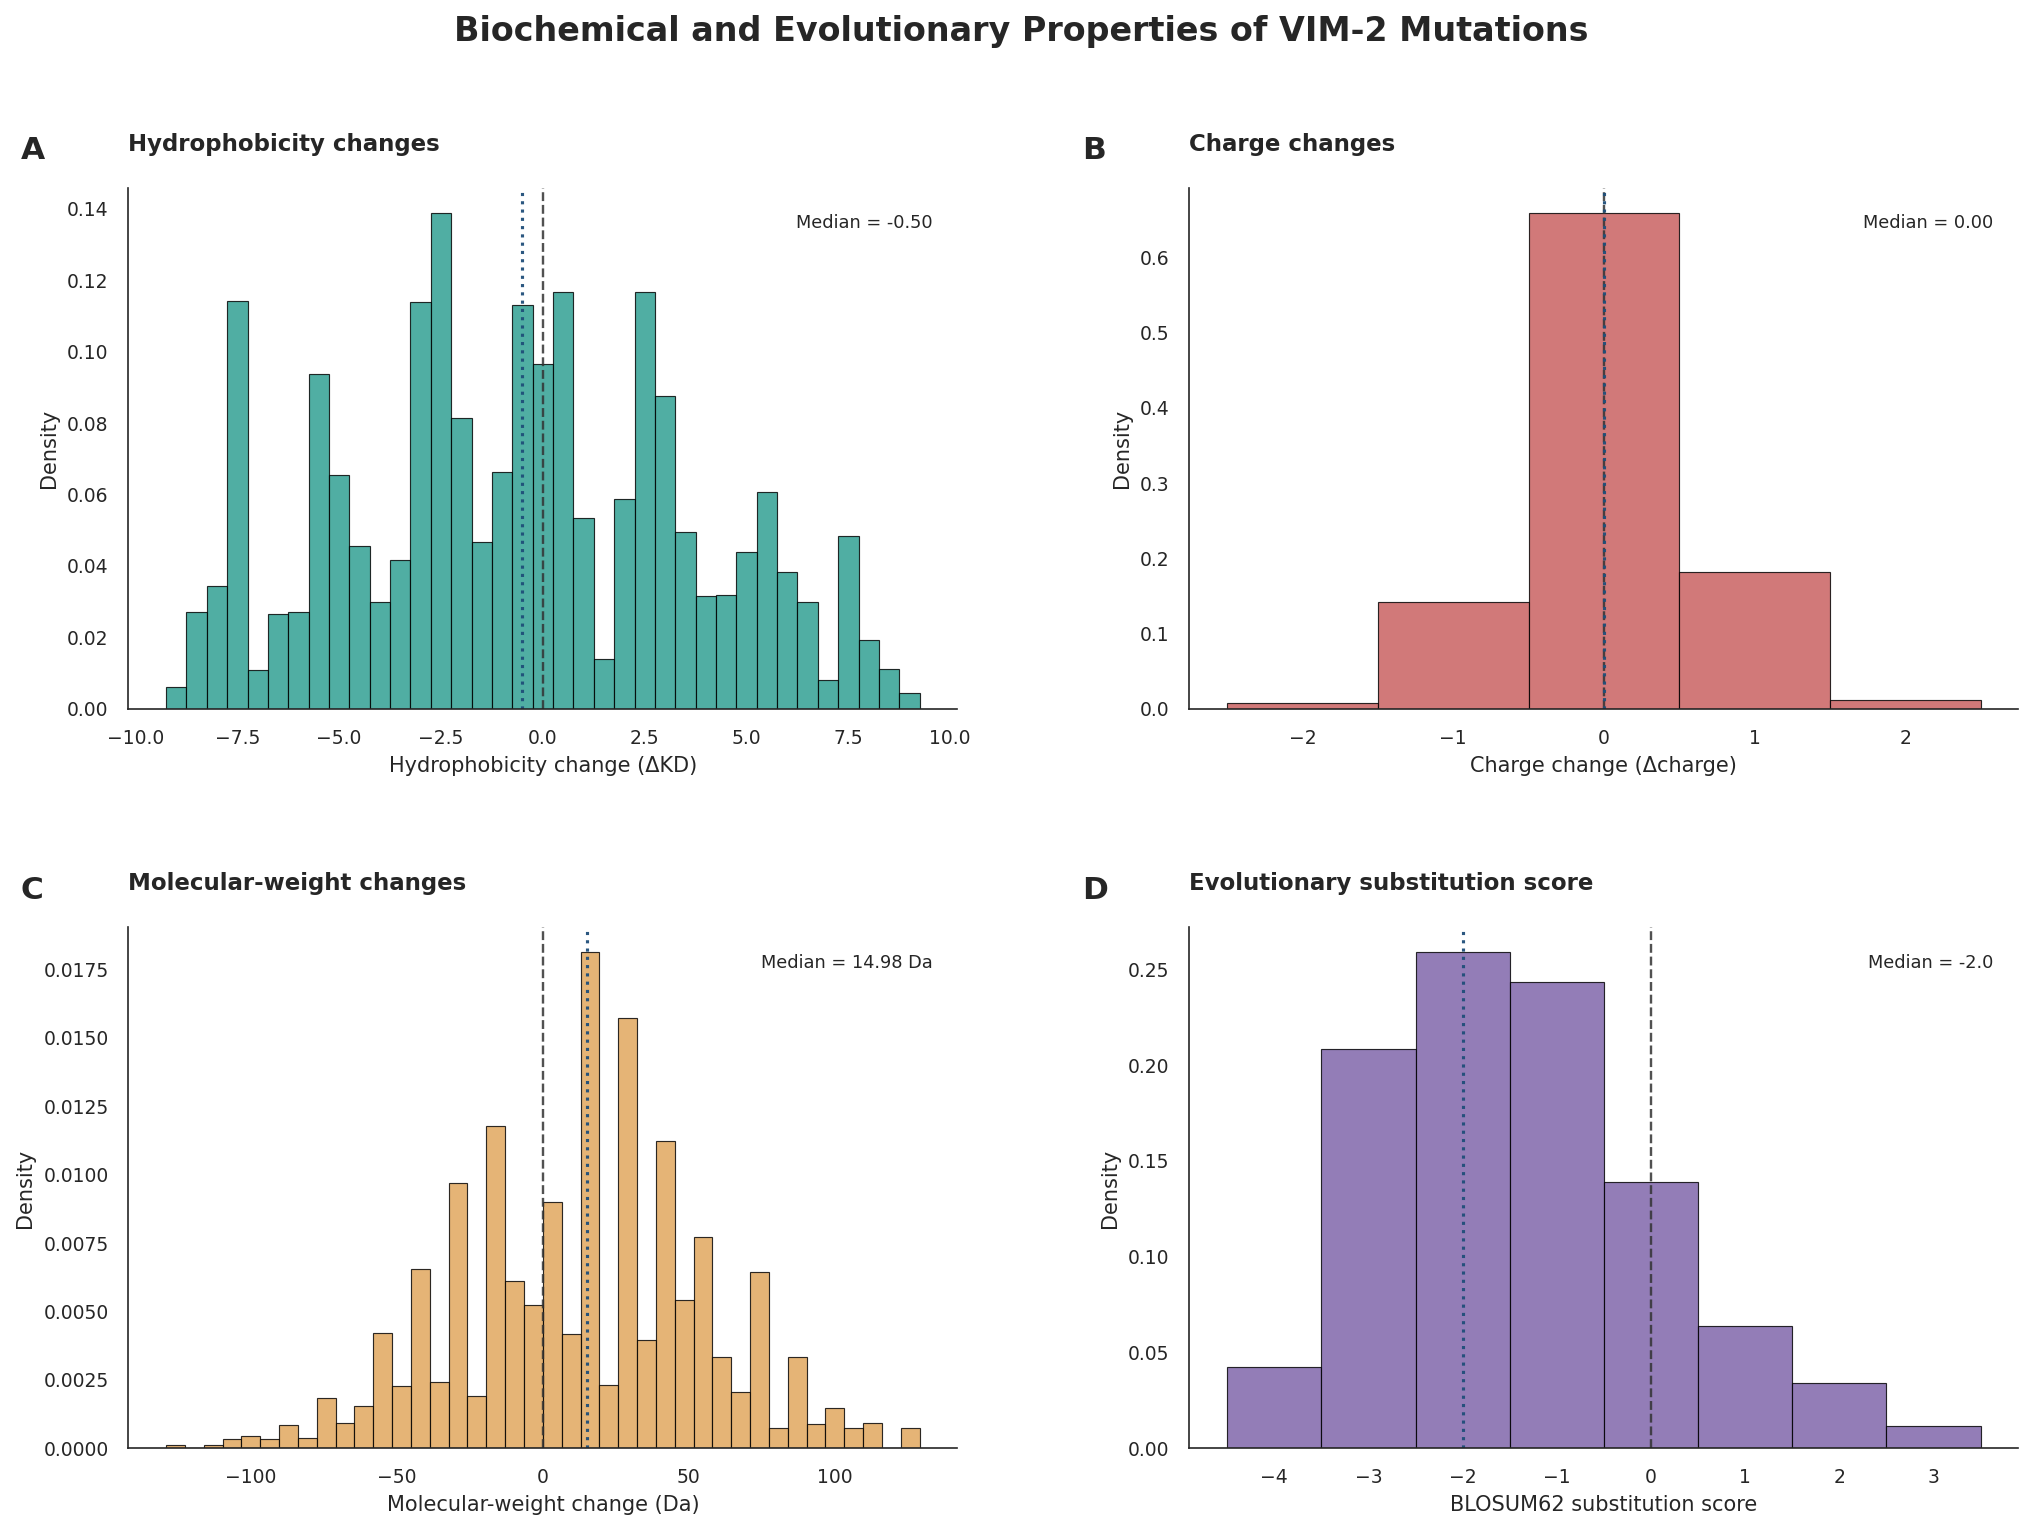


FIGURE 2 — COMPLETE
Mutations included: 5016
Hydrophobicity range: -9.00 to 9.00
Charge range: -2.00 to 2.00
Weight-change range: -129.16 to 129.16 Da
BLOSUM62 range: -4.0 to 3.0

Publication files saved:
  Figure_2_VIM2_Biochemical_Evolutionary_Properties.pdf
  Figure_2_VIM2_Biochemical_Evolutionary_Properties.svg
  Figure_2_VIM2_Biochemical_Evolutionary_Properties.png
FIGURE 3 — FITNESS LANDSCAPE DATA VALIDATION
Total rows in dataset: 5016
Total columns in dataset: 50

RAW FITNESS CONDITION COLUMNS
01. 128ug/mL_AMP_25C
02. 16ug/mL_AMP_25C
03. 2ug/mL_AMP_25C
04. 128ug/mL_AMP_37C
05. 16ug/mL_AMP_37C
06. 2ug/mL_AMP_37C
07. 4ug/mL_CTX_37C
08. 0.5ug/mL_CTX_37C
09. 0.031ug/mL_MEM_37C

Number of true fitness conditions: 9
Number of SD columns: 9

WARNING — Missing values detected:
128ug/mL_AMP_25C          7
16ug/mL_AMP_25C           7
2ug/mL_AMP_25C            7
128ug/mL_AMP_37C         12
16ug/mL_AMP_37C          12
2ug/mL_AMP_37C           12
4ug/mL_CTX_37C           12
0.5ug/mL_CTX_37C

,Label,Mean,Median,SD,Min,Max
0,AMP\n128 µg/mL\n25°C,-2.384,-0.955,3.000,-12.371,1.914
1,AMP\n16 µg/mL\n25°C,-0.933,0.024,1.898,-9.680,1.895
2,AMP\n2 µg/mL\n25°C,-0.017,0.022,0.252,-2.044,2.025
3,AMP\n128 µg/mL\n37°C,-2.967,-2.251,3.164,-11.683,1.815
4,AMP\n16 µg/mL\n37°C,-1.186,-0.027,1.981,-7.574,1.392
5,AMP\n2 µg/mL\n37°C,-0.142,-0.013,0.392,-2.765,0.895
6,CTX\n4 µg/mL\n37°C,-1.783,-1.456,1.927,-6.743,1.999
7,CTX\n0.5 µg/mL\n37°C,-0.898,-0.032,1.483,-5.606,1.131
8,MEM\n0.031 µg/mL\n37°C,-1.929,-1.403,2.096,-6.792,3.050


/tmp/ipykernel_1908/589349507.py:2257: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axD.legend(



FIGURE 3 — COMPLETE
Mutations included: 5016
Experimental conditions: 9
Fitness conditions:
  - 128ug/mL_AMP_25C
  - 16ug/mL_AMP_25C
  - 2ug/mL_AMP_25C
  - 128ug/mL_AMP_37C
  - 16ug/mL_AMP_37C
  - 2ug/mL_AMP_37C
  - 4ug/mL_CTX_37C
  - 0.5ug/mL_CTX_37C
  - 0.031ug/mL_MEM_37C

Global fitness range: -6.089 to 0.987

Figure files saved:
Figure_3_Fitness_Landscape.png
Figure_3_Fitness_Landscape.pdf
Figure_3_Fitness_Landscape.svg


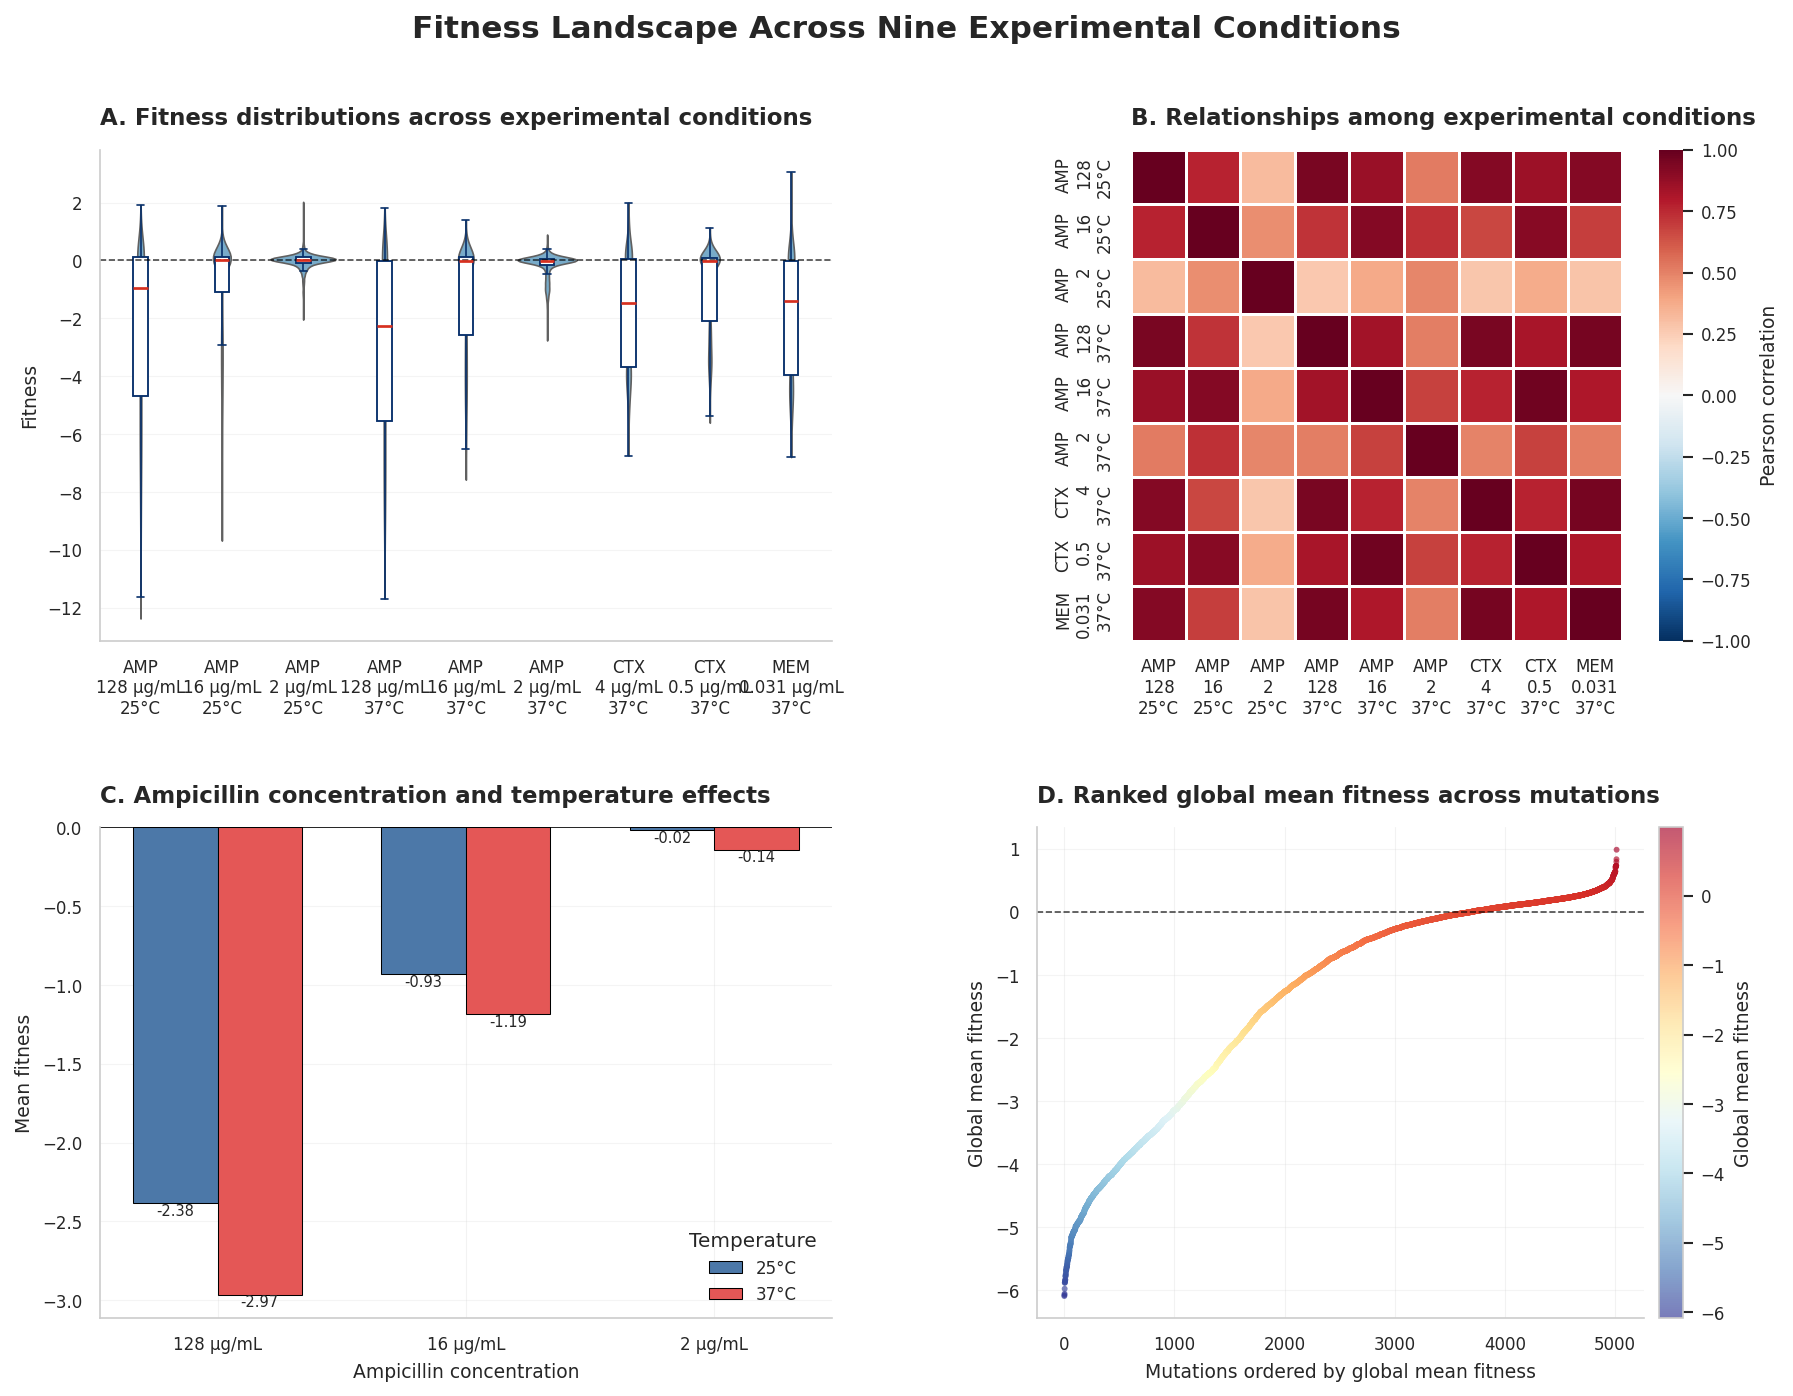

FIGURE 4 — TARGET DATA VALIDATION
Total mutations: 5016

Global_Beneficial        : 1323 (26.38%)
Broadly_Positive         :  883 (17.60%)
Globally_Positive        :  279 ( 5.56%)
Environment_Dependent    : 1254 (25.00%)

FIGURE 4 — COMPLETE
Total mutations: 5016

Global_Beneficial: 1,323 (26.38%)
Broadly_Positive: 883 (17.60%)
Globally_Positive: 279 (5.56%)
Environment_Dependent: 1,254 (25.00%)

Files generated successfully:
Figure4_Target_Definitions_Relationships.png
Figure4_Target_Definitions_Relationships.pdf
Figure4_Target_Definitions_Relationships.svg


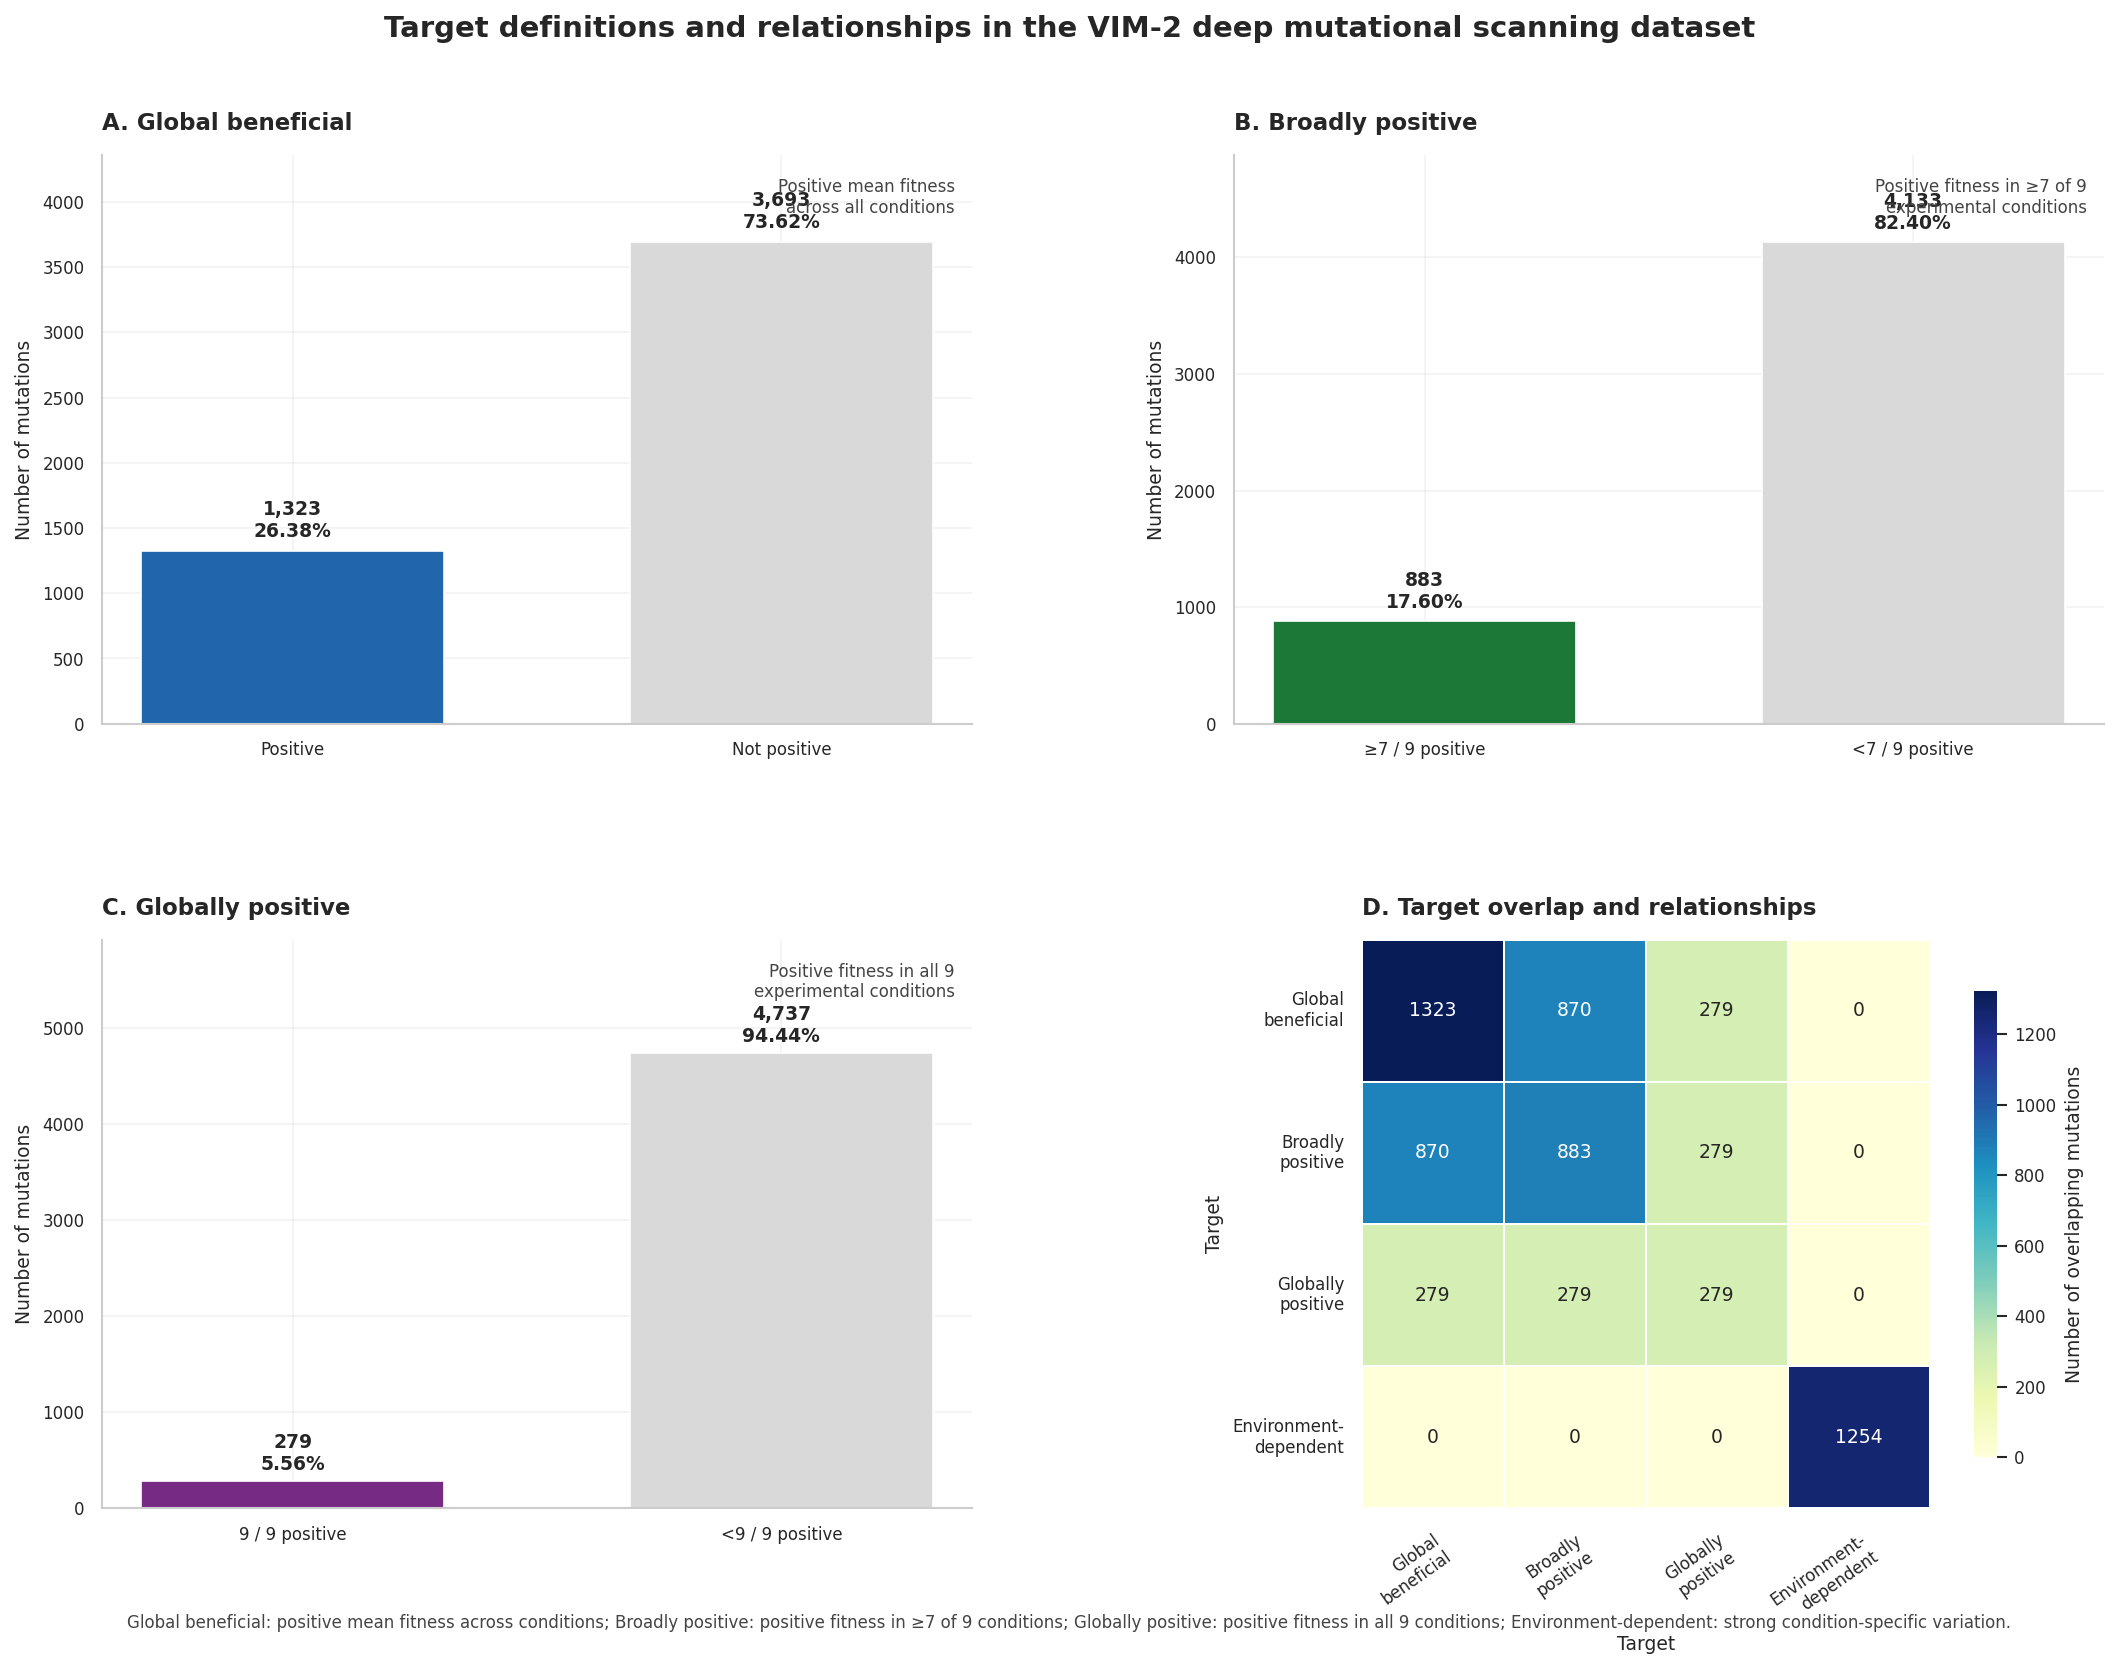

FIGURE 5 — STRUCTURAL AND MOLECULAR CONTEXT OF VIM-2 MUTATIONS
Input file: VIM2_Part12D_Hydrogen_Bonding.csv
Rows    : 5,016
Columns : 76

Schema validation: PASSED
Position column : position
Mutation column : Mutation
Required biological features : 19

Feature coverage
----------------
                          Feature  N_total  N_available  N_missing  Coverage_percent
           Distance_to_Metal_Site     5016         4335        681         86.423445
   Distance_to_Active_Site_Pocket     5016         4335        681         86.423445
              Distance_to_L3_Loop     5016         4335        681         86.423445
             Distance_to_L10_Loop     5016         4335        681         86.423445
                             SASA     5016         4335        681         86.423445
       Local_Hydrophobic_Fraction     5016         5016          0        100.000000
           Local_Charged_Fraction     5016         5016          0        100.000000
   Local_Positive_Charge_Fractio

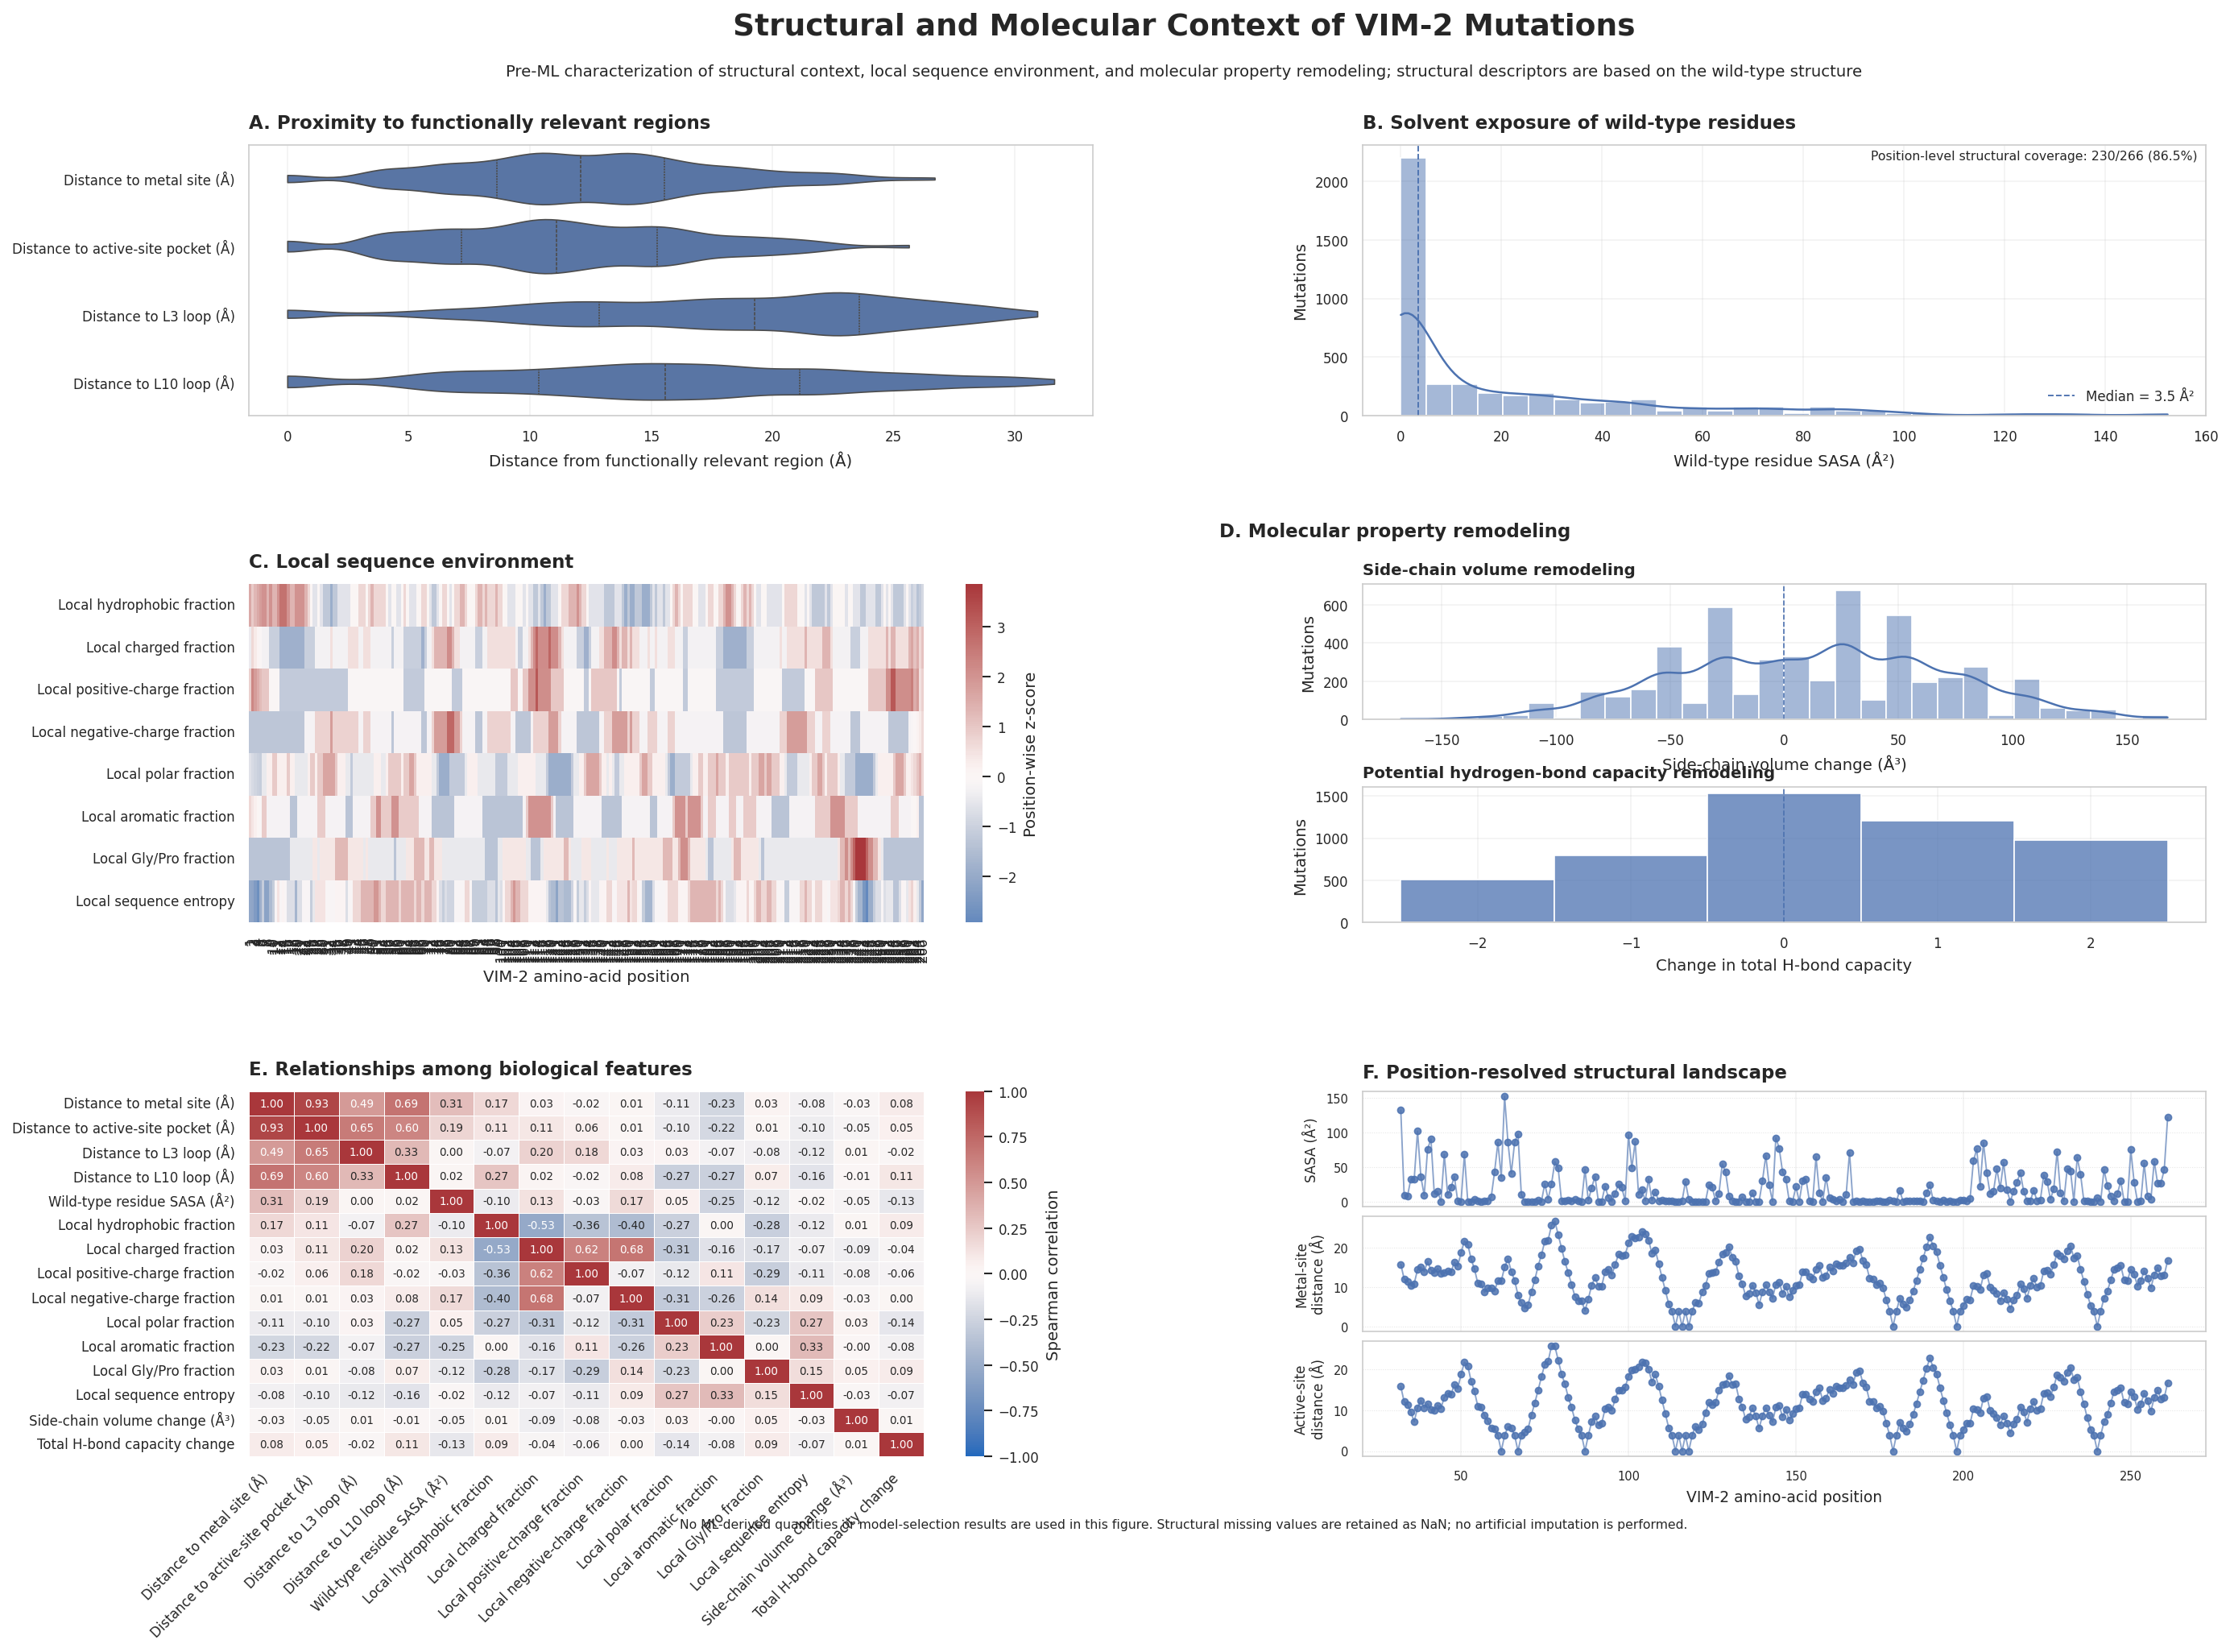


FIGURE 5 COMPLETED SUCCESSFULLY
PNG : Figure_5_Structural_Molecular_Context.png
PDF : Figure_5_Structural_Molecular_Context.pdf
SVG : Figure_5_Structural_Molecular_Context.svg

Validation summary:
- Explicit biological position column validated.
- Required Figure 5 feature schema validated.
- Structural missing values retained as NaN.
- No artificial structural imputation performed.
- Deleted Part 12I features excluded.
- Figure 2 biochemical features excluded from Figure 5.
- No ML-derived feature importance or model-selection results used.
- Position-resolved structural tracks are broken across sequence gaps.
- Correlation panel uses non-redundant representatives of derived volume metrics.
- Structural coverage is reported at the residue-position level.


In [ ]:
# @title
# ============================================================
# FIGURE 5 — BIOLOGICAL INTERPRETATION OF MUTATION EFFECTS
# VIM-2 MUTATION DATASET
#
# Publication-oriented visualization for a Q1 manuscript
#
# IMPORTANT DESIGN PRINCIPLES
# ------------------------------------------------------------
# 1. Only biological features that were NOT presented in
#    Figures 1–4 are visualized here.
#
# 2. Features generated in the deleted Part 12I are NOT used.
#
# 3. Structural features derived from the PDB structure are
#    allowed to contain missing values because the experimental
#    structure does not cover every residue.
#
# 4. Structural missing values are NOT replaced by zero,
#    mean, median, or any artificial value.
#
# 5. Each structural analysis uses only residues for which
#    the corresponding structural measurement is available.
#
# 6. Structural coverage is explicitly reported so that
#    missing values are transparently attributable to limited
#    PDB residue coverage rather than preprocessing errors.
#
# 7. The figure focuses on mutation-level biological context
#    and does not repeat the fitness landscape or target
#    definitions shown in Figures 3 and 4.
#
# Output:
#   - Figure_5_Biological_Interpretation.png  (600 dpi)
#   - Figure_5_Biological_Interpretation.pdf
#   - Figure_5_Biological_Interpretation.svg
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT REQUIRED PACKAGES
# ============================================================

!pip -q install pandas numpy matplotlib seaborn scipy openpyxl


import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from google.colab import files

warnings.filterwarnings("ignore")


# ============================================================
# 1. GLOBAL PUBLICATION SETTINGS
# ============================================================

# Use a clean publication-oriented style.
# No specific colors are hard-coded so that the plotting
# library can retain a neutral scientific palette.

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.15
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


# ============================================================
# 2. INPUT DATASET
# ============================================================

INPUT_FILE = "VIM2_Part12D_Hydrogen_Bonding.csv"

print(f"\nInput file: {INPUT_FILE}")


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("\nDataset dimensions:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")


# ============================================================
# 4. STANDARDIZE COLUMN NAMES
# ============================================================

# Remove accidental whitespace from column names.
df.columns = (
    df.columns
      .astype(str)
      .str.strip()
)


# ============================================================
# 5. DEFINE FEATURE GROUPS
# ============================================================

# ------------------------------------------------------------
# Structural / functional context
# ------------------------------------------------------------

STRUCTURAL_FEATURES = [
    "Distance_to_Metal_Site",
    "Distance_to_Active_Site_Pocket",
    "Distance_to_L3_Loop",
    "Distance_to_L10_Loop",
    "SASA"
]


# ------------------------------------------------------------
# Local sequence context
# ------------------------------------------------------------

LOCAL_SEQUENCE_FEATURES = [
    "Local_Hydrophobic_Fraction",
    "Local_Charged_Fraction",
    "Local_Positive_Charge_Fraction",
    "Local_Negative_Charge_Fraction",
    "Local_Polar_Fraction",
    "Local_Aromatic_Fraction",
    "Local_Gly_Pro_Fraction",
    "Local_Sequence_Entropy"
]


# ------------------------------------------------------------
# Side-chain remodeling
#
# We deliberately prioritize relative/absolute volume change
# rather than repeating the molecular-weight analysis already
# presented in Figure 2.
# ------------------------------------------------------------

SIDECHAIN_FEATURES = [
    "Side_Chain_Volume_Change",
    "Absolute_Side_Chain_Volume_Change",
    "Relative_Side_Chain_Volume_Change"
]


# ------------------------------------------------------------
# Hydrogen-bond remodeling
# ------------------------------------------------------------

HBOND_FEATURES = [
    "HBond_Donor_Change",
    "HBond_Acceptor_Change",
    "Total_HBond_Capacity_Change"
]


# ------------------------------------------------------------
# Explicitly excluded features
# ------------------------------------------------------------

# These were already represented in previous figures or belong
# to the deleted Part 12I structural feature set.

EXCLUDED_FEATURES = [
    # Figure 2
    "Hydrophobicity_Change",
    "Weight_Change",
    "Charge_Change",
    "BLOSUM62",

    # Part 12I — intentionally removed
    "Residue_Surface_Depth_Proxy",
    "CA_Contact_Count",
    "CA_Contact_Density",
    "Local_Packing_Density",
    "CA_BFactor",
    "Normalized_CA_BFactor",
    "Local_Flexibility_Relative"
]


# ============================================================
# 6. VERIFY FEATURE AVAILABILITY
# ============================================================

ALL_REQUESTED_FEATURES = (
    STRUCTURAL_FEATURES
    + LOCAL_SEQUENCE_FEATURES
    + SIDECHAIN_FEATURES
    + HBOND_FEATURES
)

available_features = [
    f for f in ALL_REQUESTED_FEATURES
    if f in df.columns
]

missing_columns = [
    f for f in ALL_REQUESTED_FEATURES
    if f not in df.columns
]

print("\nFeature availability")
print("--------------------")

print(f"Requested features : {len(ALL_REQUESTED_FEATURES)}")
print(f"Available features : {len(available_features)}")

if missing_columns:
    print("\nWARNING — The following requested columns are absent:")
    for f in missing_columns:
        print("  -", f)

print("\nNo Part 12I features will be used.")


# ============================================================
# 7. CONVERT NUMERIC FEATURES SAFELY
# ============================================================

# Structural missingness must remain NaN.
# We therefore coerce invalid entries to NaN rather than
# replacing them with arbitrary values.

for feature in available_features:

    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )


# ============================================================
# 8. BASIC DATA QUALITY SUMMARY
# ============================================================

summary_rows = []

for feature in available_features:

    total = len(df)
    available = df[feature].notna().sum()
    missing = df[feature].isna().sum()

    summary_rows.append({
        "Feature": feature,
        "Total": total,
        "Available": available,
        "Missing": missing,
        "Coverage_percent": 100 * available / total
    })

feature_coverage = pd.DataFrame(summary_rows)

print("\nFeature coverage summary:")
display(feature_coverage)


# ============================================================
# 9. PREPARE MUTATION POSITION
# ============================================================

# The dataset contains both "position" and "Position".
# Prefer the numeric position column.

if "position" in df.columns:

    df["Mutation_Position"] = pd.to_numeric(
        df["position"],
        errors="coerce"
    )

elif "Position" in df.columns:

    df["Mutation_Position"] = pd.to_numeric(
        df["Position"],
        errors="coerce"
    )

else:

    df["Mutation_Position"] = np.arange(
        1,
        len(df) + 1
    )


# ============================================================
# 10. CREATE HUMAN-READABLE FEATURE LABELS
# ============================================================

FEATURE_LABELS = {

    "Distance_to_Metal_Site":
        "Distance to metal site (Å)",

    "Distance_to_Active_Site_Pocket":
        "Distance to active-site pocket (Å)",

    "Distance_to_L3_Loop":
        "Distance to L3 loop (Å)",

    "Distance_to_L10_Loop":
        "Distance to L10 loop (Å)",

    "SASA":
        "WT-residue SASA at mutation positions",

    "Local_Hydrophobic_Fraction":
        "Local hydrophobic fraction",

    "Local_Charged_Fraction":
        "Local charged fraction",

    "Local_Positive_Charge_Fraction":
        "Local positive-charge fraction",

    "Local_Negative_Charge_Fraction":
        "Local negative-charge fraction",

    "Local_Polar_Fraction":
        "Local polar fraction",

    "Local_Aromatic_Fraction":
        "Local aromatic fraction",

    "Local_Gly_Pro_Fraction":
        "Local Gly/Pro fraction",

    "Local_Sequence_Entropy":
        "Local sequence entropy",

    "Side_Chain_Volume_Change":
        "Side-chain volume change",

    "Absolute_Side_Chain_Volume_Change":
        "Absolute side-chain volume change",

    "Relative_Side_Chain_Volume_Change":
        "Relative side-chain volume change",

    "HBond_Donor_Change":
        "H-bond donor change",

    "HBond_Acceptor_Change":
        "H-bond acceptor change",

    "Total_HBond_Capacity_Change":
        "Total H-bond capacity change"
}


# ============================================================
# 11. CREATE THE PUBLICATION-QUALITY FIGURE
# ============================================================

# Final 3 × 2 publication layout:
#
# Row 1: Panel A | Panel B
# Row 2: Panel C | Panel D
# Row 3: Panel E | Panel F
#
# This balanced arrangement prevents the integrated heatmap
# from occupying the full bottom row and creates a visually
# symmetrical multi-panel figure.

fig = plt.figure(
    figsize=(18, 13)
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1.0, 1.20, 1.35],
    hspace=0.42,
    wspace=0.34
)


# ============================================================
# PANEL A — FUNCTIONAL-SITE PROXIMITY
# ============================================================

axA = fig.add_subplot(gs[0, 0])

distance_features = [
    feature for feature in [
        "Distance_to_Metal_Site",
        "Distance_to_Active_Site_Pocket",
        "Distance_to_L3_Loop",
        "Distance_to_L10_Loop"
    ]
    if feature in df.columns
]

distance_long = []

for feature in distance_features:

    values = df[feature].dropna()

    for value in values:

        distance_long.append({
            "Feature": FEATURE_LABELS.get(feature, feature),
            "Distance": value
        })

distance_long = pd.DataFrame(distance_long)

if not distance_long.empty:

    sns.violinplot(
        data=distance_long,
        x="Distance",
        y="Feature",
        inner="quartile",
        cut=0,
        linewidth=0.8,
        ax=axA
    )

    axA.set_xlabel(
        "Distance from functionally relevant region (Å)"
    )

    axA.set_ylabel("")

else:

    axA.text(
        0.5,
        0.5,
        "No structural distance data available",
        ha="center",
        va="center",
        transform=axA.transAxes
    )

axA.set_title(
    "A. Functional-site proximity",
    loc="left",
    fontweight="bold",
    pad=10
)


# ============================================================
# PANEL B — SOLVENT EXPOSURE
# ============================================================

axB = fig.add_subplot(gs[0, 1])

if "SASA" in df.columns:

    sasa = df["SASA"].dropna()

    sns.histplot(
        data=sasa,
        bins=30,
        kde=True,
        ax=axB
    )

    axB.set_xlabel(
        "Solvent accessibility of wild-type residues at mutated positions"
    )

    axB.set_ylabel(
        "Number of mutations"
    )

else:

    axB.text(
        0.5,
        0.5,
        "SASA not available",
        ha="center",
        va="center",
        transform=axB.transAxes
    )

axB.set_title(
    "B. Solvent exposure of mutated residues",
    loc="left",
    fontweight="bold",
    pad=10
)


# ============================================================
# PANEL C — LOCAL SEQUENCE ENVIRONMENT
# ============================================================

axC = fig.add_subplot(gs[1, 0])

local_features = [
    feature for feature in LOCAL_SEQUENCE_FEATURES
    if feature in df.columns
]

if len(local_features) > 0:

    local_matrix = df[
        local_features
    ].copy()

    # Rename features for improved readability.
    local_matrix.columns = [
        FEATURE_LABELS.get(
            column,
            column
        )
        for column in local_matrix.columns
    ]

    # Standardization is performed feature-wise.
    # Missing values remain NaN and are not imputed.
    local_z = (
        local_matrix
        - local_matrix.mean()
    ) / local_matrix.std()

    sns.heatmap(
        local_z.T,
        cmap="vlag",
        center=0,
        xticklabels=False,
        yticklabels=True,
        cbar_kws={
            "label": "Standardized feature value"
        },
        ax=axC
    )

    axC.set_xlabel(
        "Mutation index"
    )

    axC.set_ylabel("")

else:

    axC.text(
        0.5,
        0.5,
        "No local sequence features available",
        ha="center",
        va="center",
        transform=axC.transAxes
    )

axC.set_title(
    "C. Local sequence environment",
    loc="left",
    fontweight="bold",
    pad=10
)


# ============================================================
# PANEL D — MOLECULAR INTERACTION CONSEQUENCES
# ============================================================
# ------------------------------------------------------------
# Define biologically interpretable molecular consequences.
#
# Side-chain volume describes steric/packing consequences,
# whereas total hydrogen-bond capacity summarizes changes in
# the potential for hydrogen-bond-mediated interactions.
#
# Raw biological units are retained. No cross-feature
# standardization is performed.
# ------------------------------------------------------------
panelD_spec = gs[1, 1].subgridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.0, 1.0],
    hspace=0.50
)

axD1 = fig.add_subplot(
    panelD_spec[0, 0]
)

axD2 = fig.add_subplot(
    panelD_spec[1, 0]
)


# ============================================================
# D1 — SIDE-CHAIN VOLUME CHANGE
# ============================================================

VOLUME_FEATURE = "Side_Chain_Volume_Change"

if VOLUME_FEATURE in df.columns:

    volume_data = df[
        VOLUME_FEATURE
    ].dropna()

    if len(volume_data) > 0:

        sns.histplot(
            volume_data,
            bins=25,
            kde=True,
            ax=axD1
        )

        # Zero-change reference line.
        axD1.axvline(
            0,
            linestyle="--",
            linewidth=0.8
        )

        axD1.set_ylabel(
            "Mutations",
            fontsize=8
        )

        axD1.set_xlabel("")

        axD1.set_title(
            "Side-chain volume change",
            loc="left",
            fontsize=9,
            fontweight="bold",
            pad=6
        )

    else:

        axD1.text(
            0.5,
            0.5,
            "No side-chain volume data",
            ha="center",
            va="center",
            transform=axD1.transAxes
        )

else:

    axD1.text(
        0.5,
        0.5,
        "Side-chain volume feature unavailable",
        ha="center",
        va="center",
        transform=axD1.transAxes
    )


# ============================================================
# D2 — TOTAL HYDROGEN-BOND CAPACITY CHANGE
# ============================================================

HBOND_FEATURE = "Total_HBond_Capacity_Change"

if HBOND_FEATURE in df.columns:

    hbond_data = df[
        HBOND_FEATURE
    ].dropna()

    if len(hbond_data) > 0:

        # Use integer-centered bins because hydrogen-bond capacity
        # is a discrete molecular interaction feature.

        sns.histplot(
            hbond_data,
            bins=np.arange(-5.5, 6.5, 1),
            discrete=True,
            kde=False,
            ax=axD2
        )

        # Zero-change reference line.
        axD2.axvline(
            0,
            linestyle="--",
            linewidth=0.8
        )

        # Restrict ONLY the lower hydrogen-bond panel
        # to the biologically relevant range of -5 to +5.

        axD2.set_xlim(
            -5,
            5
        )

        axD2.set_xticks(
            np.arange(
                -5,
                6,
                1
            )
        )

        axD2.set_ylabel(
            "Mutations",
            fontsize=8
        )

        axD2.set_xlabel(
            "Change in total H-bond capacity",
            fontsize=8.5
        )

        axD2.set_title(
            "Total hydrogen-bond capacity change",
            loc="left",
            fontsize=9,
            fontweight="bold",
            pad=6
        )

    else:

        axD2.text(
            0.5,
            0.5,
            "No hydrogen-bond data",
            ha="center",
            va="center",
            transform=axD2.transAxes
        )

else:

    axD2.text(
        0.5,
        0.5,
        "Hydrogen-bond feature unavailable",
        ha="center",
        va="center",
        transform=axD2.transAxes
    )


# ============================================================
# PANEL D TITLE
# ============================================================

axD1.text(
    -0.18,
    1.32,
    "D. Molecular interaction consequences",
    transform=axD1.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="bottom"
)


# ============================================================
# PANEL D FORMATTING
# ============================================================

sns.despine(
    ax=axD1
)

sns.despine(
    ax=axD2
)

axD1.tick_params(
    axis="both",
    labelsize=7
)

axD2.tick_params(
    axis="both",
    labelsize=7
)
# ============================================================
# PANEL E — INTEGRATED BIOLOGICAL FEATURE RELATIONSHIPS
# ============================================================

axE = fig.add_subplot(gs[2, 0])

correlation_features = [
    feature
    for feature in (
        STRUCTURAL_FEATURES
        + LOCAL_SEQUENCE_FEATURES
        + SIDECHAIN_FEATURES
        + HBOND_FEATURES
    )
    if feature in df.columns
]

# Keep only features with sufficient non-missing observations.
valid_corr_features = [
    feature
    for feature in correlation_features
    if df[feature].notna().sum() >= 5
]

if len(valid_corr_features) >= 2:

    corr_matrix = df[
        valid_corr_features
    ].corr(
        method="spearman"
    )

    readable_labels = [
        FEATURE_LABELS.get(
            feature,
            feature
        )
        for feature in valid_corr_features
    ]

    corr_matrix.index = readable_labels
    corr_matrix.columns = readable_labels

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        corr_matrix,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.25,
        cbar_kws={
            "label": "Spearman correlation",
            "shrink": 0.72
        },
        ax=axE
    )

    # --------------------------------------------------------
    # Y-axis labels
    # --------------------------------------------------------

    axE.set_yticklabels(
        readable_labels,
        rotation=0,
        ha="right",
        va="center",
        fontsize=6
    )

    axE.tick_params(
        axis="y",
        which="major",
        left=True,
        right=False,
        labelleft=True,
        length=0,
        pad=5
    )

    # --------------------------------------------------------
    # X-axis labels — MANUAL POSITIONING
    # --------------------------------------------------------
    # Disable default X tick labels to prevent SVG
    # transformation/alignment problems.

    axE.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False,
        length=0
    )

    n_features = len(readable_labels)

    for i, label_text in enumerate(readable_labels):

        x_position = (i + 0.5) / n_features

        axE.text(
            x_position,
            -0.055,
            label_text,
            transform=axE.transAxes,
            rotation=90,
            ha="center",
            va="top",
            fontsize=6,
            clip_on=False
        )

else:

    axE.text(
        0.5,
        0.5,
        "Insufficient data for correlation analysis",
        ha="center",
        va="center",
        transform=axE.transAxes,
        fontsize=10
    )

# ------------------------------------------------------------
# Panel title
# ------------------------------------------------------------

axE.set_title(
    "E. Integrated biological feature relationships",
    loc="left",
    fontweight="bold",
    pad=12
)

axE.set_xlabel("")
axE.set_ylabel("")

# ------------------------------------------------------------
# Final rendering update
# ------------------------------------------------------------

plt.draw()

# ============================================================
# PANEL F — POSITION-RESOLVED STRUCTURAL LANDSCAPE
# ============================================================

# ------------------------------------------------------------
# Create a nested 3-row grid inside the Panel F area.
#
# Each structural feature receives its own y-axis because SASA
# and functional-site distances are measured on different scales.
# ------------------------------------------------------------

panelF_spec = gs[2, 1].subgridspec(
    nrows=3,
    ncols=1,
    hspace=0.12
)

axF1 = fig.add_subplot(panelF_spec[0, 0])
axF2 = fig.add_subplot(
    panelF_spec[1, 0],
    sharex=axF1
)
axF3 = fig.add_subplot(
    panelF_spec[2, 0],
    sharex=axF1
)


# ------------------------------------------------------------
# Define structural features for position-resolved analysis.
# ------------------------------------------------------------

POSITIONAL_FEATURES = [
    "SASA",
    "Distance_to_Metal_Site",
    "Distance_to_Active_Site_Pocket"
]

POSITIONAL_FEATURES = [
    feature
    for feature in POSITIONAL_FEATURES
    if feature in df.columns
]


# ------------------------------------------------------------
# Prepare the position-resolved dataset.
# ------------------------------------------------------------

position_feature_data = df[
    ["Mutation_Position"] + POSITIONAL_FEATURES
].copy()

position_feature_data["Mutation_Position"] = pd.to_numeric(
    position_feature_data["Mutation_Position"],
    errors="coerce"
)

position_feature_data = position_feature_data.dropna(
    subset=["Mutation_Position"]
)


# ------------------------------------------------------------
# Multiple substitutions can occur at the same amino-acid
# position. Structural features are residue-specific, so the
# median value is used to obtain one structural observation
# per sequence position.
#
# Missing values remain NaN and are never imputed.
# ------------------------------------------------------------

position_summary = (
    position_feature_data
    .groupby(
        "Mutation_Position",
        as_index=False
    )[POSITIONAL_FEATURES]
    .median()
    .sort_values(
        "Mutation_Position"
    )
)


# ------------------------------------------------------------
# Define a reusable plotting function.
# ------------------------------------------------------------

def plot_structural_track(
    ax,
    data,
    feature,
    y_label,
    show_title=False
):

    if (
        feature not in data.columns
        or data[feature].notna().sum() == 0
    ):

        ax.text(
            0.5,
            0.5,
            "No structural data available",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=8
        )

        ax.set_ylabel(
            y_label,
            fontsize=8
        )

        return


    # Retain only positions with available PDB-derived values.
    valid_data = data[
        [
            "Mutation_Position",
            feature
        ]
    ].dropna()


    # Plot actual structural variation across sequence positions.
    #
    # A line connects consecutive observed positions only for
    # visual continuity. Individual markers represent actual
    # residue positions with available structural information.

    ax.plot(
        valid_data["Mutation_Position"],
        valid_data[feature],
        linewidth=0.9,
        alpha=0.65,
        zorder=1
    )

    ax.scatter(
        valid_data["Mutation_Position"],
        valid_data[feature],
        s=16,
        alpha=0.85,
        zorder=2
    )


    # Configure the real biological y-axis.
    ax.set_ylabel(
        y_label,
        fontsize=8
    )

    ax.tick_params(
        axis="y",
        labelsize=7
    )

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.6,
        alpha=0.5
    )

    sns.despine(
        ax=ax
    )


# ============================================================
# TRACK 1 — SOLVENT ACCESSIBILITY
# ============================================================

plot_structural_track(
    ax=axF1,
    data=position_summary,
    feature="SASA",
    y_label="SASA"
)

axF1.set_title(
    "F. Position-resolved structural landscape",
    loc="left",
    fontweight="bold",
    pad=10
)

# Hide x-axis labels for upper tracks.
axF1.tick_params(
    axis="x",
    labelbottom=False
)


# ============================================================
# TRACK 2 — METAL-SITE PROXIMITY
# ============================================================

plot_structural_track(
    ax=axF2,
    data=position_summary,
    feature="Distance_to_Metal_Site",
    y_label="Distance to\nmetal site (Å)"
)

axF2.tick_params(
    axis="x",
    labelbottom=False
)


# ============================================================
# TRACK 3 — ACTIVE-SITE PROXIMITY
# ============================================================

plot_structural_track(
    ax=axF3,
    data=position_summary,
    feature="Distance_to_Active_Site_Pocket",
    y_label="Distance to\nactive site (Å)"
)

axF3.set_xlabel(
    "VIM-2 amino-acid position",
    fontsize=8.5
)

axF3.tick_params(
    axis="x",
    labelsize=7
)


# ------------------------------------------------------------
# Use the full observed sequence-position range.
# ------------------------------------------------------------

min_position = int(
    position_summary[
        "Mutation_Position"
    ].min()
)

max_position = int(
    position_summary[
        "Mutation_Position"
    ].max()
)

padding = max(
    3,
    int(
        (max_position - min_position) * 0.03
    )
)

axF3.set_xlim(
    min_position - padding,
    max_position + padding
)
# ============================================================
# 12. GLOBAL TITLE AND SUBTITLE
# ============================================================

# The subtitle is deliberately positioned lower than the title
# to provide clear visual separation between the two elements.

fig.suptitle(
    "Biological Interpretation of Mutation Effects",
    fontsize=18,
    fontweight="bold",
    y=0.985
)

fig.text(
    0.5,
    0.945,
    "Structural context, local sequence environment, and molecular interaction remodeling of VIM-2 mutations; structural features are based on the wild-type structure",
    ha="center",
    va="center",
    fontsize=11
)


# ============================================================
# 13. FINAL LAYOUT ADJUSTMENT
# ============================================================

# Reserve sufficient space for the separated title and subtitle.

fig.subplots_adjust(
    top=0.90,
    bottom=0.08,
    left=0.08,
    right=0.96
)


# ============================================================
# 14. SAVE PUBLICATION-QUALITY OUTPUTS
# ============================================================

OUTPUT_PREFIX = "Figure_5_Biological_Interpretation"

PNG_FILE = OUTPUT_PREFIX + ".png"
PDF_FILE = OUTPUT_PREFIX + ".pdf"
SVG_FILE = OUTPUT_PREFIX + ".svg"


# Save high-resolution raster output.
fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight"
)


# Save vector PDF output.
fig.savefig(
    PDF_FILE,
    bbox_inches="tight"
)


# Save editable vector SVG output.
fig.savefig(
    SVG_FILE,
    bbox_inches="tight"
)


# Display the final figure.
plt.show()


# ============================================================
# 15. OUTPUT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FIGURE 5 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"\nSaved PNG: {PNG_FILE}")
print(f"Saved PDF: {PDF_FILE}")
print(f"Saved SVG: {SVG_FILE}")

print("\nNotes:")
print("- Structural missing values were retained as NaN.")
print("- No artificial imputation was performed.")
print("- Part 12I features were excluded.")
print("- Features already represented in Figures 1–4 were excluded.")
print("- Output files were saved only; no automatic download was triggered.")



# ============================================================
# 16. FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.955
    ]
)


# ============================================================
# 17. SAVE PUBLICATION-QUALITY OUTPUTS
# ============================================================

OUTPUT_PREFIX = (
    "Figure_5_Biological_Interpretation"
)

PNG_FILE = OUTPUT_PREFIX + ".png"
PDF_FILE = OUTPUT_PREFIX + ".pdf"
SVG_FILE = OUTPUT_PREFIX + ".svg"

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    PDF_FILE,
    bbox_inches="tight"
)

fig.savefig(
    SVG_FILE,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. REPORT OUTPUT FILES
# ============================================================

print("\n" + "=" * 70)
print("FIGURE 5 COMPLETED")
print("=" * 70)

print(f"\nPNG : {PNG_FILE}")
print(f"PDF : {PDF_FILE}")
print(f"SVG : {SVG_FILE}")

print("\nStructural missing values were retained as NaN.")
print("No artificial imputation was performed.")
print("Part 12I features were excluded.")
print("Features already represented in Figures 1–4 were excluded.")


In [ ]:
# @title
# Inspect the SASA distribution and zero-valued observations

sasa = pd.to_numeric(
    df["SASA"],
    errors="coerce"
)

print("Total mutations:", len(sasa))
print("Missing SASA:", sasa.isna().sum())
print("Zero SASA:", (sasa == 0).sum())
print("Positive SASA:", (sasa > 0).sum())
print("Negative SASA:", (sasa < 0).sum())

print("\nSASA summary:")
print(sasa.describe())

Total mutations: 5016
Missing SASA: 681
Zero SASA: 1040
Positive SASA: 3295
Negative SASA: 0

SASA summary:
count    4335.000000
mean       19.666406
std        28.550193
min         0.000000
25%         0.125795
50%         3.459920
75%        29.504104
max       152.417266
Name: SASA, dtype: float64


In [ ]:
# Inspect zero-SASA observations

zero_sasa = df[
    pd.to_numeric(df["SASA"], errors="coerce") == 0
].copy()

print("Number of zero-SASA mutations:", len(zero_sasa))

print("\nPositions with zero SASA:")
print(
    zero_sasa["Mutation_Position"]
    .value_counts()
    .sort_index()
    .head(100)
)

print("\nUnique zero-SASA positions:",
      zero_sasa["Mutation_Position"].nunique())

print("\nExample zero-SASA mutations:")
print(
    zero_sasa[
        [
            "Mutation_Position",
            "Mutation",
            "SASA"
        ]
    ].head(30)
)

Number of zero-SASA mutations: 1040

Positions with zero SASA:
Mutation_Position
44     19
50     19
52     19
53     19
56     19
69     19
70     19
71     19
72     19
74     19
86     19
91     19
92     19
95     18
114    18
115    19
119    19
120    19
121    19
122    19
123    19
132    19
133    19
135    19
136    19
138    19
139    19
143    19
149    19
151    19
155    19
158    19
164    19
167    19
169    19
171    19
172    18
173    19
176    19
177    19
180    19
182    19
188    19
193    19
195    19
197    17
198    19
214    19
233    19
238    19
239    19
241    19
248    19
249    19
252    19
Name: count, dtype: int64

Unique zero-SASA positions: 55

Example zero-SASA mutations:
     Mutation_Position Mutation  SASA
813                 44     V44A   0.0
814                 44     V44C   0.0
815                 44     V44D   0.0
816                 44     V44E   0.0
817                 44     V44F   0.0
818                 44     V44G   0.0
819            

In [ ]:
# Compare structural availability by sequence position

tmp = df[
    ["Mutation_Position", "SASA"]
].copy()

tmp["SASA"] = pd.to_numeric(
    tmp["SASA"],
    errors="coerce"
)

position_summary = (
    tmp.groupby("Mutation_Position")
    .agg(
        n_mutations=("SASA", "size"),
        n_missing=("SASA", lambda x: x.isna().sum()),
        n_zero=("SASA", lambda x: (x == 0).sum()),
        n_positive=("SASA", lambda x: (x > 0).sum()),
        median_SASA=("SASA", "median")
    )
    .reset_index()
)

print(position_summary.head(30))

    Mutation_Position  n_mutations  n_missing  n_zero  n_positive  median_SASA
0                   1           19         19       0           0          NaN
1                   2           19         19       0           0          NaN
2                   3           19         19       0           0          NaN
3                   4           19         19       0           0          NaN
4                   5           19         19       0           0          NaN
5                   6           19         19       0           0          NaN
6                   7           18         18       0           0          NaN
7                   8           19         19       0           0          NaN
8                   9           19         19       0           0          NaN
9                  10           19         19       0           0          NaN
10                 11           19         19       0           0          NaN
11                 12           19         19       

In [ ]:
import os

os.makedirs(
    "/content/VIM2_Step6_Statistical_Comparison",
    exist_ok=True
)

In [ ]:
# @title
# =============================================================================
# VIM-2 ML PROJECT
# FIGURE 6 — Q1 MAIN-TEXT MACHINE-LEARNING SUMMARY
#
# Purpose
# -------
# Generate a publication-ready 4-panel main-text ML figure and manuscript
# tables directly from the FROZEN Step 6 outputs.
#
# IMPORTANT:
#   - NO model fitting
#   - NO HPO
#   - NO new folds
#   - NO architecture re-selection
#   - NO RF vs Extra Trees re-selection
#   - Position-Aware remains the primary benchmark
#   - Random-Split is supporting/descriptive only
#
# Input directory:
#   /content/VIM2_Step6_Statistical_Comparison/
#
# Output directory:
#   /content/VIM2_Figure6_ML_MainText/
# =============================================================================

from __future__ import annotations

import hashlib
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

ROOT = Path("/content")
STEP6_DIR = ROOT / "VIM2_Step6_Statistical_Comparison"
OUTPUT_DIR = ROOT / "VIM2_Figure6_ML_MainText"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = [
    "0.031ug/mL_MEM_37C",
    "0.5ug/mL_CTX_37C",
    "128ug/mL_AMP_25C",
    "128ug/mL_AMP_37C",
    "16ug/mL_AMP_25C",
    "16ug/mL_AMP_37C",
    "2ug/mL_AMP_25C",
    "2ug/mL_AMP_37C",
    "4ug/mL_CTX_37C",
]

MODEL_A = "Model_A_No_Position"
MODEL_B = "Model_B_With_Position"
ARCHITECTURES = [MODEL_A, MODEL_B]

TARGET_LABELS = {
    "0.031ug/mL_MEM_37C": "MEM 0.031 μg/mL, 37°C",
    "0.5ug/mL_CTX_37C": "CTX 0.5 μg/mL, 37°C",
    "128ug/mL_AMP_25C": "AMP 128 μg/mL, 25°C",
    "128ug/mL_AMP_37C": "AMP 128 μg/mL, 37°C",
    "16ug/mL_AMP_25C": "AMP 16 μg/mL, 25°C",
    "16ug/mL_AMP_37C": "AMP 16 μg/mL, 37°C",
    "2ug/mL_AMP_25C": "AMP 2 μg/mL, 25°C",
    "2ug/mL_AMP_37C": "AMP 2 μg/mL, 37°C",
    "4ug/mL_CTX_37C": "CTX 4 μg/mL, 37°C",
}

REQUIRED_FILES = [
    "VIM2_Step6_ModelA_vs_ModelB_PositionAware.csv",
    "VIM2_Step6_PositionAware_vs_RandomSplit.csv",
    "VIM2_Step6_Pooled_Integrated_Performance.csv",
    "VIM2_Step6_Final_Model_Selection.csv",
    "VIM2_Step6_Integrated_Manuscript_Results.csv",
    "VIM2_Step6_Leakage_Audit.csv",
    "VIM2_Step6_Final_Model_Selection.json",
    "VIM2_Step6_Reproducibility_Manifest.json",
]


# =============================================================================
# 2. HELPERS
# =============================================================================

def require_file(path: Path) -> Path:
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(f"Required Step 6 file is missing or empty: {path}")
    return path


def require_columns(df: pd.DataFrame, cols: list[str], name: str) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"{name} is missing required columns: {missing}\n"
            f"Available columns:\n{list(df.columns)}"
        )


def numeric_check(df: pd.DataFrame, cols: list[str], name: str) -> None:
    for col in cols:
        values = pd.to_numeric(df[col], errors="coerce")
        if values.isna().any():
            raise ValueError(f"{name}: non-numeric/missing values in {col}.")
        if not np.isfinite(values.to_numpy(float)).all():
            raise ValueError(f"{name}: non-finite values in {col}.")


def normalize_architecture(value: object) -> str:
    s = str(value).strip().lower().replace("-", "_").replace(" ", "")
    if "model_a" in s or "modela" in s or "no_position" in s:
        return MODEL_A
    if "model_b" in s or "modelb" in s or "with_position" in s:
        return MODEL_B
    raise ValueError(f"Unknown architecture label: {value!r}")


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def save_table(df: pd.DataFrame, filename: str) -> None:
    df.to_csv(OUTPUT_DIR / filename, index=False)


def fmt_target(target: str) -> str:
    return TARGET_LABELS.get(target, target)


def safe_xlim(values, margin=0.08):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if len(finite) == 0:
        return (-1.0, 1.0)
    lo = float(np.min(finite))
    hi = float(np.max(finite))
    span = max(hi - lo, 0.2)
    return lo - margin * span, hi + margin * span


# =============================================================================
# 3. LOAD FROZEN STEP 6 OUTPUTS
# =============================================================================

print("=" * 90)
print("VIM-2 FIGURE 6 — MAIN-TEXT ML FIGURE GENERATION")
print("=" * 90)

for filename in REQUIRED_FILES:
    require_file(STEP6_DIR / filename)

ab_df = pd.read_csv(
    STEP6_DIR / "VIM2_Step6_ModelA_vs_ModelB_PositionAware.csv"
)
split_df = pd.read_csv(
    STEP6_DIR / "VIM2_Step6_PositionAware_vs_RandomSplit.csv"
)
pooled_df = pd.read_csv(
    STEP6_DIR / "VIM2_Step6_Pooled_Integrated_Performance.csv"
)
selection_df = pd.read_csv(
    STEP6_DIR / "VIM2_Step6_Final_Model_Selection.csv"
)
integrated_df = pd.read_csv(
    STEP6_DIR / "VIM2_Step6_Integrated_Manuscript_Results.csv"
)
audit_df = pd.read_csv(
    STEP6_DIR / "VIM2_Step6_Leakage_Audit.csv"
)

with open(
    STEP6_DIR / "VIM2_Step6_Final_Model_Selection.json",
    "r",
    encoding="utf-8",
) as f:
    decision_json = json.load(f)

print("[PASS] All required Step 6 files loaded.")


# =============================================================================
# 4. EXACT SCHEMA VALIDATION BASED ON STEP 6 SOURCE CODE
# =============================================================================

require_columns(
    ab_df,
    [
        "Target",
        "N_Paired_Folds",
        "Model_A_Mean_Fold_R2",
        "Model_B_Mean_Fold_R2",
        "Delta_Mean_Fold_R2_B_minus_A",
        "Model_A_Mean_Fold_R2_CI95_Lower",
        "Model_A_Mean_Fold_R2_CI95_Upper",
        "Model_B_Mean_Fold_R2_CI95_Lower",
        "Model_B_Mean_Fold_R2_CI95_Upper",
        "Delta_Mean_Fold_R2_CI95_Lower",
        "Delta_Mean_Fold_R2_CI95_Upper",
        "Paired_Cohens_d_R2",
        "Paired_t",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
    ],
    "Model A vs Model B Position-Aware",
)

require_columns(
    split_df,
    [
        "Target",
        "Architecture",
        "N_PositionAware_Folds",
        "N_RandomSplit_Folds",
        "PositionAware_Mean_Fold_R2",
        "RandomSplit_Mean_Fold_R2",
        "Delta_Random_minus_PositionAware_R2",
        "PositionAware_R2_CI95_Lower",
        "PositionAware_R2_CI95_Upper",
        "RandomSplit_R2_CI95_Lower",
        "RandomSplit_R2_CI95_Upper",
        "Welch_t",
        "Welch_p",
        "Interpretation",
    ],
    "Position-Aware vs Random-Split",
)

require_columns(
    pooled_df,
    [
        "Target",
        "Architecture",
        "PositionAware_R2",
        "PositionAware_RMSE",
        "PositionAware_MAE",
        "PositionAware_Spearman",
        "RandomSplit_R2",
        "RandomSplit_RMSE",
        "RandomSplit_MAE",
        "RandomSplit_Spearman",
        "Delta_R2_Random_minus_PositionAware",
        "Delta_RMSE_Random_minus_PositionAware",
        "Delta_MAE_Random_minus_PositionAware",
        "Delta_Spearman_Random_minus_PositionAware",
    ],
    "Pooled integrated performance",
)

require_columns(
    selection_df,
    [
        "Target",
        "Model_A_Predictors",
        "Model_B_Predictors",
        "Model_A_PositionAware_Pooled_R2",
        "Model_B_PositionAware_Pooled_R2",
        "Delta_PositionAware_R2_B_minus_A",
        "Model_A_PositionAware_Pooled_RMSE",
        "Model_B_PositionAware_Pooled_RMSE",
        "Delta_PositionAware_RMSE_B_minus_A",
        "Model_A_Mean_PositionAware_Fold_R2",
        "Model_B_Mean_PositionAware_Fold_R2",
        "Delta_Mean_PositionAware_Fold_R2_B_minus_A",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
        "Paired_Cohens_d_R2",
        "Selected_Architecture",
        "Selection_Basis",
        "PositionAware_Is_Primary_Criterion",
        "RandomSplit_Is_Not_Selection_Criterion",
        "RF_ET_Is_Not_ReSelected_in_Step6",
    ],
    "Final model selection",
)

require_columns(
    integrated_df,
    [
        "Target",
        "Architecture",
        "PositionAware_R2",
        "RandomSplit_R2",
        "Selected_Architecture",
        "Selection_Basis",
        "Model_A_Mean_Fold_R2",
        "Model_B_Mean_Fold_R2",
        "Delta_Mean_Fold_R2_B_minus_A",
        "Paired_Cohens_d_R2",
        "Paired_t",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
        "Primary_Evaluation",
        "Secondary_Evaluation",
        "Model_A_Predictors",
        "Model_B_Predictors",
    ],
    "Integrated manuscript results",
)

require_columns(
    audit_df,
    ["Check", "Status", "Detail"],
    "Leakage audit",
)

# Normalize only in local copies.
for df in [split_df, pooled_df, integrated_df]:
    df["Architecture"] = df["Architecture"].map(normalize_architecture)

selection_df["Selected_Architecture"] = selection_df[
    "Selected_Architecture"
].map(normalize_architecture)

numeric_check(
    ab_df,
    [
        "Model_A_Mean_Fold_R2",
        "Model_B_Mean_Fold_R2",
        "Delta_Mean_Fold_R2_B_minus_A",
        "Delta_Mean_Fold_R2_CI95_Lower",
        "Delta_Mean_Fold_R2_CI95_Upper",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
    ],
    "Model A vs Model B Position-Aware",
)

numeric_check(
    split_df,
    [
        "PositionAware_Mean_Fold_R2",
        "RandomSplit_Mean_Fold_R2",
        "Delta_Random_minus_PositionAware_R2",
    ],
    "Position-Aware vs Random-Split",
)

numeric_check(
    pooled_df,
    [
        "PositionAware_R2",
        "RandomSplit_R2",
        "Delta_R2_Random_minus_PositionAware",
        "PositionAware_RMSE",
        "RandomSplit_RMSE",
        "Delta_RMSE_Random_minus_PositionAware",
    ],
    "Pooled integrated performance",
)

numeric_check(
    selection_df,
    [
        "Model_A_PositionAware_Pooled_R2",
        "Model_B_PositionAware_Pooled_R2",
        "Delta_PositionAware_R2_B_minus_A",
        "Model_A_Mean_PositionAware_Fold_R2",
        "Model_B_Mean_PositionAware_Fold_R2",
        "Delta_Mean_PositionAware_Fold_R2_B_minus_A",
        "Paired_t_p",
        "Paired_t_FDR_q",
    ],
    "Final model selection",
)

# Target and row-count checks.
if set(ab_df["Target"]) != set(TARGETS) or len(ab_df) != 9:
    raise RuntimeError("A/B table must contain exactly the 9 prespecified targets.")

if (
    len(split_df) != 18
    or set(split_df["Target"]) != set(TARGETS)
    or set(split_df["Architecture"]) != set(ARCHITECTURES)
):
    raise RuntimeError(
        "Split comparison must contain exactly 9 targets × 2 architectures."
    )

if (
    len(pooled_df) != 18
    or set(pooled_df["Target"]) != set(TARGETS)
    or set(pooled_df["Architecture"]) != set(ARCHITECTURES)
):
    raise RuntimeError(
        "Pooled performance must contain exactly 9 targets × 2 architectures."
    )

if len(selection_df) != 9 or set(selection_df["Target"]) != set(TARGETS):
    raise RuntimeError("Final selection must contain exactly 9 targets.")

if not (audit_df["Status"].astype(str).str.upper() == "PASS").all():
    raise RuntimeError("Step 6 leakage audit is not entirely PASS.")

print("[PASS] Step 6 schemas, target coverage, row counts, and numeric values validated.")
print("[PASS] Leakage audit is entirely PASS.\n")


# =============================================================================
# 5. CONSTRUCT FIGURE DATA — NO RECOMPUTATION OF MODEL RESULTS
# =============================================================================

# -------------------------------------------------------------------------
# Panel A:
# Position-Aware vs Random-Split for the FINAL SELECTED ARCHITECTURE.
#
# Selection is taken directly from Step 6.
# No architecture is selected again here.
# -------------------------------------------------------------------------

selected_pooled = pooled_df.merge(
    selection_df[["Target", "Selected_Architecture"]],
    left_on=["Target", "Architecture"],
    right_on=["Target", "Selected_Architecture"],
    how="inner",
)

if len(selected_pooled) != 9:
    raise RuntimeError(
        "Panel A could not resolve exactly one selected architecture per target."
    )

selected_pooled = selected_pooled.sort_values(
    by="Target",
    key=lambda s: s.map({t: i for i, t in enumerate(TARGETS)})
).reset_index(drop=True)

panel_a = selected_pooled[
    [
        "Target",
        "Architecture",
        "PositionAware_R2",
        "RandomSplit_R2",
        "Delta_R2_Random_minus_PositionAware",
        "PositionAware_RMSE",
        "RandomSplit_RMSE",
        "Delta_RMSE_Random_minus_PositionAware",
        "PositionAware_MAE",
        "RandomSplit_MAE",
        "Delta_MAE_Random_minus_PositionAware",
        "PositionAware_Spearman",
        "RandomSplit_Spearman",
        "Delta_Spearman_Random_minus_PositionAware",
    ]
].copy()

panel_a["Target_Label"] = panel_a["Target"].map(TARGET_LABELS)


# -------------------------------------------------------------------------
# Panel B:
# Pooled Position-Aware R2 — Model A vs Model B.
#
# Directly from Step 6 final-selection table.
# -------------------------------------------------------------------------

panel_b = selection_df[
    [
        "Target",
        "Model_A_Predictors",
        "Model_B_Predictors",
        "Model_A_PositionAware_Pooled_R2",
        "Model_B_PositionAware_Pooled_R2",
        "Delta_PositionAware_R2_B_minus_A",
        "Selected_Architecture",
    ]
].copy()

panel_b["Target_Label"] = panel_b["Target"].map(TARGET_LABELS)

panel_b = panel_b.sort_values(
    by="Target",
    key=lambda s: s.map({t: i for i, t in enumerate(TARGETS)})
).reset_index(drop=True)


# -------------------------------------------------------------------------
# Panel C:
# Paired outer-fold ΔR2 = Model B - Model A.
# CI and FDR are already produced by Step 6.
# -------------------------------------------------------------------------

panel_c = ab_df[
    [
        "Target",
        "Model_A_Mean_Fold_R2",
        "Model_B_Mean_Fold_R2",
        "Delta_Mean_Fold_R2_B_minus_A",
        "Delta_Mean_Fold_R2_CI95_Lower",
        "Delta_Mean_Fold_R2_CI95_Upper",
        "Paired_Cohens_d_R2",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
    ]
].copy()

panel_c["Target_Label"] = panel_c["Target"].map(TARGET_LABELS)

panel_c = panel_c.sort_values(
    by="Target",
    key=lambda s: s.map({t: i for i, t in enumerate(TARGETS)})
).reset_index(drop=True)


# -------------------------------------------------------------------------
# Panel D:
# Final selected architecture and its pooled Position-Aware R2.
# -------------------------------------------------------------------------

panel_d = selected_pooled[
    [
        "Target",
        "Architecture",
        "PositionAware_R2",
        "PositionAware_RMSE",
        "PositionAware_MAE",
        "PositionAware_Spearman",
    ]
].copy()

panel_d["Target_Label"] = panel_d["Target"].map(TARGET_LABELS)


# =============================================================================
# 6. MANUSCRIPT-READY TABLES
# =============================================================================

# Main performance table:
# One row per phenotype, using the final selected architecture.
table_performance = panel_a[
    [
        "Target",
        "Target_Label",
        "Architecture",
        "PositionAware_R2",
        "RandomSplit_R2",
        "Delta_R2_Random_minus_PositionAware",
        "PositionAware_RMSE",
        "RandomSplit_RMSE",
        "Delta_RMSE_Random_minus_PositionAware",
        "PositionAware_MAE",
        "RandomSplit_MAE",
        "Delta_MAE_Random_minus_PositionAware",
        "PositionAware_Spearman",
        "RandomSplit_Spearman",
        "Delta_Spearman_Random_minus_PositionAware",
    ]
].copy()

# Final model-selection table:
table_selection = selection_df[
    [
        "Target",
        "Selected_Architecture",
        "Model_A_Predictors",
        "Model_B_Predictors",
        "Model_A_PositionAware_Pooled_R2",
        "Model_B_PositionAware_Pooled_R2",
        "Delta_PositionAware_R2_B_minus_A",
        "Model_A_PositionAware_Pooled_RMSE",
        "Model_B_PositionAware_Pooled_RMSE",
        "Delta_PositionAware_RMSE_B_minus_A",
        "Model_A_Mean_PositionAware_Fold_R2",
        "Model_B_Mean_PositionAware_Fold_R2",
        "Delta_Mean_PositionAware_Fold_R2_B_minus_A",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
        "Paired_Cohens_d_R2",
        "Selection_Basis",
    ]
].copy()

# Direct A/B Position-Aware table:
table_ab = panel_c[
    [
        "Target",
        "Model_A_Mean_Fold_R2",
        "Model_B_Mean_Fold_R2",
        "Delta_Mean_Fold_R2_B_minus_A",
        "Delta_Mean_Fold_R2_CI95_Lower",
        "Delta_Mean_Fold_R2_CI95_Upper",
        "Paired_Cohens_d_R2",
        "Paired_t_p",
        "Paired_t_FDR_q",
        "Wilcoxon_p",
        "Wilcoxon_FDR_q",
    ]
].copy()

# Full split-comparison table for auditability.
table_split = split_df.copy()

save_table(table_performance, "Table_ML_Performance_MainText.csv")
save_table(table_selection, "Table_Model_Selection_MainText.csv")
save_table(table_ab, "Table_ModelAB_PositionAware.csv")
save_table(table_split, "Table_PositionAware_vs_RandomSplit_Full.csv")

print("[PASS] Manuscript-ready tables saved.")


# =============================================================================
# 7. FIGURE 6 — PROFESSIONAL 4-PANEL MAIN-TEXT FIGURE
# =============================================================================

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 12,
})

fig = plt.figure(figsize=(13.2, 10.2), constrained_layout=True)
gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[1.18, 1.0],
    height_ratios=[1.0, 1.0],
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])


# -----------------------------------------------------------------------------
# Panel A — Position-Aware vs Random-Split
# -----------------------------------------------------------------------------

y = np.arange(len(panel_a))
pa_values = panel_a["PositionAware_R2"].to_numpy(float)
rs_values = panel_a["RandomSplit_R2"].to_numpy(float)

ax_a.scatter(
    pa_values,
    y,
    marker="o",
    s=38,
    zorder=3,
    label="Position-Aware",
)
ax_a.scatter(
    rs_values,
    y,
    marker="s",
    s=38,
    zorder=3,
    label="Random-Split",
)

for yi, pa_val, rs_val in zip(y, pa_values, rs_values):
    ax_a.plot(
        [pa_val, rs_val],
        [yi, yi],
        linestyle="-",
        linewidth=1.0,
        alpha=0.65,
        zorder=1,
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(panel_a["Target_Label"])
ax_a.invert_yaxis()
ax_a.axvline(0, linewidth=0.8, linestyle="--", alpha=0.5)
ax_a.set_xlabel("Pooled OOF R²")
ax_a.set_title("Position-Aware versus Random-Split")
ax_a.legend(loc="best", frameon=False)
ax_a.grid(axis="x", linestyle=":", alpha=0.35)

# Small explanatory annotation.
ax_a.text(
    0.01,
    0.02,
    "Final architecture per phenotype",
    transform=ax_a.transAxes,
    fontsize=7.5,
    va="bottom",
    ha="left",
)


# -----------------------------------------------------------------------------
# Panel B — Model A vs Model B
# -----------------------------------------------------------------------------

a_vals = panel_b["Model_A_PositionAware_Pooled_R2"].to_numpy(float)
b_vals = panel_b["Model_B_PositionAware_Pooled_R2"].to_numpy(float)

x = np.arange(len(panel_b))

# Use short, publication-friendly phenotype labels on the x-axis.
# The full target names remain available in the manuscript tables.
short_labels = [
    "MEM\n0.031",
    "CTX\n0.5",
    "AMP\n128\n25°C",
    "AMP\n128\n37°C",
    "AMP\n16\n25°C",
    "AMP\n16\n37°C",
    "AMP\n2\n25°C",
    "AMP\n2\n37°C",
    "CTX\n4",
]

ax_b.scatter(
    x,
    a_vals,
    marker="o",
    s=42,
    label="Model A (− position)",
    zorder=3,
)
ax_b.scatter(
    x,
    b_vals,
    marker="s",
    s=42,
    label="Model B (+ position)",
    zorder=3,
)

for xi, av, bv in zip(x, a_vals, b_vals):
    ax_b.plot(
        [xi, xi],
        [av, bv],
        linestyle="-",
        linewidth=1.0,
        alpha=0.55,
        zorder=1,
    )

ax_b.set_xticks(x)
ax_b.set_xticklabels(short_labels, rotation=0, ha="center")
ax_b.set_xlabel("Phenotype")
ax_b.set_ylabel("Pooled Position-Aware OOF R²")
ax_b.set_title("Position information and predictive performance")
ax_b.legend(loc="best", frameon=False)
ax_b.grid(axis="y", linestyle=":", alpha=0.35)

# Keep x-axis labels fully inside the panel.
ax_b.tick_params(axis="x", pad=5)


# -----------------------------------------------------------------------------
# Panel C — Paired ΔR² B − A
# -----------------------------------------------------------------------------

delta = panel_c["Delta_Mean_Fold_R2_B_minus_A"].to_numpy(float)
ci_lo = panel_c["Delta_Mean_Fold_R2_CI95_Lower"].to_numpy(float)
ci_hi = panel_c["Delta_Mean_Fold_R2_CI95_Upper"].to_numpy(float)

y_c = np.arange(len(panel_c))

lower_err = delta - ci_lo
upper_err = ci_hi - delta

ax_c.errorbar(
    delta,
    y_c,
    xerr=np.vstack([lower_err, upper_err]),
    fmt="o",
    markersize=5.5,
    capsize=3.5,
    linewidth=1.0,
    zorder=3,
)

# Null-effect reference: ΔR² = 0.
ax_c.axvline(0, linewidth=1.0, linestyle="--", alpha=0.65, zorder=0)

ax_c.set_yticks(y_c)
ax_c.set_yticklabels(panel_c["Target_Label"])
ax_c.invert_yaxis()
ax_c.set_xlabel("ΔR² (Model B − Model A), mean outer-fold")
ax_c.set_title("Incremental value of sequence position")
ax_c.grid(axis="x", linestyle=":", alpha=0.35)

# -------------------------------------------------------------------------
# q-value annotations
#
# q is deliberately placed ABOVE each point rather than at the point
# center, preventing overlap with the marker/CI whisker.
#
# IMPORTANT:
#   q = BH-FDR-adjusted paired t-test value.
#   It is NOT the effect size and NOT the confidence interval.
# -------------------------------------------------------------------------
for yi, q, d in zip(
    y_c,
    panel_c["Paired_t_FDR_q"].to_numpy(float),
    delta,
):
    if not np.isfinite(q):
        continue

    if q < 0.001:
        label = "q<0.001"
    elif q < 0.01:
        label = f"q={q:.3f}"
    elif q < 0.1:
        label = f"q={q:.3f}"
    else:
        label = f"q={q:.2f}"

    # Put q above the point. The vertical offset is large enough to
    # avoid the CI whisker and marker in normal cases.
    ax_c.annotate(
        label,
        xy=(d, yi),
        xytext=(0, -13),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=7.2,
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.16",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# Professional interpretation key:
# place it in the upper-right corner of Panel C, away from the
# phenotype labels and away from the main CI/point region.
ax_c.text(
    0.985,
    0.975,
    "Point = mean ΔR²\n"
    "Whisker = 95% CI\n"
    "q = BH-FDR adjusted paired t-test",
    transform=ax_c.transAxes,
    ha="right",
    va="top",
    fontsize=7.4,
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.38",
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.7,
        alpha=0.94,
    ),
    zorder=10,
)


# -----------------------------------------------------------------------------
# Panel D — Final architecture + selected pooled R²
# -----------------------------------------------------------------------------

d_values = panel_d["PositionAware_R2"].to_numpy(float)
d_y = np.arange(len(panel_d))

# Plot all final selected architectures using marker shape.
for yi, value, architecture in zip(
    d_y,
    d_values,
    panel_d["Architecture"],
):
    marker = "o" if architecture == MODEL_A else "s"
    ax_d.scatter(
        value,
        yi,
        marker=marker,
        s=48,
        zorder=3,
    )

ax_d.axvline(0, linewidth=0.8, linestyle="--", alpha=0.5)
ax_d.set_yticks(d_y)
ax_d.set_yticklabels(panel_d["Target_Label"])
ax_d.invert_yaxis()
ax_d.set_xlabel("Selected-model pooled Position-Aware OOF R²")
ax_d.set_title("Final architecture and primary generalization performance")
ax_d.grid(axis="x", linestyle=":", alpha=0.35)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=6,
        label="Model A: no position",
    ),
    Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markersize=6,
        label="Model B: + position",
    ),
]
ax_d.legend(handles=legend_handles, loc="best", frameon=False)


# Panel labels.
for ax, label in zip(
    [ax_a, ax_b, ax_c, ax_d],
    ["A", "B", "C", "D"],
):
    ax.text(
        -0.08,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="left",
    )


fig.suptitle(
    "VIM-2 machine-learning performance under frozen nested outer-test evaluation",
    fontsize=13,
)

# Save publication formats.
png_path = OUTPUT_DIR / "Figure6_ML_MainText_Q1.png"
pdf_path = OUTPUT_DIR / "Figure6_ML_MainText_Q1.pdf"
svg_path = OUTPUT_DIR / "Figure6_ML_MainText_Q1.svg"

# Extra bottom padding protects the two-line/multi-line phenotype labels
# in Panel B without changing the actual figure geometry.
fig.subplots_adjust(bottom=0.10)

fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.08)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.08)
fig.savefig(svg_path, bbox_inches="tight", pad_inches=0.08)

plt.close(fig)

print("[PASS] Figure 6 saved as PNG, PDF, and SVG.")


# =============================================================================
# 8. FIGURE-SPECIFIC REPRODUCIBILITY HASHES
# =============================================================================

hash_rows = []

for filename in REQUIRED_FILES:
    path = STEP6_DIR / filename
    hash_rows.append(
        {
            "File": str(path),
            "SHA256": sha256_file(path),
            "Size_bytes": path.stat().st_size,
        }
    )

hash_df = pd.DataFrame(hash_rows)
save_table(hash_df, "Figure6_Input_SHA256.csv")


# =============================================================================
# 9. REPRODUCIBILITY MANIFEST
# =============================================================================

selected_counts = (
    selection_df["Selected_Architecture"]
    .value_counts()
    .reindex(ARCHITECTURES, fill_value=0)
    .to_dict()
)

manifest = {
    "project": "VIM-2 ML Project",
    "figure": "Figure 6",
    "status": "COMPLETE",
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "matplotlib_version": plt.matplotlib.__version__,
    "input_directory": str(STEP6_DIR),
    "output_directory": str(OUTPUT_DIR),
    "input_files": {
        row["File"]: row["SHA256"] for _, row in hash_df.iterrows()
    },
    "figure_panels": {
        "A": (
            "Position-Aware versus Random-Split pooled OOF R2 for the "
            "Step-6-selected architecture per phenotype."
        ),
        "B": (
            "Model A versus Model B pooled Position-Aware OOF R2."
        ),
        "C": (
            "Paired mean outer-fold Delta R2 (Model B minus Model A) "
            "with Step-6 bootstrap 95% CI and FDR q-values."
        ),
        "D": (
            "Final selected architecture and its pooled Position-Aware OOF R2."
        ),
    },
    "selection_counts": selected_counts,
    "scientific_constraints": {
        "primary_benchmark": "Position-Aware",
        "secondary_benchmark": "Random-Split",
        "new_model_fitting": False,
        "new_hpo": False,
        "new_folds": False,
        "architecture_reselection": False,
        "rf_extra_trees_reselection": False,
        "model_a_predictors": 65,
        "model_b_predictors": 66,
    },
}

with open(
    OUTPUT_DIR / "Figure6_Reproducibility_Manifest.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("[PASS] Reproducibility manifest and input hashes saved.")


# =============================================================================
# 10. FINAL SUMMARY
# =============================================================================

print()
print("=" * 90)
print("FIGURE 6 COMPLETED SUCCESSFULLY")
print("=" * 90)
print(f"Output directory: {OUTPUT_DIR}")
print()
print("Main figure:")
print(f"  PNG : {png_path}")
print(f"  PDF : {pdf_path}")
print(f"  SVG : {svg_path}")
print()
print("Tables:")
print("  Table_ML_Performance_MainText.csv")
print("  Table_Model_Selection_MainText.csv")
print("  Table_ModelAB_PositionAware.csv")
print("  Table_PositionAware_vs_RandomSplit_Full.csv")
print()
print("Reproducibility:")
print("  Figure6_Input_SHA256.csv")
print("  Figure6_Reproducibility_Manifest.json")
print()
print("Final architecture counts:")
for architecture in ARCHITECTURES:
    print(f"  {architecture}: {selected_counts.get(architecture, 0)} phenotypes")
print()
print("No model fitting, HPO, new folds, or architecture re-selection performed.")
print("=" * 90)


VIM-2 FIGURE 6 — MAIN-TEXT ML FIGURE GENERATION
[PASS] All required Step 6 files loaded.
[PASS] Step 6 schemas, target coverage, row counts, and numeric values validated.
[PASS] Leakage audit is entirely PASS.

[PASS] Manuscript-ready tables saved.
[PASS] Figure 6 saved as PNG, PDF, and SVG.
[PASS] Reproducibility manifest and input hashes saved.

FIGURE 6 COMPLETED SUCCESSFULLY
Output directory: /content/VIM2_Figure6_ML_MainText

Main figure:
  PNG : /content/VIM2_Figure6_ML_MainText/Figure6_ML_MainText_Q1.png
  PDF : /content/VIM2_Figure6_ML_MainText/Figure6_ML_MainText_Q1.pdf
  SVG : /content/VIM2_Figure6_ML_MainText/Figure6_ML_MainText_Q1.svg

Tables:
  Table_ML_Performance_MainText.csv
  Table_Model_Selection_MainText.csv
  Table_ModelAB_PositionAware.csv
  Table_PositionAware_vs_RandomSplit_Full.csv

Reproducibility:
  Figure6_Input_SHA256.csv
  Figure6_Reproducibility_Manifest.json

Final architecture counts:
  Model_A_No_Position: 3 phenotypes
  Model_B_With_Position: 6 phenoty

In [ ]:
# @title
# ============================================================
# DOWNLOAD Figure6 OUTPUT DIRECTORY AS A ZIP ARCHIVE
# ============================================================

import os
import shutil
from google.colab import files

# Source directory
source_dir = "/content/VIM2_Figure6_ML_MainText"

# Output ZIP archive
zip_base = "/content/VIM2_Figure6_ML_MainText"
zip_file = f"{zip_base}.zip"

# Validate source directory
if not os.path.isdir(source_dir):
    raise FileNotFoundError(
        f"Source directory not found: {source_dir}"
    )

# Remove previous ZIP if it exists
if os.path.exists(zip_file):
    os.remove(zip_file)

# Create ZIP archive
shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir="/content",
    base_dir="VIM2_Figure6_ML_MainText"
)

# Validate ZIP creation
if not os.path.isfile(zip_file):
    raise RuntimeError("ZIP archive was not created successfully.")

# Report archive size
size_mb = os.path.getsize(zip_file) / (1024 ** 2)

print("=" * 70)
print("Figure6 DOWNLOAD PACKAGE")
print("=" * 70)
print(f"Source directory : {source_dir}")
print(f"ZIP archive      : {zip_file}")
print(f"Archive size     : {size_mb:.2f} MB")
print("=" * 70)
print("ZIP archive created successfully.")
print("Starting download...")

# Download ZIP
files.download(zip_file)

Figure6 DOWNLOAD PACKAGE
Source directory : /content/VIM2_Figure6_ML_MainText
ZIP archive      : /content/VIM2_Figure6_ML_MainText.zip
Archive size     : 0.94 MB
ZIP archive created successfully.
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

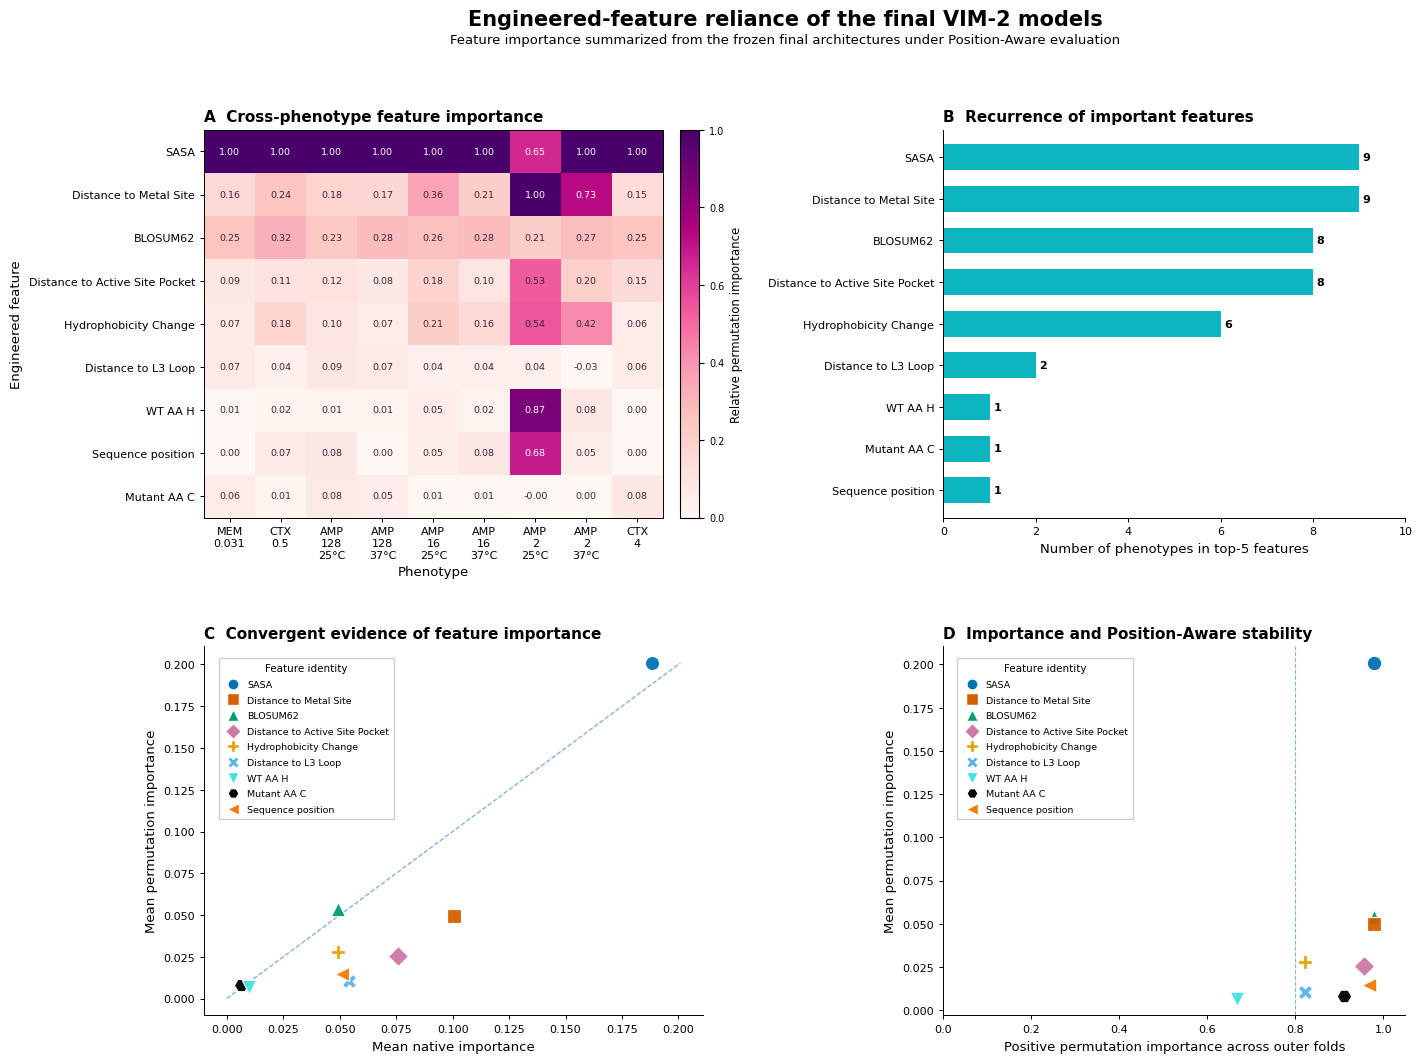

Figure 7 saved to /content/VIM2_Figure7_Feature_Importance_Q1


In [ ]:
# @title
# VIM-2 Figure 7 — Q1 Main-Text Feature Importance
# Uses frozen Step 6 architecture selection + Step 7 importance outputs only.
# No model fitting, HPO, new folds, or architecture re-selection.
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')

STEP7_DIR=Path('/content/VIM2_Step7_Model_Interpretation')
STEP6_DIR=Path('/content/VIM2_Step6_Statistical_Comparison')
SUMMARY_FILE=STEP7_DIR/'VIM2_Step7_Feature_Importance_Summary.csv'
TOP_FILE=STEP7_DIR/'VIM2_Step7_Top_Features_By_Target.csv'
FOLD_FILE=STEP7_DIR/'VIM2_Step7_Fold_Feature_Importance.csv'
SELECTION_FILE=STEP6_DIR/'VIM2_Step6_Final_Model_Selection.csv'
OUT=Path('/content/VIM2_Figure7_Feature_Importance_Q1')
OUT.mkdir(parents=True,exist_ok=True)

TARGETS=['0.031ug/mL_MEM_37C','0.5ug/mL_CTX_37C','128ug/mL_AMP_25C','128ug/mL_AMP_37C','16ug/mL_AMP_25C','16ug/mL_AMP_37C','2ug/mL_AMP_25C','2ug/mL_AMP_37C','4ug/mL_CTX_37C']
LABELS={'0.031ug/mL_MEM_37C':'MEM\n0.031','0.5ug/mL_CTX_37C':'CTX\n0.5','128ug/mL_AMP_25C':'AMP\n128\n25°C','128ug/mL_AMP_37C':'AMP\n128\n37°C','16ug/mL_AMP_25C':'AMP\n16\n25°C','16ug/mL_AMP_37C':'AMP\n16\n37°C','2ug/mL_AMP_25C':'AMP\n2\n25°C','2ug/mL_AMP_37C':'AMP\n2\n37°C','4ug/mL_CTX_37C':'CTX\n4'}

for p in [SUMMARY_FILE,TOP_FILE,FOLD_FILE,SELECTION_FILE]:
    if not p.exists(): raise FileNotFoundError(f'Missing required input: {p}')
summary=pd.read_csv(SUMMARY_FILE); top=pd.read_csv(TOP_FILE); fold=pd.read_csv(FOLD_FILE); sel=pd.read_csv(SELECTION_FILE)
req=['Target','Architecture','Feature','Native_Importance_Mean','Native_Importance_SD','Permutation_Importance_Mean','Permutation_Importance_SD','Permutation_Positive_Fraction_Mean','Permutation_Positive_Fold_Fraction','Permutation_Rank','Native_Rank']
missing=[c for c in req if c not in summary.columns]
if missing: raise ValueError(f'Missing Step 7 columns: {missing}')
if not {'Target','Selected_Architecture'}.issubset(sel.columns): raise ValueError('Step 6 selection needs Target and Selected_Architecture')
summary=summary[summary.Target.isin(TARGETS)].copy(); sel=sel[sel.Target.isin(TARGETS)].copy()
arch=dict(zip(sel.Target,sel.Selected_Architecture))
if set(TARGETS)-set(arch): raise ValueError(f'Missing Step 6 targets: {sorted(set(TARGETS)-set(arch))}')
summary['Selected_Architecture']=summary.Target.map(arch)
df=summary[summary.Architecture.eq(summary.Selected_Architecture)].copy()
if df.empty: raise ValueError('No Step 7 rows match frozen Step 6 architecture selection')
if any(df.Feature.astype(str).str.endswith('_SD')): raise ValueError('Target-associated *_SD predictors detected')
for c in ['Native_Importance_Mean','Native_Importance_SD','Permutation_Importance_Mean','Permutation_Importance_SD','Permutation_Positive_Fraction_Mean','Permutation_Positive_Fold_Fraction']:
    df[c]=pd.to_numeric(df[c],errors='coerce')
df=df.dropna(subset=['Native_Importance_Mean','Permutation_Importance_Mean']).copy()

def pretty(x):
    return {'Sequence_Position':'Sequence position','Secondary_Structure':'Secondary structure','Solvent_Accessibility':'Solvent accessibility','Hydrogen_Bond':'H-bond capacity','Hydrogen_Bonding':'H-bond capacity'}.get(x,str(x).replace('_',' '))

# A: top-5 per phenotype, normalized within phenotype
p5=df.sort_values(['Target','Permutation_Importance_Mean','Native_Importance_Mean'],ascending=[True,False,False]).groupby('Target',group_keys=False).head(5)
features=p5.Feature.value_counts().sort_values(ascending=False).index.tolist()[:15]
h=df[df.Feature.isin(features)].copy(); h['Relative']=h.groupby('Target').Permutation_Importance_Mean.transform(lambda x:x/x.max() if x.max()>0 else 0)
h=h.pivot_table(index='Feature',columns='Target',values='Relative',aggfunc='mean',fill_value=0).reindex(index=features,columns=TARGETS,fill_value=0); h.index=[pretty(x) for x in h.index]
# B: recurrence
r=(p5.groupby('Feature').agg(Phenotype_Count=('Target','nunique'),Mean_Permutation=('Permutation_Importance_Mean','mean'),Mean_Native=('Native_Importance_Mean','mean')).reset_index().sort_values(['Phenotype_Count','Mean_Permutation'],ascending=[False,False]).head(10)); r['Label']=r.Feature.map(pretty)
# C/D: global recurring features
fg=r.Feature.tolist(); s=df[df.Feature.isin(fg)].copy()
c=(s.groupby('Feature').agg(Native=('Native_Importance_Mean','mean'),Permutation=('Permutation_Importance_Mean','mean'),Permutation_SD=('Permutation_Importance_SD','mean')).reset_index()); c['Label']=c.Feature.map(pretty)
d=(s.groupby('Feature').agg(Mean_Permutation=('Permutation_Importance_Mean','mean'),Stability=('Permutation_Positive_Fold_Fraction','mean'),Phenotype_Count=('Target','nunique')).reset_index()); d['Label']=d.Feature.map(pretty)

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':9,'axes.titlesize':11,'axes.labelsize':9.5,'xtick.labelsize':8,'ytick.labelsize':8,'pdf.fonttype':42,'ps.fonttype':42})
fig=plt.figure(figsize=(15.5,11.5)); gs=fig.add_gridspec(2,2,height_ratios=[1.05,1],width_ratios=[1.08,1],hspace=.34,wspace=.50)
a,b,cc,e=[fig.add_subplot(gs[i,j]) for i,j in [(0,0),(0,1),(1,0),(1,1)]]
# A
# Standard RdPu sequential colormap; low values remain light and readable.
im=a.imshow(h.values,aspect='auto',interpolation='nearest',cmap='RdPu',vmin=0,vmax=1)
a.set_xticks(range(len(TARGETS))); a.set_xticklabels([LABELS[t] for t in TARGETS])
a.set_yticks(range(len(h.index))); a.set_yticklabels(h.index)
a.set_xlabel('Phenotype'); a.set_ylabel('Engineered feature')
a.set_title('A  Cross-phenotype feature importance',loc='left',fontweight='bold')
for i in range(h.shape[0]):
    for j in range(h.shape[1]):
        value=float(h.iloc[i,j])
        a.text(j,i,f'{value:.2f}',ha='center',va='center',fontsize=6.8,
               fontweight='medium',color='white' if value>=.55 else '#3B2435')
cb=fig.colorbar(im,ax=a,fraction=.046,pad=.035)
cb.set_label('Relative permutation importance',fontsize=8.5); cb.ax.tick_params(labelsize=7)

# B
rb=r.iloc[::-1]; yy=np.arange(len(rb))
bars=b.barh(yy,rb.Phenotype_Count,height=.62,color='#00B0BE',alpha=.95)
b.set_yticks(yy); b.set_yticklabels(rb.Label)
b.set_xlabel('Number of phenotypes in top-5 features')
b.set_xlim(0,max(5,int(rb.Phenotype_Count.max())+1)); b.margins(y=.04)
b.set_title('B  Recurrence of important features',loc='left',fontweight='bold')
for bar,v in zip(bars,rb.Phenotype_Count):
    b.text(bar.get_width()+.08,bar.get_y()+bar.get_height()/2,str(int(v)),
           va='center',fontsize=8,fontweight='bold')
b.spines['top'].set_visible(False); b.spines['right'].set_visible(False)

# Shared feature identity encoding for Panels C and D.
# Point labels are intentionally removed; identity is encoded by color + marker.
FEATURE_COLORS=['#0072B2','#D55E00','#009E73','#CC79A7','#E69F00',
                '#56B4E9','#40E4E0','#000000','#F47A00','#8C564B']
FEATURE_MARKERS=['o','s','^','D','P','X','v','H','<','*']
feature_style={feature:{'color':FEATURE_COLORS[i%len(FEATURE_COLORS)],
                        'marker':FEATURE_MARKERS[i%len(FEATURE_MARKERS)]}
               for i,feature in enumerate(r['Feature'])}

# C
for _,q in c.iterrows():
    st=feature_style[q['Feature']]
    cc.scatter(q.Native,q.Permutation,s=105,marker=st['marker'],
               color=st['color'],edgecolor='white',linewidth=.9,alpha=.95,zorder=3)
m=max(float(c.Native.max()),float(c.Permutation.max())) if len(c) else 0
if m>0: cc.plot([0,m],[0,m],linestyle='--',linewidth=.9,alpha=.6,zorder=1)
cc.set_xlabel('Mean native importance'); cc.set_ylabel('Mean permutation importance')
cc.set_title('C  Convergent evidence of feature importance',loc='left',fontweight='bold')
cc.spines['top'].set_visible(False); cc.spines['right'].set_visible(False)

# D
for _,q in d.iterrows():
    st=feature_style[q['Feature']]
    e.scatter(q.Stability,q.Mean_Permutation,s=110,marker=st['marker'],
              color=st['color'],edgecolor='white',linewidth=.9,alpha=.95,zorder=3)
e.axvline(.8,linestyle='--',linewidth=.8,alpha=.55,zorder=1)
e.set_xlim(0,1.05)
e.set_xlabel('Positive permutation importance across outer folds')
e.set_ylabel('Mean permutation importance')
e.set_title('D  Importance and Position-Aware stability',loc='left',fontweight='bold')
e.spines['top'].set_visible(False); e.spines['right'].set_visible(False)

# Compact professional feature-identity boxes at the upper-left of C and D.
legend_handles=[Line2D([0],[0],marker=feature_style[f]['marker'],linestyle='None',
                       markerfacecolor=feature_style[f]['color'],markeredgecolor='white',
                       markeredgewidth=1.0,markersize=8,label=pretty(f))
                 for f in r['Feature']]
for ax in [cc,e]:
    if legend_handles:
        ax.legend(handles=legend_handles,title='Feature identity',loc='upper left',
                  bbox_to_anchor=(.02,.98),fontsize=6.8,title_fontsize=7.5,
                  frameon=True,fancybox=False,framealpha=.96,borderpad=.55,
                  labelspacing=.7,handletextpad=.45,ncol=1)

fig.suptitle('Engineered-feature reliance of the final VIM-2 models',
             fontsize=15,fontweight='bold',y=.985)
fig.text(.5,.955,'Feature importance summarized from the frozen final architectures under Position-Aware evaluation',
         ha='center',fontsize=9.5)
for ax in [a,b,cc,e]:
    ax.tick_params(length=3,width=.7)
    for sp in ax.spines.values(): sp.set_linewidth(.7)

png=OUT/'Figure7_Final_Model_Feature_Importance.png'; pdf=OUT/'Figure7_Final_Model_Feature_Importance.pdf'; svg=OUT/'Figure7_Final_Model_Feature_Importance.svg'
fig.savefig(png,dpi=600,bbox_inches='tight',facecolor='white'); fig.savefig(pdf,bbox_inches='tight',facecolor='white'); fig.savefig(svg,bbox_inches='tight',facecolor='white')
h.to_csv(OUT/'Figure7A_Heatmap_Data.csv'); r.to_csv(OUT/'Figure7B_Global_Feature_Recurrence.csv',index=False); c.to_csv(OUT/'Figure7C_Native_vs_Permutation.csv',index=False); d.to_csv(OUT/'Figure7D_Importance_vs_Stability.csv',index=False)
with open(OUT/'Figure7_Reproducibility_Manifest.json','w',encoding='utf-8') as f: json.dump({'figure':'Figure 7','evaluation':'Position-Aware','model_fitting':False,'HPO':False,'new_folds':False,'architecture_source':str(SELECTION_FILE),'importance_source':str(SUMMARY_FILE)},f,indent=2)
plt.show(); print(f'Figure 7 saved to {OUT}')


In [ ]:
# @title
# ============================================================
# DOWNLOAD Figure7 OUTPUT DIRECTORY AS A ZIP ARCHIVE
# ============================================================

import os
import shutil
from google.colab import files

# Source directory
source_dir = "/content/VIM2_Figure7_Feature_Importance_Q1"

# Output ZIP archive
zip_base = "/content/VIM2_Figure7_Feature_Importance_Q1"
zip_file = f"{zip_base}.zip"

# Validate source directory
if not os.path.isdir(source_dir):
    raise FileNotFoundError(
        f"Source directory not found: {source_dir}"
    )

# Remove previous ZIP if it exists
if os.path.exists(zip_file):
    os.remove(zip_file)

# Create ZIP archive
shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir="/content",
    base_dir="VIM2_Figure7_Feature_Importance_Q1"
)

# Validate ZIP creation
if not os.path.isfile(zip_file):
    raise RuntimeError("ZIP archive was not created successfully.")

# Report archive size
size_mb = os.path.getsize(zip_file) / (1024 ** 2)

print("=" * 70)
print("Figure6 DOWNLOAD PACKAGE")
print("=" * 70)
print(f"Source directory : {source_dir}")
print(f"ZIP archive      : {zip_file}")
print(f"Archive size     : {size_mb:.2f} MB")
print("=" * 70)
print("ZIP archive created successfully.")
print("Starting download...")

# Download ZIP
files.download(zip_file)

Figure6 DOWNLOAD PACKAGE
Source directory : /content/VIM2_Figure7_Feature_Importance_Q1
ZIP archive      : /content/VIM2_Figure7_Feature_Importance_Q1.zip
Archive size     : 2.51 MB
ZIP archive created successfully.
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>